# IMC Prosperity 4: Complete Preparation Course

**A self-study notebook from zero Python knowledge to competition-ready trading bots.**

This notebook covers everything you need to compete in IMC Prosperity 4, the world's largest algorithmic trading competition. It is structured as a progressive course:

| Part | Topic | What You'll Learn |
|------|-------|-------------------|
| **1** | Python Engineering | Python basics, data structures, the IMC data model, backtesting |
| **2** | Math & Statistics | Descriptive stats, moving averages, regression, correlation, probability |
| **3** | Trading Strategies | Market making, trend following, pairs trading, options, counterparty ID |
| **4** | Manual Rounds | FX arbitrage, sealed-bid auctions, game theory, news sentiment |
| **5** | Integration | Multi-product routing, backtesting best practices, cross-year analysis |

### How to Use This Notebook

- **Run every cell in order.** Later cells depend on earlier ones.
- **Read the markdown carefully.** Every concept is explained before code appears.
- **Do the exercises.** They are marked with "EXERCISE" headers. Solutions follow immediately.
- **Look for callout boxes:**
  - **Common Mistake** — pitfalls that cost real teams real points
  - **From the Winners** — strategies and insights from top-placing teams
  - **Intuition Check** — quick questions to test your understanding

### Prerequisites

- A computer with Python 3.10+ and Jupyter installed
- Basic math (algebra, functions, graphs)
- No prior programming or trading experience required

### About IMC Prosperity

IMC Prosperity is a 15-day global algorithmic trading competition run by IMC Trading. Teams write Python bots that trade fictional products on a simulated exchange. Your bot receives market data each "tick" (100ms intervals) and must return trading orders. The goal: maximize profit in SeaShells (the in-game currency).

**Key constraints:**
- Your code runs on AWS Lambda (no internet access, no pip install)
- Only Python standard library is available in submissions
- Position limits enforced per product (exceed = orders rejected)
- `traderData` string (your only memory between ticks) limited to ~100KB
- Print output limited to ~3750 characters per tick

In [1]:
# [ANALYSIS ENVIRONMENT SETUP]
# These imports are for LOCAL analysis only.
# Your competition submission can ONLY use Python standard library.

import numpy as np                  # numerical computing (analysis only)
import pandas as pd                 # data manipulation (analysis only)
import matplotlib.pyplot as plt     # plotting (analysis only)
import matplotlib
import json                         # JSON serialization (available in competition)
import math                         # math functions (available in competition)
from collections import deque       # efficient queues (available in competition)
from typing import Dict, List, Any  # type hints (available in competition)

# Configure matplotlib for clean output
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.alpha'] = 0.3

# Confirm setup
print("Setup complete.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("Ready to begin!")

Setup complete.
NumPy version: 2.2.6
Pandas version: 2.3.2
Ready to begin!


## Part 1: Python Engineering

In this part you will learn:
1. **Python fundamentals** - variables, lists, dicts, functions
2. **Data structures & performance** - why `deque` beats `list` for rolling windows
3. **Object-oriented programming** - classes, the IMC `datamodel.py`
4. **JSON serialization** - persisting state with `traderData`
5. **Your first Trader bot** - skeleton code, backtester, visualization

By the end of Part 1, you will have a working trading bot and a backtester to test it.

### 1.1 Python Core Syntax

**Python** is a programming language designed for readability. IMC chose it for Prosperity because it is beginner-friendly yet powerful enough for real-time trading. Every line of Python reads almost like English, which makes it perfect for a competition where clarity matters more than raw speed.

In this section you will learn the building blocks: **variables**, **lists**, **dictionaries**, **control flow**, and **functions**. Every example uses trading concepts so you can see how these basics connect to the competition.

In [2]:
# ── Variables & Print ──────────────────────────────────────────
# A variable stores a value. Think of it as a labeled box.

stock_price = 10000          # price of RAINFOREST_RESIN in SeaShells
spread = 3                   # gap between best bid and best ask
position = 0                 # how many units we currently hold
position_limit = 50          # maximum units allowed by IMC rules

# f-strings let you embed variables directly in text
print(f"Current price: {stock_price}")
print(f"Spread: {spread}")
print(f"Position: {position} / {position_limit}")

# Arithmetic with variables
buy_price = stock_price - spread   # we want to buy below fair value
sell_price = stock_price + spread  # we want to sell above fair value
print(f"Buy at: {buy_price}, Sell at: {sell_price}")

Current price: 10000
Spread: 3
Position: 0 / 50
Buy at: 9997, Sell at: 10003


In [3]:
# ── Lists ──────────────────────────────────────────────────────
# A list is an ordered collection. Perfect for price history.

price_history = [9998, 9999, 10001, 10002, 10000, 9997, 10003]

# Indexing: first element is index 0
first_price = price_history[0]      # 9998
last_price = price_history[-1]      # 10003
print(f"First price: {first_price}")
print(f"Last price:  {last_price}")

# Slicing: get a sub-list
recent_prices = price_history[-3:]  # last 3 prices
print(f"Recent prices: {recent_prices}")

# Append: add a new price
price_history.append(10005)
print(f"After append: {price_history}")
print(f"Length: {len(price_history)}")

# List comprehension: transform every element
returns = [price_history[i] - price_history[i-1]
           for i in range(1, len(price_history))]
print(f"Price changes: {returns}")

First price: 9998
Last price:  10003
Recent prices: [10000, 9997, 10003]
After append: [9998, 9999, 10001, 10002, 10000, 9997, 10003, 10005]
Length: 8
Price changes: [1, 2, 1, -2, -3, 6, 2]


### Dictionaries: THE Most Important Data Structure

A **dictionary** maps keys to values, like a phone book maps names to numbers. In Prosperity, the **order book** is a dictionary: it maps **prices** to **volumes**.

```
buy_orders = {9998: 10, 9997: 25, 9995: 5}
```

This means: "10 units wanted at 9998, 25 units wanted at 9997, 5 units wanted at 9995." Dictionary lookup is **O(1)** - instant, regardless of size. This matters when your bot has only 100 milliseconds per tick.

In [4]:
# ── Dictionaries ───────────────────────────────────────────────
# Order book representation: {price: volume}

buy_orders = {9998: 10, 9997: 25, 9995: 5}    # bids (positive = wants to buy)
sell_orders = {10002: -8, 10003: -15, 10005: -20}  # asks (negative = wants to sell)

# Access a specific price level
volume_at_9998 = buy_orders[9998]
print(f"Volume at 9998: {volume_at_9998}")

# Find best bid (highest buy price) and best ask (lowest sell price)
best_bid_price = max(buy_orders.keys())
best_ask_price = min(sell_orders.keys())
mid_price = (best_bid_price + best_ask_price) / 2
spread = best_ask_price - best_bid_price

print(f"Best bid: {best_bid_price}")
print(f"Best ask: {best_ask_price}")
print(f"Mid price: {mid_price}")
print(f"Spread: {spread}")

# Iterate over all price levels
print("\\nBuy orders (bids):")
for price, volume in sorted(buy_orders.items(), reverse=True):
    print(f"  {volume:>4} units @ {price}")

print("\\nSell orders (asks):")
for price, volume in sorted(sell_orders.items()):
    print(f"  {volume:>4} units @ {price}")

Volume at 9998: 10
Best bid: 9998
Best ask: 10002
Mid price: 10000.0
Spread: 4
\nBuy orders (bids):
    10 units @ 9998
    25 units @ 9997
     5 units @ 9995
\nSell orders (asks):
    -8 units @ 10002
   -15 units @ 10003
   -20 units @ 10005


In [5]:
# ── Control Flow ───────────────────────────────────────────────
# if/elif/else for decision making

fair_value = 10000
current_position = 20
position_limit = 50

# Decide whether to buy based on price and position
best_ask_price = 9998
ask_volume = 8

if best_ask_price < fair_value:
    # Price is below fair value - good to buy
    max_can_buy = position_limit - current_position
    actual_buy = min(ask_volume, max_can_buy)
    print(f"BUY {actual_buy} units @ {best_ask_price}")
    print(f"  Reason: price {best_ask_price} < fair value {fair_value}")
elif best_ask_price == fair_value:
    print("Price equals fair value - no edge, skip")
else:
    print("Price above fair value - do not buy")

# for loop: process all sell orders
print("\\nProcessing all sell orders:")
sell_orders = {9998: -8, 9999: -5, 10001: -12}
for price in sorted(sell_orders.keys()):
    volume = abs(sell_orders[price])
    if price < fair_value:
        print(f"  BUY {volume} @ {price} (below fair value)")
    else:
        print(f"  SKIP @ {price} (at or above fair value)")

BUY 8 units @ 9998
  Reason: price 9998 < fair value 10000
\nProcessing all sell orders:
  BUY 8 @ 9998 (below fair value)
  BUY 5 @ 9999 (below fair value)
  SKIP @ 10001 (at or above fair value)


In [6]:
# ── Functions ──────────────────────────────────────────────────
# Functions package reusable logic with a name.

def compute_mid_price(buy_orders: dict, sell_orders: dict) -> float:
    # Compute the midpoint between best bid and best ask.
    # Args: buy_orders - dict of {price: volume} for bids
    #       sell_orders - dict of {price: volume} for asks
    # Returns: midpoint price as a float

    if not buy_orders or not sell_orders:
        return 0.0  # no market, return zero

    best_bid = max(buy_orders.keys())   # highest bid
    best_ask = min(sell_orders.keys())  # lowest ask
    midpoint = (best_bid + best_ask) / 2.0
    return midpoint

# Test the function
test_bids = {9998: 10, 9997: 25}
test_asks = {10002: -8, 10003: -15}
result = compute_mid_price(test_bids, test_asks)
print(f"Mid price: {result}")

# Empty book edge case
empty_result = compute_mid_price({}, {10002: -8})
print(f"Empty bids -> mid: {empty_result}")

Mid price: 10000.0
Empty bids -> mid: 0.0


In [7]:
# ── EXERCISE: Analyze an Order Book ────────────────────────────
# Write a function that takes buy_orders and sell_orders dicts
# and returns a dictionary with:
#   "best_bid", "best_ask", "mid_price", "spread",
#   "total_bid_volume", "total_ask_volume"

# YOUR CODE HERE:
# def analyze_order_book(buy_orders: dict, sell_orders: dict) -> dict:
#     ...

# Test with:
# test_bids = {9998: 10, 9997: 25, 9995: 5}
# test_asks = {10002: -8, 10003: -15, 10005: -20}
# print(analyze_order_book(test_bids, test_asks))
print("Complete the exercise above, then check the solution below.")

Complete the exercise above, then check the solution below.


In [8]:
# ── SOLUTION ───────────────────────────────────────────────────
def analyze_order_book(buy_orders: dict, sell_orders: dict) -> dict:
    # Analyze an order book and return key metrics.
    # Args: buy_orders - {price: +volume}, sell_orders - {price: -volume}
    # Returns: dict with best_bid, best_ask, mid_price, spread, volumes

    best_bid = max(buy_orders.keys()) if buy_orders else 0
    best_ask = min(sell_orders.keys()) if sell_orders else 0
    mid_price = (best_bid + best_ask) / 2.0 if (best_bid and best_ask) else 0.0
    spread = best_ask - best_bid if (best_bid and best_ask) else 0

    # Sum volumes (asks are negative, take abs)
    total_bid_volume = sum(buy_orders.values())
    total_ask_volume = sum(abs(v) for v in sell_orders.values())

    return {
        "best_bid": best_bid,
        "best_ask": best_ask,
        "mid_price": mid_price,
        "spread": spread,
        "total_bid_volume": total_bid_volume,
        "total_ask_volume": total_ask_volume,
    }

# Test
test_bids = {9998: 10, 9997: 25, 9995: 5}
test_asks = {10002: -8, 10003: -15, 10005: -20}
info = analyze_order_book(test_bids, test_asks)
for key, value in info.items():
    print(f"  {key}: {value}")

  best_bid: 9998
  best_ask: 10002
  mid_price: 10000.0
  spread: 4
  total_bid_volume: 40
  total_ask_volume: 43


> **Intuition Check:** Why is dictionary lookup O(1) (constant time) while searching a list is O(n) (linear time)? Because dictionaries use **hash tables** - they compute a hash of the key and jump directly to the right slot. Lists must scan element by element. When your bot has 100ms per tick, this difference matters: looking up 50 prices in a dict takes the same time as looking up 1.

### 1.2 Data Structures & Performance

Your trading bot runs on AWS Lambda and gets **100 milliseconds per tick** to read market data, compute a strategy, and return orders. That is 0.1 seconds. Choosing the right data structure can mean the difference between a bot that responds in 5ms and one that times out.

The most important optimization: use `collections.deque` instead of `list` for **rolling windows** (the last N prices). A deque with `maxlen` automatically drops old values and runs in O(1) per operation.

In [9]:
# ── Timing: List vs Set Lookup ─────────────────────────────────
import time

# Create a large collection
big_list = list(range(100000))
big_set = set(range(100000))

# Time list lookup (O(n) - must scan elements)
start_time = time.time()
for target in range(0, 100000, 1000):
    _ = target in big_list
list_time = time.time() - start_time

# Time set lookup (O(1) - hash-based)
start_time = time.time()
for target in range(0, 100000, 1000):
    _ = target in big_set
set_time = time.time() - start_time

print(f"List lookup (100 searches): {list_time*1000:.2f} ms")
print(f"Set lookup  (100 searches): {set_time*1000:.2f} ms")
print(f"Set is {list_time/max(set_time, 1e-9):.0f}x faster")

List lookup (100 searches): 61.35 ms
Set lookup  (100 searches): 0.00 ms
Set is 61348677x faster


> **Common Mistake:** Using `list.pop(0)` for rolling windows is **O(n)** because every remaining element must shift left. Use `collections.deque` with `maxlen` for **O(1)** pops from both ends. This matters when processing thousands of price updates per round.

In [10]:
# ── collections.deque: The Right Tool for Rolling Windows ──────
from collections import deque

# Create a deque that holds at most 5 elements
price_window = deque(maxlen=5)

# Add prices one by one - oldest auto-dropped when full
prices_arriving = [9998, 9999, 10001, 10002, 10000, 9997, 10003, 10005]
for price in prices_arriving:
    price_window.append(price)
    # Show current window state
    window_list = list(price_window)
    window_mean = sum(window_list) / len(window_list)
    print(f"Added {price:>5} -> window: {window_list}  mean: {window_mean:.1f}")

print(f"\\nFinal window: {list(price_window)}")
print(f"Window is always <= {price_window.maxlen} elements")

Added  9998 -> window: [9998]  mean: 9998.0
Added  9999 -> window: [9998, 9999]  mean: 9998.5
Added 10001 -> window: [9998, 9999, 10001]  mean: 9999.3
Added 10002 -> window: [9998, 9999, 10001, 10002]  mean: 10000.0
Added 10000 -> window: [9998, 9999, 10001, 10002, 10000]  mean: 10000.0
Added  9997 -> window: [9999, 10001, 10002, 10000, 9997]  mean: 9999.8
Added 10003 -> window: [10001, 10002, 10000, 9997, 10003]  mean: 10000.6
Added 10005 -> window: [10002, 10000, 9997, 10003, 10005]  mean: 10001.4
\nFinal window: [10002, 10000, 9997, 10003, 10005]
Window is always <= 5 elements


In [11]:
# ── EXERCISE: RollingWindow Class ──────────────────────────────
# Build a class that uses deque to track the last N prices.
# Methods: add(price), mean(), is_full()

# YOUR CODE HERE:
# class RollingWindow:
#     def __init__(self, window_size: int):
#         ...

print("Complete the exercise above, then check the solution below.")

Complete the exercise above, then check the solution below.


In [12]:
# ── SOLUTION ───────────────────────────────────────────────────
class RollingWindow:
    # Tracks the last N values using a deque for O(1) operations.

    def __init__(self, window_size: int):
        self.values = deque(maxlen=window_size)

    def add(self, value: float) -> None:
        # Add a new value (oldest auto-dropped if full)
        self.values.append(value)

    def mean(self) -> float:
        # Compute the mean of values in the window
        if len(self.values) == 0:
            return 0.0
        return sum(self.values) / len(self.values)

    def is_full(self) -> bool:
        # Check if the window has reached capacity
        return len(self.values) == self.values.maxlen

# Demo
window = RollingWindow(window_size=5)
for price in [100, 102, 101, 103, 105, 104, 106]:
    window.add(price)
    status = "FULL" if window.is_full() else "filling"
    print(f"Added {price} -> mean={window.mean():.1f} ({status})")

Added 100 -> mean=100.0 (filling)
Added 102 -> mean=101.0 (filling)
Added 101 -> mean=101.0 (filling)
Added 103 -> mean=101.5 (filling)
Added 105 -> mean=102.2 (FULL)
Added 104 -> mean=103.0 (FULL)
Added 106 -> mean=103.8 (FULL)


> **From the Winners:** Frankfurt Hedgehogs (Prosperity 3, 2nd place) processed order books using dictionaries for O(1) price lookups. They also used deques for rolling price windows. Every microsecond counts when your bot must respond within 100ms.

### 1.3 Object-Oriented Programming & The IMC Data Model

A **class** is a blueprint for creating objects. Think of a class as a cookie cutter and objects as the cookies. In IMC Prosperity, your bot is a class called `Trader` with a method called `run()`. The exchange calls `run()` every tick and passes a `TradingState` object containing all market data.

Below is the **real data model** that IMC provides. These classes define the structure of every piece of data your bot receives: orders, trades, positions, and observations.

In [13]:
# ── Simple Class Example ───────────────────────────────────────
# Before diving into the IMC data model, let us build a simple class.

class PriceTracker:
    # Tracks price statistics for one product.

    def __init__(self, product_name: str):
        # Initialize with product name and empty history
        self.product_name = product_name
        self.prices = []
        self.trade_count = 0

    def add_price(self, price: float) -> None:
        # Record a new price observation
        self.prices.append(price)
        self.trade_count += 1

    def average_price(self) -> float:
        # Compute mean of all observed prices
        if len(self.prices) == 0:
            return 0.0
        return sum(self.prices) / len(self.prices)

    def price_range(self) -> float:
        # Compute the range (max - min) of observed prices
        if len(self.prices) == 0:
            return 0.0
        return max(self.prices) - min(self.prices)

# Create an instance and use it
tracker = PriceTracker("KELP")
for price in [4985, 5010, 4995, 5005, 5000]:
    tracker.add_price(price)

print(f"Product: {tracker.product_name}")
print(f"Trades: {tracker.trade_count}")
print(f"Average: {tracker.average_price():.1f}")
print(f"Range: {tracker.price_range()}")

Product: KELP
Trades: 5
Average: 4999.0
Range: 25


### The REAL `datamodel.py`

Below are the exact classes that IMC provides for competition. **You do not submit this file** - it is pre-loaded on the server. Your `Trader` class receives `TradingState` objects built from these classes. Study every field carefully.

In [14]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] IMC Prosperity Data Model
# These classes mirror the official IMC datamodel.py.
# Your Trader class receives TradingState objects with these types.
# ══════════════════════════════════════════════════════════════

# ── Type Aliases ───────────────────────────────────────────────
Time = int              # timestamp in milliseconds
Symbol = str            # product symbol, e.g. "RAINFOREST_RESIN"
Product = str           # same as Symbol in practice
Position = int          # units held: +long, -short
UserId = str            # trader identifier, e.g. "Olivia"
ObservationValue = int  # external data values


class Listing:
    # Defines a tradable product on the exchange.
    def __init__(self, symbol: Symbol, product: Product, denomination: Product):
        self.symbol = symbol              # e.g. "RAINFOREST_RESIN"
        self.product = product            # the underlying product
        self.denomination = denomination  # always "SEASHELLS"


class ConversionObservation:
    # External market data for cross-exchange products (e.g. MACARONS).
    def __init__(self, bidPrice: float, askPrice: float,
                 transportFees: float, exportTariff: float,
                 importTariff: float, sugarPrice: float = 0.0,
                 sunlightIndex: float = 0.0):
        self.bidPrice = bidPrice
        self.askPrice = askPrice
        self.transportFees = transportFees
        self.exportTariff = exportTariff
        self.importTariff = importTariff
        self.sugarPrice = sugarPrice
        self.sunlightIndex = sunlightIndex


class Observation:
    # Container for external observations each tick.
    def __init__(self, plainValueObservations: dict = None,
                 conversionObservations: dict = None):
        self.plainValueObservations = plainValueObservations or {}
        self.conversionObservations = conversionObservations or {}


class Order:
    # A single buy or sell order. Positive quantity = buy, negative = sell.
    def __init__(self, symbol: Symbol, price: int, quantity: int) -> None:
        self.symbol = symbol      # which product to trade
        self.price = price        # at what price
        self.quantity = quantity   # how many (+buy, -sell)

    def __str__(self) -> str:
        return f"({self.symbol}, {self.price}, {self.quantity})"

    def __repr__(self) -> str:
        return self.__str__()


class OrderDepth:
    # The order book for one product: all resting buy and sell orders.
    def __init__(self, buy_orders: dict = None, sell_orders: dict = None):
        self.buy_orders = buy_orders if buy_orders is not None else {}
        self.sell_orders = sell_orders if sell_orders is not None else {}


class Trade:
    # A completed trade between two participants.
    def __init__(self, symbol: Symbol, price: int, quantity: int,
                 buyer: UserId = None, seller: UserId = None,
                 timestamp: int = 0) -> None:
        self.symbol = symbol
        self.price = price
        self.quantity = quantity
        self.buyer = buyer
        self.seller = seller
        self.timestamp = timestamp

    def __str__(self) -> str:
        return f"({self.symbol}, {self.price}, {self.quantity}, t={self.timestamp})"

    def __repr__(self) -> str:
        return self.__str__()


class TradingState:
    # Everything your bot receives each tick.
    def __init__(self, traderData: str, timestamp: Time,
                 listings: dict, order_depths: dict,
                 own_trades: dict, market_trades: dict,
                 position: dict, observations: Observation):
        self.traderData = traderData           # your persisted state (JSON string)
        self.timestamp = timestamp             # current time in ms
        self.listings = listings               # {symbol: Listing}
        self.order_depths = order_depths       # {symbol: OrderDepth}
        self.own_trades = own_trades           # {symbol: [Trade]} your fills
        self.market_trades = market_trades     # {symbol: [Trade]} all trades
        self.position = position               # {symbol: int} current holdings
        self.observations = observations       # Observation object

print("Data model classes defined successfully.")
print("Classes: Listing, ConversionObservation, Observation,")
print("         Order, OrderDepth, Trade, TradingState")

Data model classes defined successfully.


Classes: Listing, ConversionObservation, Observation,
         Order, OrderDepth, Trade, TradingState


In [15]:
# ── Build a Mock TradingState ──────────────────────────────────
# Let us construct a TradingState by hand to understand every field.

# Step 1: Create an order book for RAINFOREST_RESIN
resin_order_depth = OrderDepth(
    buy_orders={9998: 10, 9997: 25, 9995: 5},    # bids
    sell_orders={10002: -8, 10003: -15, 10005: -20}  # asks
)

# Step 2: Create a listing
resin_listing = Listing(
    symbol="RAINFOREST_RESIN",
    product="RAINFOREST_RESIN",
    denomination="SEASHELLS"
)

# Step 3: Create some recent trades
recent_trades = [
    Trade("RAINFOREST_RESIN", 10001, 5, buyer="Alice", seller="Bob", timestamp=900),
    Trade("RAINFOREST_RESIN", 9999, 3, buyer="Charlie", seller="Olivia", timestamp=800),
]

# Step 4: Assemble the full TradingState
mock_state = TradingState(
    traderData="",                                        # no saved state yet
    timestamp=1000,                                       # current tick
    listings={"RAINFOREST_RESIN": resin_listing},         # available products
    order_depths={"RAINFOREST_RESIN": resin_order_depth}, # order books
    own_trades={"RAINFOREST_RESIN": []},                  # our fills (none yet)
    market_trades={"RAINFOREST_RESIN": recent_trades},    # all recent trades
    position={"RAINFOREST_RESIN": 15},                    # we hold 15 units
    observations=Observation(),                            # no external data
)

# Step 5: Inspect every field
print(f"Timestamp: {mock_state.timestamp}")
print(f"Position in RESIN: {mock_state.position['RAINFOREST_RESIN']}")
print(f"Best bid: {max(resin_order_depth.buy_orders.keys())}")
print(f"Best ask: {min(resin_order_depth.sell_orders.keys())}")
print(f"Recent trades: {len(mock_state.market_trades['RAINFOREST_RESIN'])}")
print(f"traderData: '{mock_state.traderData}' (empty = first tick)")

Timestamp: 1000
Position in RESIN: 15
Best bid: 9998
Best ask: 10002
Recent trades: 2
traderData: '' (empty = first tick)


### A Day in the Life of One Timestamp

Every 100ms, the exchange calls your `Trader.run(state)` method. Here is what happens:

1. **Exchange builds `TradingState`** with current order books, your position, recent trades
2. **Your bot receives `state`** and inspects `state.order_depths`, `state.position`, etc.
3. **Your bot computes orders** based on its strategy
4. **Your bot returns orders** as `{symbol: [Order, Order, ...]}`
5. **Exchange matches orders** against the book, updates positions
6. **Next tick** - repeat from step 1

Your bot has NO memory between ticks except `traderData` (a string you can set).

In [16]:
# ── Walking Through One Tick ───────────────────────────────────
# Simulate what happens inside a single call to Trader.run()

# The state we built above represents one tick
state = mock_state

# Step 1: Read the order book
order_depth = state.order_depths["RAINFOREST_RESIN"]
best_bid = max(order_depth.buy_orders.keys())
best_ask = min(order_depth.sell_orders.keys())
mid_price = (best_bid + best_ask) / 2

print(f"Best bid: {best_bid}  Best ask: {best_ask}  Mid: {mid_price}")

# Step 2: Check our position
current_position = state.position.get("RAINFOREST_RESIN", 0)
position_limit = 50
print(f"Current position: {current_position} / {position_limit}")

# Step 3: Decide on orders
fair_value = 10000  # RAINFOREST_RESIN has known fair value
orders = []

# If best ask is below fair value, buy
if best_ask < fair_value:
    can_buy = position_limit - current_position
    ask_volume = abs(order_depth.sell_orders[best_ask])
    buy_quantity = min(ask_volume, can_buy)
    if buy_quantity > 0:
        orders.append(Order("RAINFOREST_RESIN", best_ask, buy_quantity))
        print(f"=> BUY {buy_quantity} @ {best_ask}")

# If best bid is above fair value, sell
if best_bid > fair_value:
    can_sell = position_limit + current_position
    bid_volume = order_depth.buy_orders[best_bid]
    sell_quantity = min(bid_volume, can_sell)
    if sell_quantity > 0:
        orders.append(Order("RAINFOREST_RESIN", best_bid, -sell_quantity))
        print(f"=> SELL {sell_quantity} @ {best_bid}")

# Always place passive quotes to earn spread
remaining_buy = position_limit - current_position
remaining_sell = position_limit + current_position
orders.append(Order("RAINFOREST_RESIN", int(fair_value) - 1, remaining_buy))
orders.append(Order("RAINFOREST_RESIN", int(fair_value) + 1, -remaining_sell))

print(f"\\nTotal orders: {len(orders)}")
for order in orders:
    side = "BUY" if order.quantity > 0 else "SELL"
    print(f"  {side} {abs(order.quantity)} @ {order.price}")

Best bid: 9998  Best ask: 10002  Mid: 10000.0
Current position: 15 / 50
\nTotal orders: 2
  BUY 35 @ 9999
  SELL 65 @ 10001


> **Intuition Check:** What happens if your `run()` method returns an empty dictionary `{}`? Answer: **nothing trades**. Your bot sits idle for that tick. No orders placed, no position changes. This is actually a valid strategy for ticks where you see no edge!

In [17]:
# ── EXERCISE: Extract Order Book Information ───────────────────
# Write extract_book_info(order_depth) that returns a dict with:
# best_bid, best_ask, mid_price, spread,
# total_bid_volume, total_ask_volume, bid_ask_imbalance

# bid_ask_imbalance = total_bid_vol / (total_bid_vol + total_ask_vol)
# Values > 0.5 mean more buying pressure

# YOUR CODE HERE
print("Complete the exercise, then check solution below.")

Complete the exercise, then check solution below.


In [18]:
# ── SOLUTION ───────────────────────────────────────────────────
def extract_book_info(order_depth: OrderDepth) -> dict:
    # Extract key metrics from an OrderDepth object.
    best_bid = max(order_depth.buy_orders.keys()) if order_depth.buy_orders else 0
    best_ask = min(order_depth.sell_orders.keys()) if order_depth.sell_orders else 0

    mid_price = (best_bid + best_ask) / 2.0 if (best_bid and best_ask) else 0.0
    spread = (best_ask - best_bid) if (best_bid and best_ask) else 0

    total_bid_volume = sum(order_depth.buy_orders.values())
    total_ask_volume = sum(abs(v) for v in order_depth.sell_orders.values())

    total_volume = total_bid_volume + total_ask_volume
    imbalance = total_bid_volume / total_volume if total_volume > 0 else 0.5

    return {
        "best_bid": best_bid,
        "best_ask": best_ask,
        "mid_price": mid_price,
        "spread": spread,
        "total_bid_volume": total_bid_volume,
        "total_ask_volume": total_ask_volume,
        "bid_ask_imbalance": round(imbalance, 3),
    }

# Test with our mock order book
info = extract_book_info(resin_order_depth)
for key, value in info.items():
    print(f"  {key}: {value}")

  best_bid: 9998
  best_ask: 10002
  mid_price: 10000.0
  spread: 4
  total_bid_volume: 40
  total_ask_volume: 43
  bid_ask_imbalance: 0.482


> **From the Winners:** Stanford Cardinal (Prosperity 1, 2nd place) used the simplest possible Trader structure: read state, compute fair value, place orders. No complex inheritance, no design patterns. Simple code that works beats complex code that might have bugs.

### 1.4 JSON State Serialization

Your bot has **amnesia**. Every tick, it wakes up with no memory of previous ticks. The ONLY way to remember anything is the `traderData` string - a field you return from `run()` that gets passed back to you on the next tick.

Think of it like writing yourself a note before going to sleep. Tomorrow, you will read that note and continue where you left off. The note must be a JSON string and cannot exceed ~100KB.

In [19]:
# ── JSON Basics ────────────────────────────────────────────────
import json

# Convert a Python dict to a JSON string
state_to_save = {
    "ema_price": 10003.5,
    "price_history": [9998, 9999, 10001, 10002, 10000],
    "trade_count": 42,
}

# Serialize to string (this goes into traderData)
json_string = json.dumps(state_to_save)
print(f"JSON string: {json_string}")
print(f"Length: {len(json_string)} characters")

# Deserialize back to Python dict
restored_state = json.loads(json_string)
print(f"\\nRestored EMA: {restored_state['ema_price']}")
print(f"Restored history: {restored_state['price_history']}")
print(f"Restored trades: {restored_state['trade_count']}")

JSON string: {"ema_price": 10003.5, "price_history": [9998, 9999, 10001, 10002, 10000], "trade_count": 42}
Length: 93 characters
\nRestored EMA: 10003.5
Restored history: [9998, 9999, 10001, 10002, 10000]
Restored trades: 42


> **Common Mistake:** `traderData` is limited to approximately **100KB**. If you store too much history, your bot crashes. Also, `collections.deque` is **NOT** JSON-serializable - you must convert it to a list first: `json.dumps({"prices": list(my_deque)})`.

In [20]:
# ── Full traderData Pattern ────────────────────────────────────
# A production-ready pattern for saving and restoring state.

def save_trader_data(ema_prices: dict, price_histories: dict,
                     max_history: int = 50) -> str:
    # Save state to JSON string with size checking.
    # Trim histories to max_history to stay under 100KB limit.

    # Trim histories to prevent unlimited growth
    trimmed_histories = {}
    for symbol, prices in price_histories.items():
        trimmed_histories[symbol] = list(prices)[-max_history:]

    state = {
        "ema": ema_prices,
        "hist": trimmed_histories,
    }

    json_string = json.dumps(state)

    # Check size (100KB = 102400 bytes)
    size_bytes = len(json_string.encode("utf-8"))
    if size_bytes > 90000:  # warn at 90KB
        print(f"WARNING: traderData is {size_bytes} bytes (limit ~100KB)")

    return json_string


def load_trader_data(trader_data: str) -> tuple:
    # Restore state from traderData string.
    # Returns (ema_dict, histories_dict)

    if not trader_data or trader_data == "":
        return {}, {}

    try:
        state = json.loads(trader_data)
        return state.get("ema", {}), state.get("hist", {})
    except json.JSONDecodeError:
        return {}, {}


# Demo: save and restore
ema_prices = {"KELP": 5002.3, "SQUID_INK": 3100.5}
histories = {"KELP": [5000, 5001, 5003, 5002], "SQUID_INK": [3100, 3101, 3099]}

saved = save_trader_data(ema_prices, histories)
print(f"Saved ({len(saved)} chars): {saved[:80]}...")

restored_ema, restored_hist = load_trader_data(saved)
print(f"Restored EMA: {restored_ema}")
print(f"Restored history lengths: { {k: len(v) for k, v in restored_hist.items()} }")

Saved (123 chars): {"ema": {"KELP": 5002.3, "SQUID_INK": 3100.5}, "hist": {"KELP": [5000, 5001, 500...
Restored EMA: {'KELP': 5002.3, 'SQUID_INK': 3100.5}
Restored history lengths: {'KELP': 4, 'SQUID_INK': 3}


In [21]:
# ── EXERCISE + SOLUTION: StateManager Class ────────────────────

class StateManager:
    # Manages serialization/deserialization of trader state.
    # Handles size limits and provides a clean interface.

    def __init__(self, max_size_bytes: int = 90000):
        self.max_size_bytes = max_size_bytes
        self.data = {}

    def set(self, key: str, value) -> None:
        # Store a value (must be JSON-serializable)
        self.data[key] = value

    def get(self, key: str, default=None):
        # Retrieve a value
        return self.data.get(key, default)

    def save(self) -> str:
        # Serialize to JSON string with size check
        result = json.dumps(self.data)
        size = len(result.encode("utf-8"))
        if size > self.max_size_bytes:
            print(f"WARNING: state too large ({size} bytes)")
        return result

    def load(self, trader_data: str) -> None:
        # Restore state from JSON string
        if trader_data and trader_data != "":
            try:
                self.data = json.loads(trader_data)
            except json.JSONDecodeError:
                self.data = {}

# Demo
manager = StateManager()
manager.set("ema_kelp", 5002.3)
manager.set("tick_count", 42)

saved_string = manager.save()
print(f"Saved: {saved_string}")

# Simulate next tick: create new manager and load
next_tick_manager = StateManager()
next_tick_manager.load(saved_string)
print(f"Restored ema_kelp: {next_tick_manager.get('ema_kelp')}")
print(f"Restored tick_count: {next_tick_manager.get('tick_count')}")

Saved: {"ema_kelp": 5002.3, "tick_count": 42}
Restored ema_kelp: 5002.3
Restored tick_count: 42


### 1.5 Your First Trader & the Backtester

Your competition submission is a **single Python file** containing a class called `Trader` with a method called `run()`. The exchange calls `run(state)` every tick and expects you to return a tuple of `(orders_dict, conversions, traderData)`.

We will build the Trader in stages: first a skeleton that does nothing, then one that reads the order book, then one that actually trades.

In [22]:
# ── The Simplest Possible Trader ───────────────────────────────

class DoNothingTrader:
    # A Trader that does absolutely nothing. Returns empty orders.
    # This is valid! It just means you do not trade.

    def run(self, state: TradingState) -> tuple:
        # Return empty orders, no conversions, no state
        orders = {}           # no orders for any product
        conversions = 0       # no cross-exchange conversions
        trader_data = ""      # nothing to remember

        return orders, conversions, trader_data


# Quick test
trader = DoNothingTrader()
result = trader.run(mock_state)
print(f"Orders: {result[0]}")
print(f"Conversions: {result[1]}")
print(f"TraderData: '{result[2]}'")
print("This trader does nothing - but it compiles and runs!")

Orders: {}
Conversions: 0
TraderData: ''
This trader does nothing - but it compiles and runs!


In [23]:
# ── Add Feature: Read Best Bid/Ask ─────────────────────────────

class PeekingTrader:
    # Reads the order book and prints information, but does not trade.

    def run(self, state: TradingState) -> tuple:
        orders = {}

        for symbol, order_depth in state.order_depths.items():
            # Extract best bid and ask
            if order_depth.buy_orders and order_depth.sell_orders:
                best_bid = max(order_depth.buy_orders.keys())
                best_ask = min(order_depth.sell_orders.keys())
                position = state.position.get(symbol, 0)
                print(f"[{symbol}] bid={best_bid} ask={best_ask} pos={position}")

        return orders, 0, ""


# Test
trader = PeekingTrader()
trader.run(mock_state)

[RAINFOREST_RESIN] bid=9998 ask=10002 pos=15

({}, 0, '')

In [24]:
# ── Add Feature: Place Orders Based on Fair Value ──────────────

class SimpleFairValueTrader:
    # Buys below fair value, sells above fair value.
    # Uses the three-phase pattern: TAKE, CLEAR, MAKE.

    def __init__(self, symbol: str = "RAINFOREST_RESIN",
                 fair_price: float = 10000.0,
                 position_limit: int = 50):
        self.symbol = symbol
        self.fair_price = fair_price
        self.position_limit = position_limit

    def run(self, state: TradingState) -> tuple:
        orders = []
        order_depth = state.order_depths.get(self.symbol, OrderDepth())
        current_position = state.position.get(self.symbol, 0)

        # Phase 1: TAKE - buy any asks below fair value
        for ask_price in sorted(order_depth.sell_orders.keys()):
            if ask_price < self.fair_price:
                ask_volume = abs(order_depth.sell_orders[ask_price])
                can_buy = self.position_limit - current_position
                buy_qty = min(ask_volume, can_buy)
                if buy_qty > 0:
                    orders.append(Order(self.symbol, ask_price, buy_qty))
                    current_position += buy_qty

        # Phase 1b: TAKE - sell any bids above fair value
        for bid_price in sorted(order_depth.buy_orders.keys(), reverse=True):
            if bid_price > self.fair_price:
                bid_volume = order_depth.buy_orders[bid_price]
                can_sell = self.position_limit + current_position
                sell_qty = min(bid_volume, can_sell)
                if sell_qty > 0:
                    orders.append(Order(self.symbol, bid_price, -sell_qty))
                    current_position -= sell_qty

        # Phase 3: MAKE - place passive quotes
        remaining_buy = self.position_limit - current_position
        remaining_sell = self.position_limit + current_position
        if remaining_buy > 0:
            orders.append(Order(self.symbol, int(self.fair_price) - 1, remaining_buy))
        if remaining_sell > 0:
            orders.append(Order(self.symbol, int(self.fair_price) + 1, -remaining_sell))

        result = {self.symbol: orders}
        return result, 0, ""


# Test
trader = SimpleFairValueTrader()
result, _, _ = trader.run(mock_state)
print(f"Orders for {trader.symbol}:")
for order in result[trader.symbol]:
    side = "BUY" if order.quantity > 0 else "SELL"
    print(f"  {side} {abs(order.quantity)} @ {order.price}")

Orders for RAINFOREST_RESIN:
  BUY 35 @ 9999
  SELL 65 @ 10001


### Testing Locally: The Backtester

The competition only shows you results **once per round** (every 2-3 days). To iterate quickly, you need a **local backtester** that simulates the exchange. Below are three essential tools:

1. `generate_synthetic_states()` - creates fake but realistic market data
2. `backtest_trader()` - runs your Trader through the synthetic data
3. `plot_backtest_results()` - visualizes PnL, position, and trade history

In [25]:
# ══════════════════════════════════════════════════════════════
# [ANALYSIS VERSION] Synthetic Data Generator
# Creates realistic TradingState objects for backtesting.
# ══════════════════════════════════════════════════════════════
import random

def generate_synthetic_states(symbol: str = "RAINFOREST_RESIN",
                              num_ticks: int = 100,
                              base_price: float = 10000.0,
                              volatility: float = 2.0,
                              spread: int = 3,
                              volume_per_level: int = 10,
                              num_levels: int = 3,
                              position_limit: int = 50,
                              prices: list = None) -> tuple:
    # Generate synthetic TradingState objects for backtesting.
    # Args:
    #   symbol: product name
    #   num_ticks: number of states to generate
    #   base_price: starting price
    #   volatility: standard deviation of price changes
    #   spread: gap between bid and ask levels
    #   volume_per_level: volume at each price level
    #   num_levels: number of price levels on each side
    #   position_limit: max position allowed
    #   prices: optional list of prices (overrides random walk)
    # Returns: (list_of_states, list_of_true_prices)

    random.seed(42)  # reproducible results

    # Generate price path
    if prices is not None:
        true_price_path = list(prices)
        num_ticks = len(true_price_path)
    else:
        true_price_path = [base_price]
        for _ in range(num_ticks - 1):
            change = random.gauss(0, volatility)
            new_price = true_price_path[-1] + change
            true_price_path.append(new_price)

    states = []
    for tick_index in range(num_ticks):
        true_price = true_price_path[tick_index]
        mid = int(round(true_price))

        # Build order book around the true price
        buy_orders = {}
        sell_orders = {}
        for level in range(num_levels):
            bid_price = mid - (spread // 2) - level
            ask_price = mid + (spread // 2) + level + (1 if spread % 2 == 0 else 0)
            # Randomize volumes slightly
            bid_vol = volume_per_level + random.randint(-3, 3)
            ask_vol = volume_per_level + random.randint(-3, 3)
            buy_orders[bid_price] = max(1, bid_vol)
            sell_orders[ask_price] = -max(1, ask_vol)

        order_depth = OrderDepth(buy_orders=buy_orders, sell_orders=sell_orders)

        listing = Listing(symbol=symbol, product=symbol, denomination="SEASHELLS")

        state = TradingState(
            traderData="",
            timestamp=tick_index * 100,
            listings={symbol: listing},
            order_depths={symbol: order_depth},
            own_trades={symbol: []},
            market_trades={symbol: []},
            position={},
            observations=Observation(),
        )

        states.append(state)

    return states, true_price_path

# Quick test
test_states, test_prices = generate_synthetic_states(num_ticks=5)
print(f"Generated {len(test_states)} states")
print(f"Price path: {[round(p, 1) for p in test_prices]}")
print(f"Sample order book bids: {test_states[0].order_depths['RAINFOREST_RESIN'].buy_orders}")

Generated 5 states
Price path: [10000.0, 9999.7, 9999.4, 9999.1, 10000.5]
Sample order book bids: {9999: 12, 9998: 12, 9997: 11}


In [26]:
# ══════════════════════════════════════════════════════════════
# [ANALYSIS VERSION] Backtester
# Runs a Trader through synthetic states, tracks PnL.
# ══════════════════════════════════════════════════════════════

def backtest_trader(trader_instance, states: list,
                    position_limits: dict) -> dict:
    # Run a trader through a sequence of states and track PnL.
    # Args:
    #   trader_instance: object with run(state) method
    #   states: list of TradingState objects
    #   position_limits: {symbol: max_position}
    # Returns: dict with pnl_history, position_history, trade_history, final_pnl

    position = {}         # {symbol: int}
    cash = 0.0            # total cash from trades
    pnl_history = []      # PnL at each tick
    position_history = [] # position at each tick
    trade_history = []    # all trades executed
    trader_data = ""      # persisted state

    for tick_index, state in enumerate(states):
        # Update state with current position and traderData
        state.position = dict(position)
        state.traderData = trader_data

        # Call the trader
        run_result = trader_instance.run(state)

        # Handle both return formats:
        # Old format: just orders dict
        # New format: (orders_dict, conversions, traderData)
        if isinstance(run_result, tuple):
            if len(run_result) == 3:
                orders_dict, conversions, trader_data = run_result
            else:
                orders_dict = run_result[0]
                trader_data = ""
        else:
            orders_dict = run_result
            trader_data = ""

        # Process orders (simple fill simulation)
        for symbol, orders in orders_dict.items():
            if not isinstance(orders, list):
                continue
            limit = position_limits.get(symbol, 50)
            current_pos = position.get(symbol, 0)

            for order in orders:
                # Check position limits
                if order.quantity > 0:  # buy
                    fill_qty = min(order.quantity, limit - current_pos)
                elif order.quantity < 0:  # sell
                    fill_qty = max(order.quantity, -(limit + current_pos))
                else:
                    continue

                if fill_qty == 0:
                    continue

                # Check if order can fill against the book
                order_depth = state.order_depths.get(symbol, OrderDepth())
                can_fill = False

                if fill_qty > 0:  # buying - need matching sell orders
                    for ask_price in sorted(order_depth.sell_orders.keys()):
                        if order.price >= ask_price:
                            can_fill = True
                            break
                else:  # selling - need matching buy orders
                    for bid_price in sorted(order_depth.buy_orders.keys(), reverse=True):
                        if order.price <= bid_price:
                            can_fill = True
                            break

                if can_fill:
                    # Execute the trade
                    current_pos += fill_qty
                    cash -= fill_qty * order.price  # buy costs money, sell earns
                    position[symbol] = current_pos
                    trade_history.append({
                        "tick": tick_index,
                        "symbol": symbol,
                        "price": order.price,
                        "quantity": fill_qty,
                    })

        # Compute mark-to-market PnL
        mark_to_market = cash
        for symbol, pos in position.items():
            if symbol in state.order_depths:
                od = state.order_depths[symbol]
                if od.buy_orders and od.sell_orders:
                    mid = (max(od.buy_orders.keys()) + min(od.sell_orders.keys())) / 2
                    mark_to_market += pos * mid

        pnl_history.append(mark_to_market)

        # Record first symbol position for history
        first_symbol = list(position_limits.keys())[0] if position_limits else None
        pos_val = position.get(first_symbol, 0) if first_symbol else 0
        position_history.append(pos_val)

    return {
        "pnl_history": pnl_history,
        "position_history": position_history,
        "trade_history": trade_history,
        "final_pnl": pnl_history[-1] if pnl_history else 0.0,
    }

print("backtest_trader() defined successfully.")

backtest_trader() defined successfully.


In [27]:
# ══════════════════════════════════════════════════════════════
# [ANALYSIS VERSION] Backtest Visualization
# ══════════════════════════════════════════════════════════════

def plot_backtest_results(results: dict, title: str = "Backtest Results") -> None:
    # Plot a 2x2 grid: PnL, position, trades, PnL distribution.

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # Top-left: PnL over time
    axes[0, 0].plot(results["pnl_history"], color="green", linewidth=1.5)
    axes[0, 0].set_title("PnL Over Time")
    axes[0, 0].set_xlabel("Tick")
    axes[0, 0].set_ylabel("PnL (SeaShells)")
    axes[0, 0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)

    # Top-right: Position over time
    axes[0, 1].plot(results["position_history"], color="blue", linewidth=1.5)
    axes[0, 1].set_title("Position Over Time")
    axes[0, 1].set_xlabel("Tick")
    axes[0, 1].set_ylabel("Position (units)")
    axes[0, 1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)

    # Bottom-left: Trade scatter
    if results["trade_history"]:
        trade_ticks = [t["tick"] for t in results["trade_history"]]
        trade_prices = [t["price"] for t in results["trade_history"]]
        trade_colors = ["green" if t["quantity"] > 0 else "red"
                        for t in results["trade_history"]]
        axes[1, 0].scatter(trade_ticks, trade_prices, c=trade_colors,
                           alpha=0.6, s=20)
    axes[1, 0].set_title("Trades (green=buy, red=sell)")
    axes[1, 0].set_xlabel("Tick")
    axes[1, 0].set_ylabel("Price")

    # Bottom-right: PnL distribution
    pnl = results["pnl_history"]
    if len(pnl) > 1:
        pnl_changes = [pnl[i] - pnl[i-1] for i in range(1, len(pnl))]
        axes[1, 1].hist(pnl_changes, bins=30, color="steelblue", edgecolor="white")
    axes[1, 1].set_title("PnL Change Distribution")
    axes[1, 1].set_xlabel("PnL Change per Tick")
    axes[1, 1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    final_pnl = results["final_pnl"]
    num_trades = len(results["trade_history"])
    print(f"Final PnL: {final_pnl:,.0f} SeaShells")
    print(f"Total trades: {num_trades}")
    if num_trades > 0:
        avg_trade_size = sum(abs(t["quantity"]) for t in results["trade_history"]) / num_trades
        print(f"Avg trade size: {avg_trade_size:.1f} units")

print("plot_backtest_results() defined successfully.")

plot_backtest_results() defined successfully.


> **From the Winners:** Linear Utility (Prosperity 2, 2nd place) built elaborate custom backtesters to validate their strategies locally. Jmerle created a community backtester (open-source on GitHub) that was used by hundreds of teams. Testing locally before submitting is essential - the competition only gives you feedback once every 2-3 days.

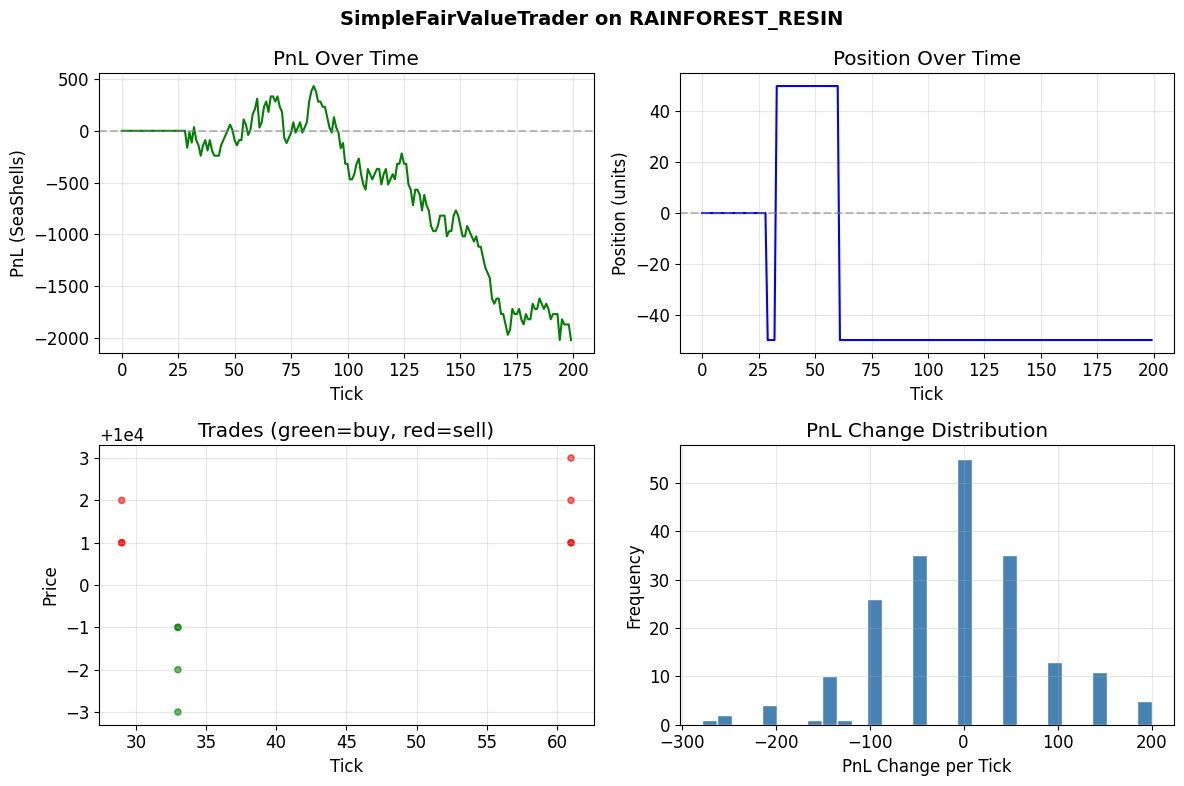

Final PnL: -2,018 SeaShells
Total trades: 11
Avg trade size: 22.7 units


In [28]:
# ── Demo: Run SimpleFairValueTrader Through Backtester ─────────

# Generate 200 ticks of synthetic data for RAINFOREST_RESIN
states, true_prices = generate_synthetic_states(
    symbol="RAINFOREST_RESIN",
    num_ticks=200,
    base_price=10000,
    volatility=2.0,
    spread=4,
    position_limit=50,
)

# Create and backtest the trader
trader = SimpleFairValueTrader(
    symbol="RAINFOREST_RESIN",
    fair_price=10000,
    position_limit=50,
)

results = backtest_trader(
    trader_instance=trader,
    states=states,
    position_limits={"RAINFOREST_RESIN": 50},
)

# Visualize
plot_backtest_results(results, title="SimpleFairValueTrader on RAINFOREST_RESIN")

DoNothingTrader PnL: 0
SimpleFairValue PnL: -1,451
Difference: -1,451


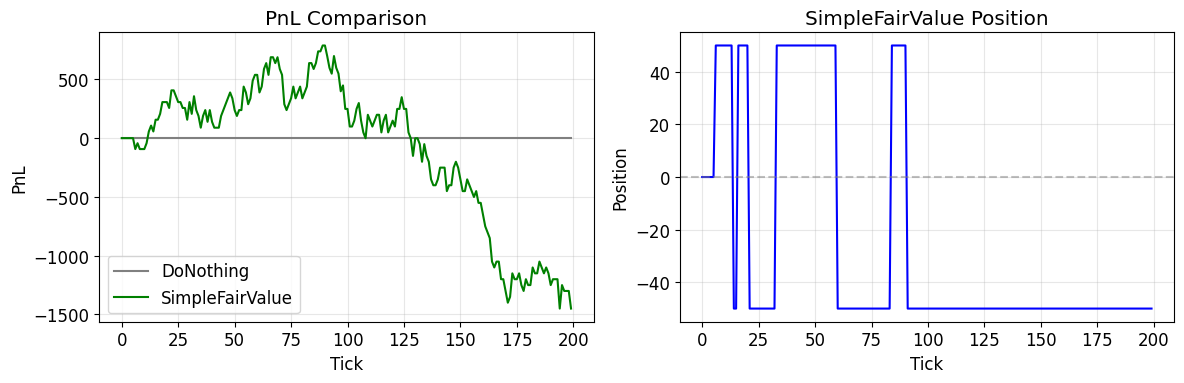

In [29]:
# ── EXERCISE: Compare DoNothingTrader vs SimpleFairValueTrader ─
# Run both traders on the same data and compare PnL.

# Generate shared data
shared_states, shared_prices = generate_synthetic_states(
    symbol="RAINFOREST_RESIN",
    num_ticks=200,
    base_price=10000,
    volatility=2.0,
    position_limit=50,
)

# Run DoNothingTrader
do_nothing = DoNothingTrader()
nothing_results = backtest_trader(do_nothing, shared_states, {"RAINFOREST_RESIN": 50})

# Run SimpleFairValueTrader
simple_trader = SimpleFairValueTrader("RAINFOREST_RESIN", 10000, 50)
simple_results = backtest_trader(simple_trader, shared_states, {"RAINFOREST_RESIN": 50})

# Compare
print(f"DoNothingTrader PnL: {nothing_results['final_pnl']:,.0f}")
print(f"SimpleFairValue PnL: {simple_results['final_pnl']:,.0f}")
print(f"Difference: {simple_results['final_pnl'] - nothing_results['final_pnl']:,.0f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(nothing_results["pnl_history"], label="DoNothing", color="gray")
axes[0].plot(simple_results["pnl_history"], label="SimpleFairValue", color="green")
axes[0].set_title("PnL Comparison")
axes[0].set_xlabel("Tick")
axes[0].set_ylabel("PnL")
axes[0].legend()

axes[1].plot(simple_results["position_history"], color="blue")
axes[1].set_title("SimpleFairValue Position")
axes[1].set_xlabel("Tick")
axes[1].set_ylabel("Position")
axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

> **Intuition Check:** Why does `DoNothingTrader` have PnL exactly 0? Because PnL only changes when you trade. If you never buy or sell, your cash stays at 0 and you hold no positions. The SimpleFairValueTrader profits by buying below fair value and selling above it - this is the essence of market making.

### 1.6 The Logger Class

AWS Lambda (where your bot runs) limits **print output to approximately 3,750 characters** per tick. If you exceed this, output is silently truncated - you lose your debug logs. The solution: a **Logger class** that manages your output budget.

The pattern below is based on Alpha Animals (Prosperity 3, 9th place). It tracks log size and truncates intelligently.

In [30]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Logger Class
# Manages print output within AWS Lambda's ~3750 char limit.
# Based on the pattern used by Alpha Animals (P3, 9th place).
# ══════════════════════════════════════════════════════════════

class Logger:
    def __init__(self, max_log_length: int = 3750):
        self.logs = ""
        self.max_log_length = max_log_length

    def log(self, *objects, sep: str = " ", end: str = "\\n") -> None:
        # Add a message to the log buffer (does NOT print yet)
        message = sep.join(str(obj) for obj in objects) + end
        self.logs += message

    def flush(self) -> None:
        # Print all logs, truncating if needed
        output = self.logs
        if len(output) > self.max_log_length:
            # Keep the first part and add truncation notice
            cutoff = self.max_log_length - 30
            output = output[:cutoff] + "\\n... [TRUNCATED] ..."
        if output:
            print(output, end="")
        self.logs = ""

    def remaining_space(self) -> int:
        # How many characters can still be logged
        return max(0, self.max_log_length - len(self.logs))


# Demo
logger_demo = Logger(max_log_length=200)  # small limit for demo
for i in range(20):
    logger_demo.log(f"Tick {i}: price=10000, position=0, orders=5")

print(f"Log buffer size: {len(logger_demo.logs)} chars")
print(f"Remaining space: {logger_demo.remaining_space()} chars")
print("--- Flushing ---")
logger_demo.flush()

Log buffer size: 870 chars
Remaining space: 0 chars
--- Flushing ---
Tick 0: price=10000, position=0, orders=5\nTick 1: price=10000, position=0, orders=5\nTick 2: price=10000, position=0, orders=5\nTick 3: price=10000, position=0, orders=5\n... [TRUNCATED] ...

In [31]:
# ── EXERCISE + SOLUTION: Priority Logger ───────────────────────

class PriorityLogger(Logger):
    # A logger that categorizes messages by importance.
    # ERROR messages are always kept, DEBUG messages are dropped first.

    def __init__(self, max_log_length: int = 3750):
        super().__init__(max_log_length)
        self.error_logs = []
        self.info_logs = []
        self.debug_logs = []

    def error(self, message: str) -> None:
        # Always kept
        self.error_logs.append(f"[ERROR] {message}")

    def info(self, message: str) -> None:
        # Kept if space allows
        self.info_logs.append(f"[INFO] {message}")

    def debug(self, message: str) -> None:
        # Dropped first if space is tight
        self.debug_logs.append(f"[DEBUG] {message}")

    def flush(self) -> None:
        # Build output: errors first, then info, then debug
        parts = []
        remaining = self.max_log_length

        # Always include errors
        for msg in self.error_logs:
            parts.append(msg)
            remaining -= len(msg) + 1

        # Include info if space allows
        for msg in self.info_logs:
            if remaining > len(msg) + 1:
                parts.append(msg)
                remaining -= len(msg) + 1

        # Include debug only with leftover space
        for msg in self.debug_logs:
            if remaining > len(msg) + 1:
                parts.append(msg)
                remaining -= len(msg) + 1

        output = "\\n".join(parts)
        if output:
            print(output)

        # Reset
        self.error_logs = []
        self.info_logs = []
        self.debug_logs = []


# Demo
plogger = PriorityLogger(max_log_length=200)
plogger.error("Position limit exceeded!")
plogger.info("Placed 3 buy orders")
plogger.info("Placed 2 sell orders")
plogger.debug("Best bid: 9998")
plogger.debug("Best ask: 10002")
plogger.debug("EMA: 10000.5")
plogger.debug("Spread: 4")
plogger.debug("Volume imbalance: 0.6")
print("--- Priority Logger Output ---")
plogger.flush()

--- Priority Logger Output ---
[ERROR] Position limit exceeded!\n[INFO] Placed 3 buy orders\n[INFO] Placed 2 sell orders\n[DEBUG] Best bid: 9998\n[DEBUG] Best ask: 10002\n[DEBUG] EMA: 10000.5\n[DEBUG] Spread: 4


### Part 1 Summary

You now have all the engineering tools for IMC Prosperity:

| Tool | Purpose | Competition Use |
|------|---------|-----------------|
| **Dictionaries** | O(1) lookup | Order book access |
| **Deque** | O(1) rolling window | Price history, moving averages |
| **datamodel.py** | Official data types | TradingState, Order, OrderDepth |
| **JSON serialization** | State persistence | traderData between ticks |
| **Trader skeleton** | Bot structure | Your submission file |
| **Backtester** | Local testing | Validate before submitting |
| **Logger** | Output management | Stay under 3750 char limit |

In Part 2, we will add the mathematical tools: statistics, moving averages, regression, and probability.

## Part 2: Math & Statistics for Trading

In this part you will learn:
1. **Descriptive statistics** - mean, standard deviation, z-score
2. **Moving averages** - SMA, EMA, Bollinger Bands
3. **Linear regression** - fitting trends, R-squared, cross-year predictions
4. **Correlation & cointegration** - pairs trading foundations
5. **Probability & expected value** - auctions, Kelly Criterion

Every concept is shown twice: first as **submission-safe pure Python** (what you can use in competition), then as an **analysis version** with numpy/matplotlib (for local research).

### 2.1 Descriptive Statistics

Statistics tells you what **normal** looks like, so you can spot what is **abnormal**. The **z-score** is your best friend in trading: it tells you how many standard deviations away from the mean a price is.

**Worked example:** KELP prices over 10 ticks: `[4985, 5010, 4995, 5005, 5000, 4990, 5015, 4998, 5003, 5007]`.
- Mean = 5000.8
- Standard deviation = 8.7
- If the next price is 5025, z = (5025 - 5000.8) / 8.7 = **2.78**
- That is 2.78 standard deviations above normal - very unusual!

For **mean-reverting** products like SQUID_INK, a high z-score signals the price will likely come back toward the mean. This is the basis of statistical arbitrage.

In [32]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Pure Python Statistics
# No numpy needed - this code runs on the competition server.
# ══════════════════════════════════════════════════════════════

# Sample data: KELP prices over 10 ticks
price_values = [4985, 5010, 4995, 5005, 5000, 4990, 5015, 4998, 5003, 5007]

# Step 1: Compute the mean (average)
number_of_prices = len(price_values)
sum_of_prices = sum(price_values)
price_mean = sum_of_prices / number_of_prices
print(f"Number of prices: {number_of_prices}")
print(f"Sum: {sum_of_prices}")
print(f"Mean: {price_mean}")

# Step 2: Compute standard deviation
# Variance = average of squared differences from the mean
squared_differences = [(price - price_mean) ** 2 for price in price_values]
variance = sum(squared_differences) / number_of_prices
standard_deviation = math.sqrt(variance)
print(f"Variance: {variance:.2f}")
print(f"Standard deviation: {standard_deviation:.2f}")

# Step 3: Compute z-score for a new price observation
new_price = 5025
z_score = (new_price - price_mean) / standard_deviation
print(f"\\nNew price: {new_price}")
print(f"Z-score: {z_score:.2f}")
print(f"This price is {abs(z_score):.1f} standard deviations {'above' if z_score > 0 else 'below'} the mean")

# Helper functions for reuse
def pure_mean(values: list) -> float:
    # Compute arithmetic mean of a list of numbers
    return sum(values) / len(values) if values else 0.0

def pure_std(values: list) -> float:
    # Compute population standard deviation
    if len(values) < 2:
        return 0.0
    mean_val = pure_mean(values)
    sq_diffs = [(v - mean_val) ** 2 for v in values]
    return math.sqrt(sum(sq_diffs) / len(sq_diffs))

def pure_zscore(value: float, values: list) -> float:
    # Compute z-score of a value relative to a list
    std = pure_std(values)
    if std == 0:
        return 0.0  # avoid division by zero
    return (value - pure_mean(values)) / std

print(f"\\nVerify with helpers: mean={pure_mean(price_values):.1f}, std={pure_std(price_values):.2f}")

Number of prices: 10
Sum: 50008
Mean: 5000.8
Variance: 75.56
Standard deviation: 8.69
\nNew price: 5025
Z-score: 2.78
This price is 2.8 standard deviations above the mean
\nVerify with helpers: mean=5000.8, std=8.69


In [33]:
# ══════════════════════════════════════════════════════════════
# [ANALYSIS VERSION] Same computation with numpy
# Much shorter, but NOT available in competition submissions.
# ══════════════════════════════════════════════════════════════

price_array = np.array(price_values)

numpy_mean = np.mean(price_array)
numpy_std = np.std(price_array)
numpy_zscore = (new_price - numpy_mean) / numpy_std

print(f"NumPy mean: {numpy_mean:.1f}")
print(f"NumPy std:  {numpy_std:.2f}")
print(f"NumPy z-score of {new_price}: {numpy_zscore:.2f}")

# Verify they match our pure Python implementation
print(f"\\nDifference in mean: {abs(numpy_mean - price_mean):.10f}")
print(f"Difference in std: {abs(numpy_std - standard_deviation):.10f}")
print("They match! Use pure Python in submissions, numpy for analysis.")

NumPy mean: 5000.8
NumPy std:  8.69
NumPy z-score of 5025: 2.78
\nDifference in mean: 0.0000000000
Difference in std: 0.0000000000
They match! Use pure Python in submissions, numpy for analysis.


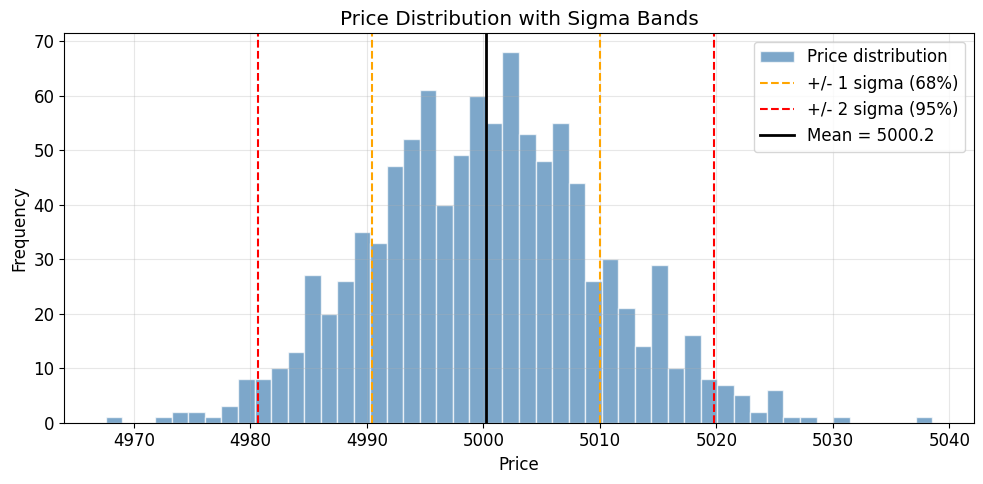

Mean: 5000.2
Std: 9.79
68% of prices fall between 4990.4 and 5010.0
95% of prices fall between 4980.6 and 5019.8


In [34]:
# ── Histogram with Sigma Bands ─────────────────────────────────
# Visualize the price distribution and show where +/- 1, 2 sigma fall.

np.random.seed(42)
# Generate 1000 simulated prices around 5000 with std ~10
simulated_prices = np.random.normal(5000, 10, 1000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(simulated_prices, bins=50, color="steelblue", edgecolor="white", alpha=0.7,
        label="Price distribution")

sim_mean = np.mean(simulated_prices)
sim_std = np.std(simulated_prices)

# Draw sigma bands
for sigma, color, label in [(1, "orange", "+/- 1 sigma (68%)"),
                             (2, "red", "+/- 2 sigma (95%)")]:
    ax.axvline(sim_mean + sigma * sim_std, color=color, linestyle="--", linewidth=1.5)
    ax.axvline(sim_mean - sigma * sim_std, color=color, linestyle="--", linewidth=1.5,
               label=label)

ax.axvline(sim_mean, color="black", linewidth=2, label=f"Mean = {sim_mean:.1f}")
ax.set_title("Price Distribution with Sigma Bands")
ax.set_xlabel("Price")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean: {sim_mean:.1f}")
print(f"Std: {sim_std:.2f}")
print(f"68% of prices fall between {sim_mean - sim_std:.1f} and {sim_mean + sim_std:.1f}")
print(f"95% of prices fall between {sim_mean - 2*sim_std:.1f} and {sim_mean + 2*sim_std:.1f}")

> **Intuition Check:** If the z-score is greater than 2, the price is in the **top 2.5%** of observations. For mean-reverting products like SQUID_INK, this signals the price is unusually high and will likely come back down. A z-score below -2 signals the price is unusually low and will likely rise. This is the foundation of **mean-reversion trading**.

In [35]:
# ── EXERCISE: RollingStats Class ───────────────────────────────
# Build a class that maintains a rolling window of prices
# and computes mean, std, z_score on demand.

# YOUR CODE HERE:
# class RollingStats:
#     def __init__(self, window_size: int):
#         ...
#     def add(self, value: float): ...
#     def mean(self) -> float: ...
#     def std(self) -> float: ...
#     def z_score(self, value: float) -> float: ...

print("Complete the exercise above, then check the solution below.")

Complete the exercise above, then check the solution below.


In [36]:
# ── SOLUTION ───────────────────────────────────────────────────

class RollingStats:
    # [SUBMISSION-SAFE] Maintains rolling statistics over a window.
    # Uses deque for O(1) append/pop operations.

    def __init__(self, window_size: int):
        self.values = deque(maxlen=window_size)

    def add(self, value: float) -> None:
        # Add a new value to the rolling window
        self.values.append(value)

    def mean(self) -> float:
        # Compute mean of the current window
        if len(self.values) == 0:
            return 0.0
        return sum(self.values) / len(self.values)

    def std(self) -> float:
        # Compute population standard deviation
        if len(self.values) < 2:
            return 0.0
        mean_val = self.mean()
        sq_diffs = [(v - mean_val) ** 2 for v in self.values]
        return math.sqrt(sum(sq_diffs) / len(sq_diffs))

    def z_score(self, value: float) -> float:
        # Compute z-score of a value relative to the window
        std_val = self.std()
        if std_val == 0:
            return 0.0
        return (value - self.mean()) / std_val

# Demo
stats = RollingStats(window_size=10)
test_prices = [4985, 5010, 4995, 5005, 5000, 4990, 5015, 4998, 5003, 5007, 5025]

for price in test_prices:
    stats.add(price)
    if len(stats.values) >= 5:
        z = stats.z_score(price)
        print(f"Price {price}: mean={stats.mean():.1f} std={stats.std():.2f} z={z:+.2f}")

Price 5000: mean=4999.0 std=8.60 z=+0.12
Price 4990: mean=4997.5 std=8.54 z=-0.88
Price 5015: mean=5000.0 std=10.00 z=+1.50
Price 4998: mean=4999.8 std=9.38 z=-0.19
Price 5003: mean=5000.1 std=8.90 z=+0.32
Price 5007: mean=5000.8 std=8.69 z=+0.71
Price 5025: mean=5004.8 std=9.65 z=+2.09


> **Common Mistake:** Division by zero! If all prices in the window are identical, the standard deviation is 0, and dividing by it crashes your bot. Always check `if std > 0:` before computing z-scores. This is a common cause of runtime errors in competition.

> **From the Winners:** pe049395 (Prosperity 2, 13th place) used **rolling statistics** (recalculated each tick) rather than fitted distributions. They found that "empirical execution probability was more reliable than theoretical distribution models."

### 2.2 Moving Averages

A **Simple Moving Average (SMA)** gives equal weight to all recent prices. An **Exponential Moving Average (EMA)** gives more weight to recent prices. Think of SMA as a **democratic vote** (every price gets one vote) and EMA as **"what happened recently matters more"** (recent prices get louder votes).

In Prosperity, EMA is preferred because it adapts faster to changing fair values. Frankfurt Hedgehogs used "Wall Mid" (a type of weighted average) as their primary fair value estimate.

In [37]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Simple Moving Average with deque
# ══════════════════════════════════════════════════════════════

def compute_sma(prices: list, window_size: int) -> list:
    # Compute SMA for each point in the price series.
    # Uses deque for efficient O(1) append/pop.

    window = deque(maxlen=window_size)
    sma_values = []

    for price in prices:
        window.append(price)
        if len(window) == window_size:
            sma_value = sum(window) / len(window)
            sma_values.append(sma_value)
        else:
            sma_values.append(None)  # not enough data yet

    return sma_values

# Demo with synthetic KELP prices
kelp_prices = [5000, 5005, 4998, 5010, 5003, 4995, 5012, 5008, 4997, 5015,
               5002, 4990, 5020, 5007, 5001, 4993, 5018, 5011, 4999, 5014]

sma_5 = compute_sma(kelp_prices, window_size=5)
print("KELP prices with SMA(5):")
for i, (price, sma) in enumerate(zip(kelp_prices, sma_5)):
    sma_str = f"{sma:.1f}" if sma is not None else "  N/A"
    print(f"  Tick {i:>2}: price={price}  SMA(5)={sma_str}")

KELP prices with SMA(5):
  Tick  0: price=5000  SMA(5)=  N/A
  Tick  1: price=5005  SMA(5)=  N/A
  Tick  2: price=4998  SMA(5)=  N/A
  Tick  3: price=5010  SMA(5)=  N/A
  Tick  4: price=5003  SMA(5)=5003.2
  Tick  5: price=4995  SMA(5)=5002.2
  Tick  6: price=5012  SMA(5)=5003.6
  Tick  7: price=5008  SMA(5)=5005.6
  Tick  8: price=4997  SMA(5)=5003.0
  Tick  9: price=5015  SMA(5)=5005.4
  Tick 10: price=5002  SMA(5)=5006.8
  Tick 11: price=4990  SMA(5)=5002.4
  Tick 12: price=5020  SMA(5)=5004.8
  Tick 13: price=5007  SMA(5)=5006.8
  Tick 14: price=5001  SMA(5)=5004.0
  Tick 15: price=4993  SMA(5)=5002.2
  Tick 16: price=5018  SMA(5)=5007.8
  Tick 17: price=5011  SMA(5)=5006.0
  Tick 18: price=4999  SMA(5)=5004.4
  Tick 19: price=5014  SMA(5)=5007.0


In [38]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Exponential Moving Average
# Only needs ONE variable - no history storage required!
# ══════════════════════════════════════════════════════════════

def compute_ema_series(prices: list, alpha: float = 0.3) -> list:
    # Compute EMA for each price in the series.
    # alpha = smoothing factor (0.3 = 30% weight on new, 70% on old)
    # Higher alpha = more responsive to new data

    ema_values = []
    ema_current = prices[0]  # initialize with first price

    for price in prices:
        # EMA update: blend new price with old EMA
        ema_current = alpha * price + (1 - alpha) * ema_current
        ema_values.append(ema_current)

    return ema_values

# Demo: show step-by-step computation
alpha = 0.3
ema_value = kelp_prices[0]
print(f"EMA alpha = {alpha}")
print(f"{'Tick':>4} {'Price':>6} {'Calculation':>40} {'EMA':>8}")
print("-" * 65)

for i, price in enumerate(kelp_prices[:8]):
    old_ema = ema_value
    ema_value = alpha * price + (1 - alpha) * ema_value
    calc = f"{alpha}*{price} + {1-alpha}*{old_ema:.1f}"
    print(f"{i:>4} {price:>6} {calc:>40} {ema_value:>8.1f}")

EMA alpha = 0.3
Tick  Price                              Calculation      EMA
-----------------------------------------------------------------
   0   5000                    0.3*5000 + 0.7*5000.0   5000.0
   1   5005                    0.3*5005 + 0.7*5000.0   5001.5
   2   4998                    0.3*4998 + 0.7*5001.5   5000.4
   3   5010                    0.3*5010 + 0.7*5000.4   5003.3
   4   5003                    0.3*5003 + 0.7*5003.3   5003.2
   5   4995                    0.3*4995 + 0.7*5003.2   5000.8
   6   5012                    0.3*5012 + 0.7*5000.8   5004.1
   7   5008                    0.3*5008 + 0.7*5004.1   5005.3


**EMA formula with real numbers:**

If EMA = 5000.0 and new price = 5020, with alpha = 0.3:
- new EMA = 0.3 * 5020 + 0.7 * 5000.0
- new EMA = 1506.0 + 3500.0
- new EMA = **5006.0**

The EMA moved 6 points toward the new price (30% of the 20-point gap). With alpha = 0.1, it would only move 2 points. Higher alpha = faster response = more noise sensitivity. Lower alpha = smoother = slower to detect real changes.

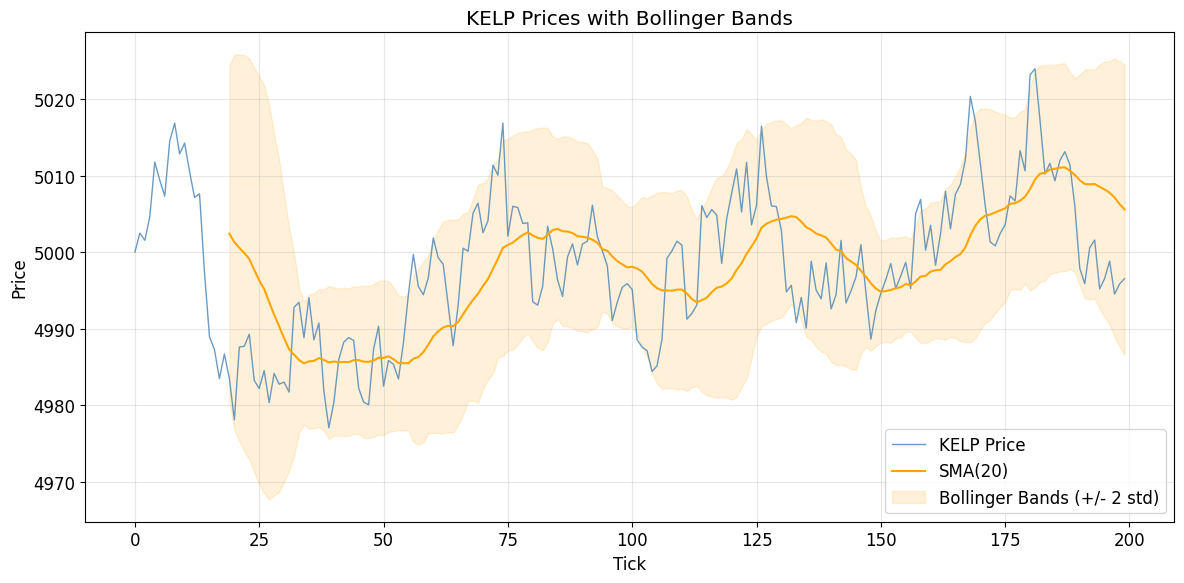

Prices touching the upper band may be overbought (sell signal)
Prices touching the lower band may be oversold (buy signal)


In [39]:
# ── Bollinger Bands Visualization ──────────────────────────────
# Bollinger Bands = SMA +/- 2 * rolling standard deviation
# When price touches the upper band = potentially overbought
# When price touches the lower band = potentially oversold

np.random.seed(42)
# Generate 200 synthetic KELP prices with mean-reverting behavior
synthetic_kelp = [5000.0]
for _ in range(199):
    # Mean-reverting random walk
    mean_reversion = -0.1 * (synthetic_kelp[-1] - 5000)
    noise = np.random.normal(0, 5)
    synthetic_kelp.append(synthetic_kelp[-1] + mean_reversion + noise)

synthetic_kelp = np.array(synthetic_kelp)

# Compute Bollinger Bands
window = 20
sma = pd.Series(synthetic_kelp).rolling(window).mean()
std = pd.Series(synthetic_kelp).rolling(window).std()
upper_band = sma + 2 * std
lower_band = sma - 2 * std

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(synthetic_kelp, color="steelblue", linewidth=1, alpha=0.8, label="KELP Price")
ax.plot(sma, color="orange", linewidth=1.5, label=f"SMA({window})")
ax.fill_between(range(len(synthetic_kelp)), upper_band, lower_band,
                alpha=0.15, color="orange", label="Bollinger Bands (+/- 2 std)")
ax.set_title("KELP Prices with Bollinger Bands")
ax.set_xlabel("Tick")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()

print("Prices touching the upper band may be overbought (sell signal)")
print("Prices touching the lower band may be oversold (buy signal)")

In [40]:
# ── EXERCISE + SOLUTION: EMA Convergence ───────────────────────
# Show that EMA with alpha = 2/(N+1) behaves similarly to SMA(N)

window_size = 10
equivalent_alpha = 2.0 / (window_size + 1)
print(f"SMA window: {window_size}")
print(f"Equivalent EMA alpha: {equivalent_alpha:.4f}")

# Compute both on the same data
sma_vals = compute_sma(kelp_prices, window_size)
ema_vals = compute_ema_series(kelp_prices, alpha=equivalent_alpha)

print(f"\\n{'Tick':>4} {'Price':>6} {'SMA':>8} {'EMA':>8} {'Diff':>8}")
print("-" * 40)
for i in range(len(kelp_prices)):
    sma_v = f"{sma_vals[i]:.1f}" if sma_vals[i] is not None else "  N/A"
    ema_v = f"{ema_vals[i]:.1f}"
    if sma_vals[i] is not None:
        diff = f"{abs(ema_vals[i] - sma_vals[i]):.1f}"
    else:
        diff = "  N/A"
    print(f"{i:>4} {kelp_prices[i]:>6} {sma_v:>8} {ema_v:>8} {diff:>8}")

print("\\nEMA and SMA converge as the window fills up.")
print("EMA is preferred in competition because it needs only ONE variable to store.")

SMA window: 10
Equivalent EMA alpha: 0.1818
\nTick  Price      SMA      EMA     Diff
----------------------------------------
   0   5000      N/A   5000.0      N/A
   1   5005      N/A   5000.9      N/A
   2   4998      N/A   5000.4      N/A
   3   5010      N/A   5002.1      N/A
   4   5003      N/A   5002.3      N/A
   5   4995      N/A   5001.0      N/A
   6   5012      N/A   5003.0      N/A
   7   5008      N/A   5003.9      N/A
   8   4997      N/A   5002.6      N/A
   9   5015   5004.3   5004.9      0.6
  10   5002   5004.5   5004.4      0.1
  11   4990   5003.0   5001.7      1.3
  12   5020   5005.2   5005.1      0.1
  13   5007   5004.9   5005.4      0.5
  14   5001   5004.7   5004.6      0.1
  15   4993   5004.5   5002.5      2.0
  16   5018   5005.1   5005.3      0.2
  17   5011   5005.4   5006.4      1.0
  18   4999   5005.6   5005.0      0.6
  19   5014   5005.5   5006.6      1.1
\nEMA and SMA converge as the window fills up.
EMA is preferred in competition because it need

> **From the Winners:** Frankfurt Hedgehogs (Prosperity 3, 2nd place) used **Wall Mid** as their fair value estimate: "the midpoint between the deepest bid and deepest ask." Wall Mid is more stable than the simple best-bid/best-ask midpoint because it ignores aggressive penny orders placed by algorithmic traders trying to manipulate the midpoint.

### 2.3 Linear Regression

**Linear regression** fits a straight line through data points. Think of it as laying a ruler on a scatter plot and finding the angle. The line tells you the **trend** - is the price going up, down, or sideways?

The key output is **R-squared** (R^2): how well the line fits the data. R^2 = 1.0 means a perfect fit; R^2 = 0.0 means the line explains nothing. In Prosperity 2, one team found R^2 = 0.99 between years of data - an almost perfect linear relationship.

In [41]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Pure Python Linear Regression
# Uses the least-squares formula to fit y = slope*x + intercept.
# ══════════════════════════════════════════════════════════════

def linear_regression(x_values: list, y_values: list) -> tuple:
    # Fit a line y = slope * x + intercept using least squares.
    # Returns: (slope, intercept, r_squared)

    n = len(x_values)
    if n < 2:
        return 0.0, 0.0, 0.0

    # Compute means
    x_mean = sum(x_values) / n
    y_mean = sum(y_values) / n

    # Compute slope: sum((x-xmean)*(y-ymean)) / sum((x-xmean)^2)
    numerator = sum((x_values[i] - x_mean) * (y_values[i] - y_mean) for i in range(n))
    denominator = sum((x_values[i] - x_mean) ** 2 for i in range(n))

    if denominator == 0:
        return 0.0, y_mean, 0.0

    slope = numerator / denominator
    intercept = y_mean - slope * x_mean

    # Compute R-squared
    y_predicted = [slope * x + intercept for x in x_values]
    ss_residual = sum((y_values[i] - y_predicted[i]) ** 2 for i in range(n))
    ss_total = sum((y_values[i] - y_mean) ** 2 for i in range(n))

    r_squared = 1.0 - (ss_residual / ss_total) if ss_total > 0 else 0.0

    return slope, intercept, r_squared


# Demo: fit a line to KELP prices over time
tick_numbers = list(range(len(kelp_prices)))
slope, intercept, r_squared = linear_regression(tick_numbers, kelp_prices)

print(f"Slope: {slope:.4f} (price change per tick)")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {r_squared:.4f}")
print(f"\\nTrend: prices are {'rising' if slope > 0 else 'falling'} at {abs(slope):.2f} per tick")

# Predict next price
next_tick = len(kelp_prices)
predicted_price = slope * next_tick + intercept
print(f"Predicted price at tick {next_tick}: {predicted_price:.1f}")

Slope: 0.2992 (price change per tick)
Intercept: 5002.06
R-squared: 0.0435
\nTrend: prices are rising at 0.30 per tick
Predicted price at tick 20: 5008.0


NumPy slope: 0.2992
NumPy intercept: 5002.06
NumPy R-squared: 0.0435


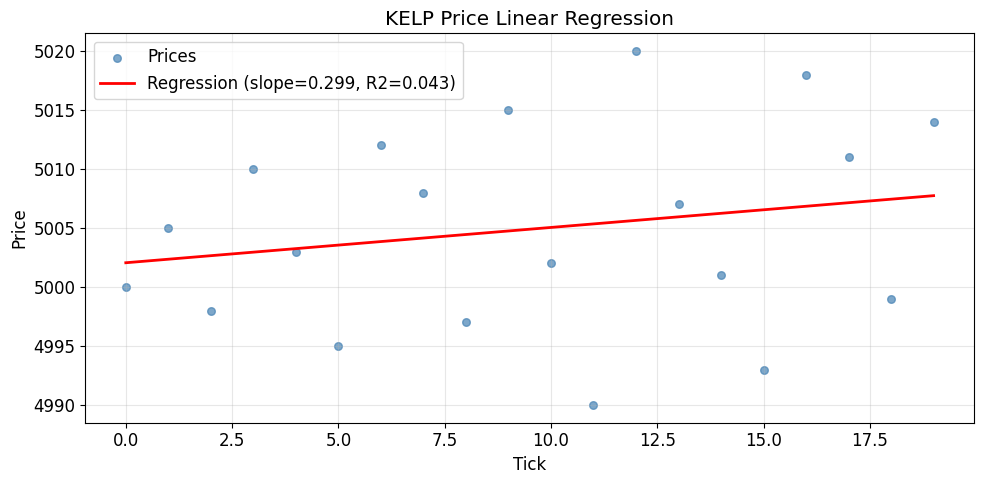

In [42]:
# ══════════════════════════════════════════════════════════════
# [ANALYSIS VERSION] Linear Regression with numpy
# ══════════════════════════════════════════════════════════════

x_array = np.array(tick_numbers)
y_array = np.array(kelp_prices)

# numpy polyfit gives coefficients [slope, intercept]
coefficients = np.polyfit(x_array, y_array, deg=1)
numpy_slope = coefficients[0]
numpy_intercept = coefficients[1]

# Compute R-squared using numpy
y_pred = np.polyval(coefficients, x_array)
ss_res = np.sum((y_array - y_pred) ** 2)
ss_tot = np.sum((y_array - np.mean(y_array)) ** 2)
numpy_r_squared = 1 - ss_res / ss_tot

print(f"NumPy slope: {numpy_slope:.4f}")
print(f"NumPy intercept: {numpy_intercept:.2f}")
print(f"NumPy R-squared: {numpy_r_squared:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(tick_numbers, kelp_prices, color="steelblue", s=30, label="Prices", alpha=0.7)
ax.plot(tick_numbers, y_pred, color="red", linewidth=2,
        label=f"Regression (slope={numpy_slope:.3f}, R2={numpy_r_squared:.3f})")
ax.set_title("KELP Price Linear Regression")
ax.set_xlabel("Tick")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()

> **From the Winners:** Linear Utility (Prosperity 2, 2nd place) discovered that price data from different competition years was almost perfectly correlated: **R-squared = 0.99** with a multiplier of approximately 1.25x. This single insight earned them approximately **2.1 million SeaShells** in one round. They used regression on historical data to predict future prices before anyone else.

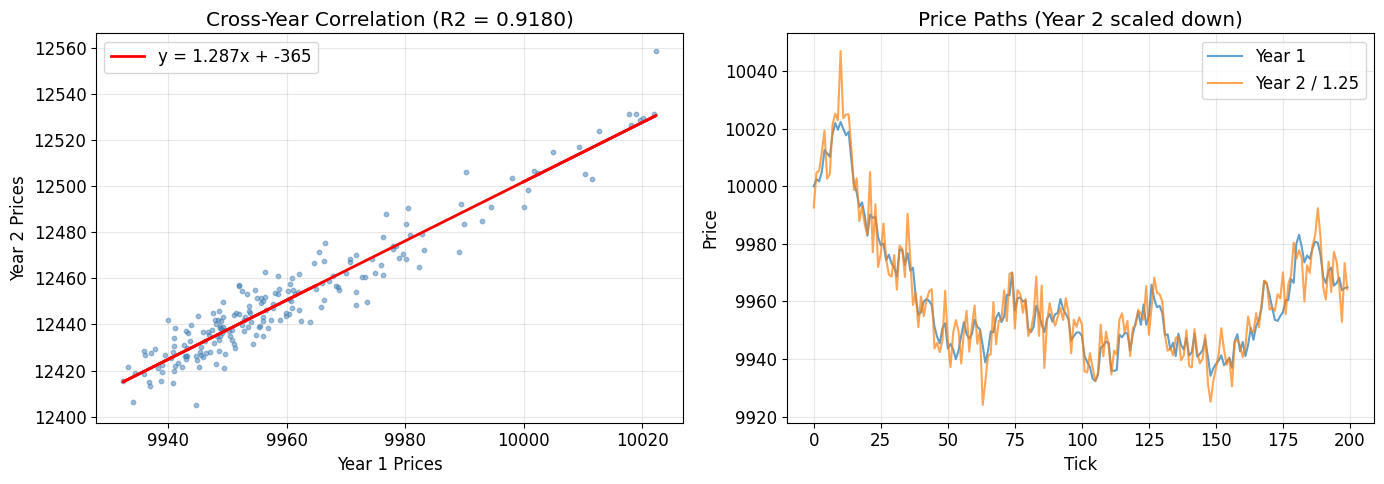

Multiplier found: 1.287 (true: 1.25)
R-squared: 0.9180
This means 91.8% of Year 2 variance is explained by Year 1!


In [43]:
# ── Cross-Year Correlation Demo ────────────────────────────────
# Simulate what Linear Utility discovered: prices from Year 1
# predict Year 2 prices with R^2 = 0.99.

np.random.seed(42)
num_points = 200

# Year 1 prices: random walk
year_1_prices = [10000.0]
for _ in range(num_points - 1):
    year_1_prices.append(year_1_prices[-1] + np.random.normal(0, 5))
year_1_prices = np.array(year_1_prices)

# Year 2 prices: correlated with Year 1 (multiplier 1.25, small noise)
multiplier = 1.25
noise_level = 8.0
year_2_prices = multiplier * year_1_prices + np.random.normal(0, noise_level, num_points)

# Compute regression
coeffs = np.polyfit(year_1_prices, year_2_prices, 1)
year_2_predicted = np.polyval(coeffs, year_1_prices)
r_squared = 1 - np.sum((year_2_prices - year_2_predicted)**2) / np.sum((year_2_prices - np.mean(year_2_prices))**2)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter plot
axes[0].scatter(year_1_prices, year_2_prices, s=10, alpha=0.5, color="steelblue")
axes[0].plot(year_1_prices, year_2_predicted, color="red", linewidth=2,
             label=f"y = {coeffs[0]:.3f}x + {coeffs[1]:.0f}")
axes[0].set_title(f"Cross-Year Correlation (R2 = {r_squared:.4f})")
axes[0].set_xlabel("Year 1 Prices")
axes[0].set_ylabel("Year 2 Prices")
axes[0].legend()

# Right: time series overlay
axes[1].plot(year_1_prices, label="Year 1", alpha=0.7)
axes[1].plot(year_2_prices / multiplier, label=f"Year 2 / {multiplier}", alpha=0.7)
axes[1].set_title("Price Paths (Year 2 scaled down)")
axes[1].set_xlabel("Tick")
axes[1].set_ylabel("Price")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Multiplier found: {coeffs[0]:.3f} (true: {multiplier})")
print(f"R-squared: {r_squared:.4f}")
print(f"This means {r_squared*100:.1f}% of Year 2 variance is explained by Year 1!")

True beta: 0.6
Found beta (slope): 0.5483
R-squared: 0.4981
Error: 0.0517


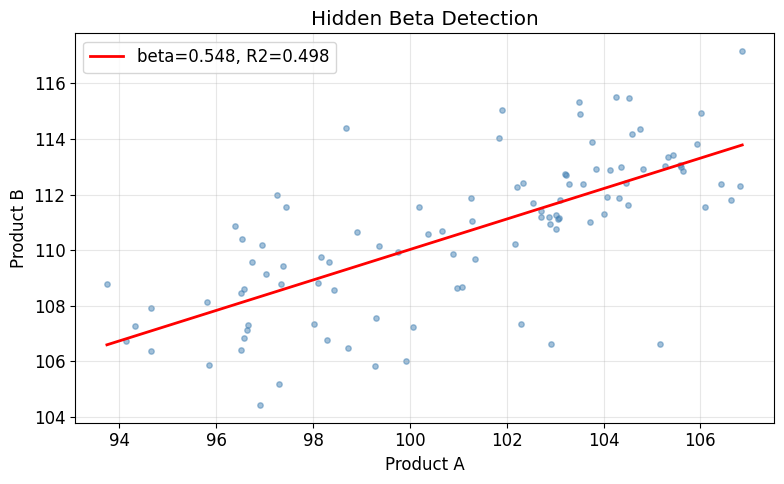

In [44]:
# ── EXERCISE + SOLUTION: Hidden Beta Detection ────────────────
# Given two price series, find the linear relationship (beta).

np.random.seed(123)
# Product A: random walk
product_a = np.cumsum(np.random.normal(0, 1, 100)) + 100
# Product B: 0.6 * A + noise (hidden beta = 0.6)
true_beta = 0.6
product_b = true_beta * product_a + np.random.normal(0, 2, 100) + 50

# Find the beta using regression
slope, intercept, r_sq = linear_regression(list(product_a), list(product_b))
print(f"True beta: {true_beta}")
print(f"Found beta (slope): {slope:.4f}")
print(f"R-squared: {r_sq:.4f}")
print(f"Error: {abs(slope - true_beta):.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(product_a, product_b, s=15, alpha=0.5, color="steelblue")
x_line = np.linspace(product_a.min(), product_a.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="red", linewidth=2,
        label=f"beta={slope:.3f}, R2={r_sq:.3f}")
ax.set_xlabel("Product A")
ax.set_ylabel("Product B")
ax.set_title("Hidden Beta Detection")
ax.legend()
plt.tight_layout()
plt.show()

> **Common Mistake:** Running linear regression on **raw prices** (which have high collinearity) gives unstable coefficients that change wildly with small data changes. Regress on **returns** or **price spreads** instead. Stanford Cardinal (P1, 2nd place) found that simple regression on the last 4-5 timestamps beat complex multi-feature models.

### 2.4 Correlation & Cointegration

**Correlation** means two things move in the same direction: when A goes up, B goes up. **Cointegration** means two things stay close together even if they wander - the gap between them is bounded.

**Analogy:** Think of two drunk friends walking home. If they are **correlated**, they both walk north. If they are **cointegrated**, they are tied together with a rope - they may stumble apart briefly, but the rope (the spread) always pulls them back together. The spread mean-reverts.

In Prosperity, PICNIC_BASKET is cointegrated with its components (CROISSANTS, JAMS, DJEMBES). When the basket price diverges from its component value, you can bet it will converge.

In [45]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Pearson Correlation
# ══════════════════════════════════════════════════════════════

def pearson_correlation(x_values: list, y_values: list) -> float:
    # Compute Pearson correlation coefficient between two lists.
    # Returns: r in range [-1, +1]

    n = len(x_values)
    if n < 2:
        return 0.0

    x_mean = sum(x_values) / n
    y_mean = sum(y_values) / n

    numerator = sum((x_values[i] - x_mean) * (y_values[i] - y_mean) for i in range(n))
    denom_x = math.sqrt(sum((x - x_mean) ** 2 for x in x_values))
    denom_y = math.sqrt(sum((y - y_mean) ** 2 for y in y_values))

    if denom_x == 0 or denom_y == 0:
        return 0.0

    return numerator / (denom_x * denom_y)

# Demo: correlated price series
np.random.seed(42)
base = np.cumsum(np.random.normal(0, 1, 50))
series_a = base + np.random.normal(0, 0.5, 50)   # highly correlated
series_b = base + np.random.normal(0, 2, 50)     # moderately correlated
series_c = np.random.normal(0, 1, 50)            # uncorrelated

corr_ab = pearson_correlation(list(series_a), list(series_b))
corr_ac = pearson_correlation(list(series_a), list(series_c))
print(f"Correlation(A, B): {corr_ab:.4f} (highly correlated)")
print(f"Correlation(A, C): {corr_ac:.4f} (uncorrelated)")

Correlation(A, B): 0.9106 (highly correlated)
Correlation(A, C): 0.1595 (uncorrelated)


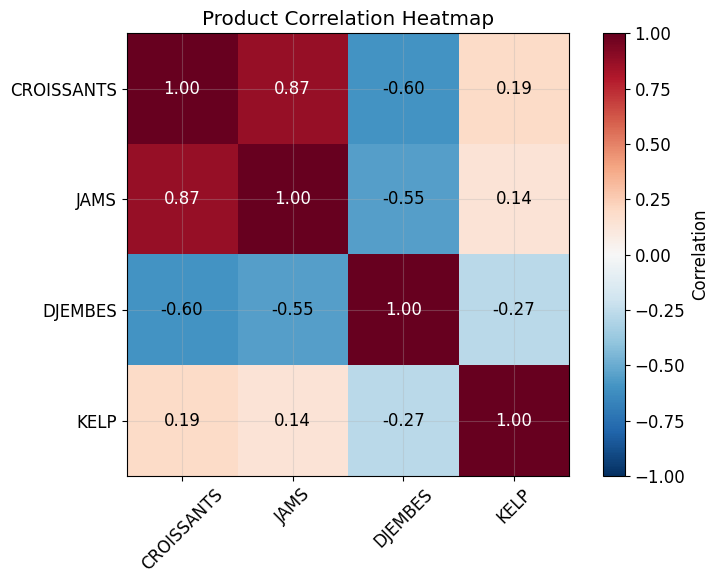

In [46]:
# ── Correlation Heatmap ────────────────────────────────────────
np.random.seed(42)
n_points = 100
base_signal = np.cumsum(np.random.normal(0, 1, n_points))

# 4 products with varying correlation
products = {
    "CROISSANTS": base_signal + np.random.normal(0, 1, n_points),
    "JAMS": 0.8 * base_signal + np.random.normal(0, 2, n_points),
    "DJEMBES": -0.5 * base_signal + np.random.normal(0, 3, n_points),
    "KELP": np.cumsum(np.random.normal(0, 1, n_points)),
}

# Compute pairwise correlations
product_names = list(products.keys())
n_products = len(product_names)
corr_matrix = np.zeros((n_products, n_products))

for i in range(n_products):
    for j in range(n_products):
        corr_matrix[i, j] = pearson_correlation(
            list(products[product_names[i]]),
            list(products[product_names[j]])
        )

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n_products))
ax.set_yticks(range(n_products))
ax.set_xticklabels(product_names, rotation=45)
ax.set_yticklabels(product_names)

# Add correlation values as text
for i in range(n_products):
    for j in range(n_products):
        ax.text(j, i, f"{corr_matrix[i, j]:.2f}", ha="center", va="center",
                color="black" if abs(corr_matrix[i, j]) < 0.7 else "white")

plt.colorbar(im, label="Correlation")
ax.set_title("Product Correlation Heatmap")
plt.tight_layout()
plt.show()

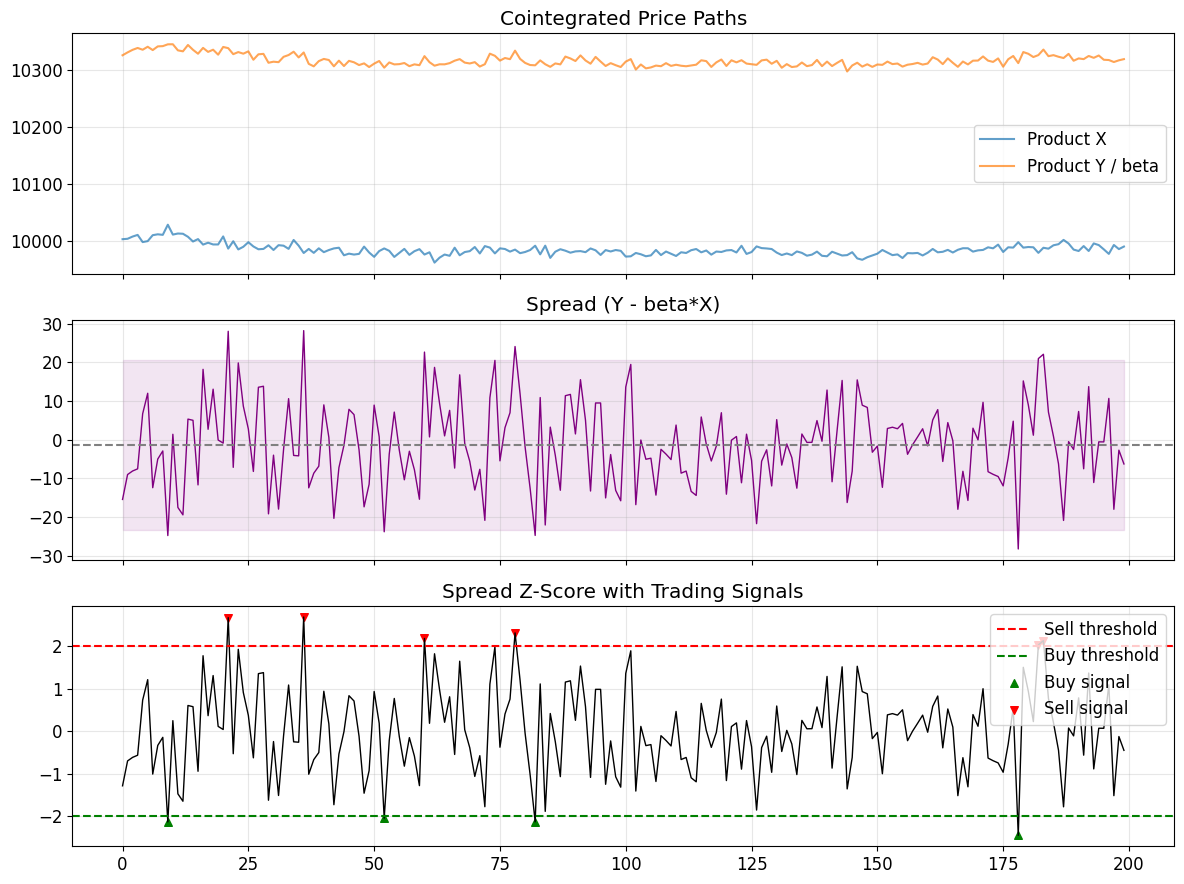

Spread mean: -1.33
Spread std: 11.01
Buy signals: 4
Sell signals: 6


In [47]:
# ── Cointegrated Pairs: Spread Trading ─────────────────────────
# Generate two cointegrated price series and trade the spread.

np.random.seed(42)
num_ticks = 200

# Shared random walk (the "common factor")
common_factor = np.cumsum(np.random.normal(0, 2, num_ticks)) + 10000

# Two cointegrated products
product_x = common_factor + np.random.normal(0, 5, num_ticks)
product_y = 1.5 * common_factor + np.random.normal(0, 8, num_ticks) + 500

# Compute spread: Y - beta * X
beta = 1.5
spread = product_y - beta * product_x - 500

# Compute z-score of spread
spread_mean = np.mean(spread)
spread_std = np.std(spread)
spread_zscore = (spread - spread_mean) / spread_std

# Generate trading signals
buy_signal = spread_zscore < -2   # spread unusually low = buy spread
sell_signal = spread_zscore > 2   # spread unusually high = sell spread

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Price paths
axes[0].plot(product_x, label="Product X", alpha=0.7)
axes[0].plot(product_y / beta, label="Product Y / beta", alpha=0.7)
axes[0].set_title("Cointegrated Price Paths")
axes[0].legend()

# Spread
axes[1].plot(spread, color="purple", linewidth=1)
axes[1].axhline(spread_mean, color="gray", linestyle="--")
axes[1].fill_between(range(num_ticks),
                     spread_mean - 2*spread_std, spread_mean + 2*spread_std,
                     alpha=0.1, color="purple")
axes[1].set_title("Spread (Y - beta*X)")

# Z-score with signals
axes[2].plot(spread_zscore, color="black", linewidth=1)
axes[2].axhline(2, color="red", linestyle="--", label="Sell threshold")
axes[2].axhline(-2, color="green", linestyle="--", label="Buy threshold")
axes[2].scatter(np.where(buy_signal)[0], spread_zscore[buy_signal],
                color="green", marker="^", s=30, label="Buy signal")
axes[2].scatter(np.where(sell_signal)[0], spread_zscore[sell_signal],
                color="red", marker="v", s=30, label="Sell signal")
axes[2].set_title("Spread Z-Score with Trading Signals")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Spread mean: {spread_mean:.2f}")
print(f"Spread std: {spread_std:.2f}")
print(f"Buy signals: {np.sum(buy_signal)}")
print(f"Sell signals: {np.sum(sell_signal)}")

> **From the Winners:** PICNIC_BASKET = 6 * CROISSANTS + 3 * JAMS + 1 * DJEMBES. The basket and its components are **cointegrated**. The spread (basket price minus component value) mean-reverts. Linear Utility (P2, 2nd place) used a z-score threshold of **11** on the basket spread (~370 SeaShells). When the spread exceeded 11 standard deviations, they traded aggressively.

> **Common Mistake:** Correlation is NOT cointegration! Two stocks trending upward are highly correlated, but their spread (difference) keeps growing and never reverts. Cointegration means the spread itself is **stationary** - it fluctuates around a constant mean. Always test the spread for mean-reversion before trading it.

### 2.5 Probability & Expected Value

**Expected value (EV)** is the average outcome if you repeated a bet infinitely many times. If a coin flip pays +10 on heads and -5 on tails:

EV = 0.5 * (+10) + 0.5 * (-5) = +2.50

A positive EV bet makes money in the long run. In Prosperity, every order you place is a bet. Your job is to find bets with positive EV and size them correctly using the **Kelly Criterion**.

In [48]:
# ── Basic Probability Computations ─────────────────────────────

# Example 1: Fair dice expected value
outcomes = [1, 2, 3, 4, 5, 6]
probability = 1 / len(outcomes)  # each outcome equally likely
expected_value = sum(outcome * probability for outcome in outcomes)
print(f"Fair dice EV: {expected_value:.2f}")

# Example 2: Profit from a trading order
# You place a buy at 9998. The fill probability is 60%.
# If filled, fair value is 10000, so you gain 2 per unit.
# If not filled, you gain nothing.
fill_probability = 0.60
profit_if_filled = 10000 - 9998  # = 2
expected_profit = fill_probability * profit_if_filled
print(f"\\nOrder fill probability: {fill_probability:.0%}")
print(f"Profit if filled: {profit_if_filled}")
print(f"Expected profit: {expected_profit:.2f} per unit")
print(f"For 50 units: {expected_profit * 50:.0f} SeaShells")

# Example 3: Should you cross the spread?
# Buy at 10002 (cross the spread to guarantee fill)
# Fair value = 10000, immediate loss = 2 per unit
# But you get 100% fill rate
cross_spread_ev = 1.0 * (10000 - 10002)  # -2
passive_order_ev = 0.6 * (10000 - 9998)  # +1.2

print(f"\\nCross spread EV: {cross_spread_ev:.1f} per unit (guaranteed fill)")
print(f"Passive order EV: {passive_order_ev:.1f} per unit (60% fill)")
print(f"Passive is better IF you can wait!")

Fair dice EV: 3.50
\nOrder fill probability: 60%
Profit if filled: 2
Expected profit: 1.20 per unit
For 50 units: 60 SeaShells
\nCross spread EV: -2.0 per unit (guaranteed fill)
Passive order EV: 1.2 per unit (60% fill)
Passive is better IF you can wait!


**Sealed-Bid Auction Derivation** (from Prosperity 2 manual round):

You bid on an item worth **V = 1000** to you. Your opponent bids uniformly between 900 and 1000. If you bid **x** and win (your bid is higher):

1. **P(win)** = P(opponent < x) = (x - 900) / 100
2. **Profit if win** = V - x = 1000 - x
3. **E[profit]** = P(win) * profit = ((x - 900) / 100) * (1000 - x)
4. **Expand:** E = (x - 900)(1000 - x) / 100 = (-x^2 + 1900x - 900000) / 100
5. **Maximize:** dE/dx = (-2x + 1900) / 100 = 0
6. **x\* = 950**
7. **E[profit] at x=950:** (950-900)(1000-950)/100 = 50*50/100 = **25**

Grid search optimal bid: 950
Grid search max E[profit]: 25.00
Analytical optimal bid: 950
They match!


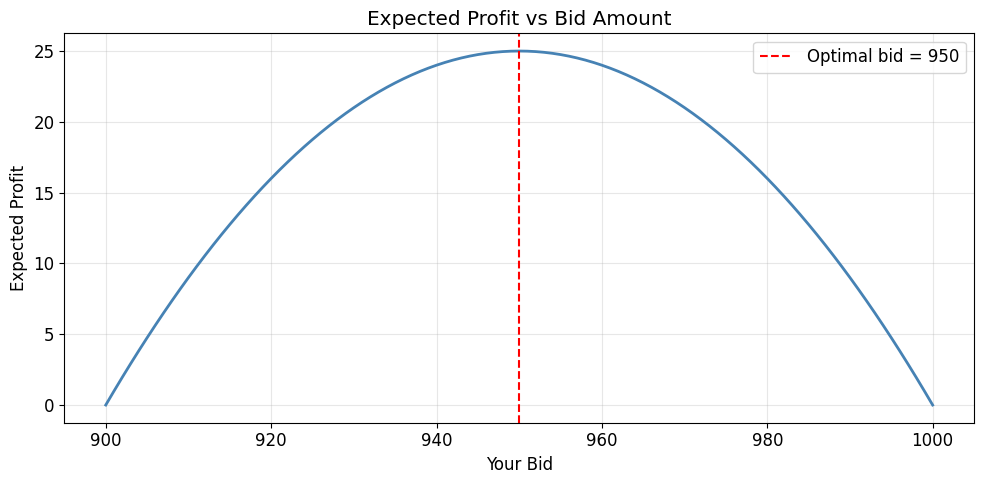

In [49]:
# ── Auction Optimizer: Grid Search + Analytical ────────────────

item_value = 1000
opponent_low = 900
opponent_high = 1000

# Grid search: try every possible bid
best_bid = 0
best_expected_profit = 0
bid_range = list(range(opponent_low, item_value + 1))
profits = []

for bid in bid_range:
    # Probability of winning
    win_probability = max(0, min(1, (bid - opponent_low) / (opponent_high - opponent_low)))
    # Profit if we win
    profit_if_win = item_value - bid
    # Expected profit
    expected_profit = win_probability * profit_if_win
    profits.append(expected_profit)

    if expected_profit > best_expected_profit:
        best_expected_profit = expected_profit
        best_bid = bid

# Analytical solution: bid at midpoint of (opponent_low, item_value)
analytical_optimal = (opponent_low + item_value) / 2

print(f"Grid search optimal bid: {best_bid}")
print(f"Grid search max E[profit]: {best_expected_profit:.2f}")
print(f"Analytical optimal bid: {analytical_optimal:.0f}")
print(f"They match!")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bid_range, profits, color="steelblue", linewidth=2)
ax.axvline(best_bid, color="red", linestyle="--", label=f"Optimal bid = {best_bid}")
ax.set_title("Expected Profit vs Bid Amount")
ax.set_xlabel("Your Bid")
ax.set_ylabel("Expected Profit")
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
# ── Kelly Criterion ────────────────────────────────────────────
# How much of your bankroll to bet on a positive-EV opportunity.
# Formula: f* = (p * b - q) / b
# where p = win probability, b = win/loss ratio, q = 1-p

def kelly_fraction(win_probability: float, win_loss_ratio: float) -> float:
    # Compute the Kelly optimal fraction of bankroll to bet.
    # Args: win_probability - chance of winning (0 to 1)
    #       win_loss_ratio - amount won / amount lost per bet
    # Returns: optimal fraction (can be negative = don't bet)

    loss_probability = 1.0 - win_probability
    kelly = (win_probability * win_loss_ratio - loss_probability) / win_loss_ratio
    return kelly

# Example: you find a trade with 55% win rate, 2:1 payoff
win_prob = 0.55
payoff_ratio = 2.0
optimal_fraction = kelly_fraction(win_prob, payoff_ratio)

print(f"Win probability: {win_prob:.0%}")
print(f"Win/loss ratio: {payoff_ratio:.1f}")
print(f"Kelly fraction: {optimal_fraction:.2%}")
print(f"\\nWith 10000 bankroll, bet {10000 * optimal_fraction:.0f}")
print(f"With half-Kelly (safer): bet {10000 * optimal_fraction / 2:.0f}")

# Show Kelly for various win probabilities
print(f"\\n{'Win%':>5} {'Kelly%':>8} {'Action':>20}")
print("-" * 35)
for wp in [0.40, 0.45, 0.50, 0.55, 0.60, 0.70, 0.80]:
    kf = kelly_fraction(wp, 2.0)
    action = "Don't bet" if kf <= 0 else f"Bet {kf:.1%} of bankroll"
    print(f"{wp:>5.0%} {kf:>8.1%} {action:>20}")

Win probability: 55%
Win/loss ratio: 2.0
Kelly fraction: 32.50%
\nWith 10000 bankroll, bet 3250
With half-Kelly (safer): bet 1625
\n Win%   Kelly%               Action
-----------------------------------
  40%    10.0% Bet 10.0% of bankroll
  45%    17.5% Bet 17.5% of bankroll
  50%    25.0% Bet 25.0% of bankroll
  55%    32.5% Bet 32.5% of bankroll
  60%    40.0% Bet 40.0% of bankroll
  70%    55.0% Bet 55.0% of bankroll
  80%    70.0% Bet 70.0% of bankroll


> **Common Mistake:** Kelly Criterion assumes you know the **exact** probabilities. In reality, your probability estimates are noisy. Using full Kelly with estimated probabilities leads to **ruin** (going broke). In practice, successful traders use **half-Kelly** or **quarter-Kelly** to account for estimation error. If Kelly says bet 20%, bet 5-10% instead.

### Part 2 Summary

| Concept | Pure Python (Submission) | NumPy (Analysis) | Competition Use |
|---------|--------------------------|-------------------|-----------------|
| Mean / Std / Z-score | `sum()/len()`, `math.sqrt()` | `np.mean()`, `np.std()` | Detect unusual prices |
| SMA | `deque(maxlen=N)` | `pd.rolling().mean()` | Fair value estimation |
| EMA | Single variable update | - | Fast-adapting fair value |
| Linear Regression | Least-squares formula | `np.polyfit()` | Trend detection, cross-year |
| Correlation | Pearson formula | `np.corrcoef()` | Find related products |
| Expected Value | `P * payoff` | - | Evaluate trade quality |
| Kelly Criterion | `(p*b - q) / b` | - | Position sizing |

In Part 3, we will apply these tools to build **seven trading strategies**: market making, pairs trading, basket arbitrage, cross-exchange arbitrage, options pricing, and counterparty identification.

## Part 3: Trading Strategies

This is the core of the competition. In this part you will build **seven strategies** used by top-placing teams:

| Strategy | Products | Key Idea |
|----------|----------|----------|
| **3.1 Stable Market Making** | RAINFOREST_RESIN | Fair value = 10000, earn the spread |
| **3.2 Volatile Market Making** | KELP, SQUID_INK | Estimate fair value with EMA/VWAP |
| **3.3 Pairs / Stat Arb** | CROISSANTS+JAMS | Trade spread z-score |
| **3.4 Basket Arbitrage** | PICNIC_BASKET1/2 | Basket vs component premium |
| **3.5 Cross-Exchange Arb** | MACARONS | Two markets, convert for profit |
| **3.6 Options / Black-Scholes** | VOLCANIC_ROCK vouchers | Implied volatility edge |
| **3.7 Counterparty Identification** | All products | Copy "Olivia" directional trades |

Every strategy is built **incrementally**: simple version first, then features added one at a time. Both submission-safe and analysis versions are provided.

### 3.1 Stable Market Making

**Market making** means quoting both a buy price and a sell price simultaneously. You profit from the **spread** - the gap between what you buy at and sell at. Think of a currency exchange booth at the airport: they buy at 1.05 and sell at 1.10. They profit 0.05 regardless of which direction the euro moves.

RAINFOREST_RESIN has a known **fair value of 10000 SeaShells** that never changes. This makes it the ideal product to learn market making: your only job is to buy below 10000 and sell above 10000.

#### The Order Book: A Manual Walkthrough

Before writing any code, let us think like a human trader looking at this order book:

| Buy Orders (Bids) | Sell Orders (Asks) |
|-------------------|---------------------|
| 10 units @ 9998   | 8 units @ 10002     |
| 25 units @ 9997   | 15 units @ 10003    |
| 5 units @ 9995    | 20 units @ 10005    |

- **Best bid = 9998**, best ask = 10002
- **Midpoint = 10000** (which happens to equal fair value here)
- **Spread = 4** (10002 - 9998)

As a market maker, you would:
1. **Buy** the 8 units at 10002 if they were below 10000? No, 10002 > 10000, skip.
2. **Quote passively**: offer to buy at 9999, sell at 10001 (just inside the spread)
3. If someone hits your quotes, you earn 2 SeaShells per unit traded

This is exactly what our `StableMarketMaker` class does.

#### Translating Human Intuition to Code, Step by Step

In [51]:
# ── Step 1: Just Read Best Bid/Ask ─────────────────────────────
# The simplest possible interaction with the order book.

def step1_read_order_book(order_depth) -> None:
    # Step 1: Read the best bid and ask prices from the order book.
    if order_depth.buy_orders:
        best_bid = max(order_depth.buy_orders.keys())
        best_bid_volume = order_depth.buy_orders[best_bid]
        print(f"Best bid: {best_bid} x {best_bid_volume} units")
    else:
        print("No bids in book")

    if order_depth.sell_orders:
        best_ask = min(order_depth.sell_orders.keys())
        best_ask_volume = abs(order_depth.sell_orders[best_ask])
        print(f"Best ask: {best_ask} x {best_ask_volume} units")
    else:
        print("No asks in book")

# Test with synthetic data
test_depth = OrderDepth(
    buy_orders={9998: 10, 9997: 25, 9995: 5},
    sell_orders={10002: -8, 10003: -15, 10005: -20}
)
step1_read_order_book(test_depth)

Best bid: 9998 x 10 units
Best ask: 10002 x 8 units


In [52]:
# ── Step 2: Compute Midpoint and Make a Decision ───────────────

def step2_simple_decision(order_depth, fair_value: float) -> list:
    # Step 2: If best ask < fair value, buy it.
    #         If best bid > fair value, sell it.

    orders = []

    # Check sell orders: buy any offer below fair value
    if order_depth.sell_orders:
        best_ask = min(order_depth.sell_orders.keys())
        if best_ask < fair_value:
            ask_volume = abs(order_depth.sell_orders[best_ask])
            orders.append(Order("RAINFOREST_RESIN", best_ask, ask_volume))
            print(f"BUY {ask_volume} @ {best_ask} (fair value = {fair_value})")

    # Check buy orders: sell any bid above fair value
    if order_depth.buy_orders:
        best_bid = max(order_depth.buy_orders.keys())
        if best_bid > fair_value:
            bid_volume = order_depth.buy_orders[best_bid]
            orders.append(Order("RAINFOREST_RESIN", best_bid, -bid_volume))
            print(f"SELL {bid_volume} @ {best_bid} (fair value = {fair_value})")

    return orders

# Test
fair_value = 10000
orders_2 = step2_simple_decision(test_depth, fair_value)
print(f"Orders generated: {len(orders_2)}")
print("(No orders - best ask is 10002 > 10000 and best bid is 9998 < 10000)")

Orders generated: 0
(No orders - best ask is 10002 > 10000 and best bid is 9998 < 10000)


In [53]:
# ── Step 3: Add Position Limit Checking ────────────────────────

def step3_with_position_limits(order_depth, fair_value: float,
                                current_position: int, limit: int) -> list:
    # Step 3: Never exceed position limits.
    # If we are at +50 (max long), we cannot buy more.
    # If we are at -50 (max short), we cannot sell more.

    orders = []

    if order_depth.sell_orders:
        best_ask = min(order_depth.sell_orders.keys())
        if best_ask < fair_value:
            ask_volume = abs(order_depth.sell_orders[best_ask])
            # Can only buy up to (limit - current_position) more units
            max_buyable = limit - current_position
            buy_quantity = min(ask_volume, max_buyable)
            if buy_quantity > 0:
                orders.append(Order("RAINFOREST_RESIN", best_ask, buy_quantity))
                print(f"BUY {buy_quantity} @ {best_ask} (pos: {current_position} -> {current_position + buy_quantity})")

    if order_depth.buy_orders:
        best_bid = max(order_depth.buy_orders.keys())
        if best_bid > fair_value:
            bid_volume = order_depth.buy_orders[best_bid]
            # Can only sell up to (limit + current_position) more units
            max_sellable = limit + current_position
            sell_quantity = min(bid_volume, max_sellable)
            if sell_quantity > 0:
                orders.append(Order("RAINFOREST_RESIN", best_bid, -sell_quantity))
                print(f"SELL {sell_quantity} @ {best_bid} (pos: {current_position} -> {current_position - sell_quantity})")

    return orders

# Test with a position near the limit
step3_with_position_limits(test_depth, 10000, current_position=45, limit=50)
print("(Can only buy 5 more units before hitting +50 limit)")

(Can only buy 5 more units before hitting +50 limit)


In [54]:
# ── Step 4: Add Wall Mid (Better Fair Value Estimate) ──────────
# Problem: the "best" bid/ask can be gamed by penny orders.
# Solution: use the DEEPEST (outermost) orders as fair value.

def compute_wall_mid(order_depth) -> float:
    # Wall Mid: midpoint between the deepest bid and deepest ask.
    # Frankfurt Hedgehogs (P3, 2nd place) used this for RAINFOREST_RESIN.
    # "Deepest" means the lowest bid price and highest ask price.
    # This is more robust to penny-order manipulation.

    if not order_depth.buy_orders or not order_depth.sell_orders:
        return 0.0

    bid_wall = min(order_depth.buy_orders.keys())   # deepest (lowest) bid
    ask_wall = max(order_depth.sell_orders.keys())  # deepest (highest) ask
    wall_mid = (bid_wall + ask_wall) / 2.0

    return wall_mid

# Compare wall mid vs simple mid
simple_bid = max(test_depth.buy_orders.keys())   # 9998 (best)
simple_ask = min(test_depth.sell_orders.keys())  # 10002 (best)
simple_mid = (simple_bid + simple_ask) / 2

wall_mid = compute_wall_mid(test_depth)

print(f"Simple mid (best bid/ask): {simple_mid}")
print(f"Wall mid (deepest bid/ask): {wall_mid}")

# Example where they differ: penny order placed at 10001
manipulated_depth = OrderDepth(
    buy_orders={9998: 10, 9997: 25, 9995: 5},
    sell_orders={10001: -1, 10003: -15, 10006: -20}  # penny at 10001
)
print("\\nWith a penny sell order at 10001 (volume=1):")
print(f"  Simple mid: {(max(manipulated_depth.buy_orders.keys()) + min(manipulated_depth.sell_orders.keys()))/2}")
print(f"  Wall mid: {compute_wall_mid(manipulated_depth)}")
print("Wall mid is unaffected by the penny order!")

Simple mid (best bid/ask): 10000.0
Wall mid (deepest bid/ask): 10000.0
\nWith a penny sell order at 10001 (volume=1):
  Simple mid: 9999.5
  Wall mid: 10000.5
Wall mid is unaffected by the penny order!


**Concrete penny example:** Imagine a trader places a sell order for 1 unit at 10001 (just to move the midpoint). With simple mid:
- Before penny: mid = (9998 + 10002) / 2 = **10000** ✓
- After penny: mid = (9998 + 10001) / 2 = **9999.5** (shifted by 0.5!)

With Wall Mid using the deepest orders (9995 bid, 10005 ask):
- Before penny: wall_mid = (9995 + 10005) / 2 = **10000** ✓
- After penny: wall_mid = (9995 + 10006) / 2 = **10000.5** (barely affected)

Wall Mid is **much more stable** and harder to manipulate.

In [55]:
# ── Step 5: Add Inventory Management (Skewed Quotes) ──────────
# If we hold too many units, skew our quotes to reduce position.
# Large long position: lower sell price to encourage selling
# Large short position: raise buy price to encourage buying

def step5_inventory_skew(order_depth, fair_value: float,
                          current_position: int, limit: int,
                          spread: int = 2) -> list:
    # Generate quotes with inventory-based skew.
    # Skew reduces inventory risk by incentivizing the other side.

    orders = []

    # Compute inventory skew: ranges from -spread to +spread
    # At max long (+50): skew = +spread (push ask price down to sell faster)
    # At max short (-50): skew = -spread (push bid price up to buy faster)
    inventory_fraction = current_position / limit  # -1 to +1
    inventory_skew = int(inventory_fraction * spread)

    # Passive quotes adjusted by skew
    passive_bid = int(fair_value) - spread + inventory_skew
    passive_ask = int(fair_value) + spread + inventory_skew

    remaining_buy = limit - current_position
    remaining_sell = limit + current_position

    if remaining_buy > 0:
        orders.append(Order("RAINFOREST_RESIN", passive_bid, remaining_buy))
    if remaining_sell > 0:
        orders.append(Order("RAINFOREST_RESIN", passive_ask, -remaining_sell))

    return orders

# Demo: how quotes shift with different positions
for position in [-50, -25, 0, 25, 50]:
    orders = step5_inventory_skew(test_depth, 10000, position, 50, spread=2)
    bid_prices = [o.price for o in orders if o.quantity > 0]
    ask_prices = [o.price for o in orders if o.quantity < 0]
    print(f"Position {position:>4}: bid={bid_prices}, ask={ask_prices}")

Position  -50: bid=[9996], ask=[]
Position  -25: bid=[9997], ask=[10001]
Position    0: bid=[9998], ask=[10002]
Position   25: bid=[9999], ask=[10003]
Position   50: bid=[], ask=[10004]


In [56]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Complete StableMarketMaker
# Combines all 5 steps: read book, decide, check limits,
# use Wall Mid, apply inventory skew.
# Three-phase execution: TAKE -> CLEAR -> MAKE
# ══════════════════════════════════════════════════════════════

class StableMarketMaker:
    # Market maker for stable products with known fair value.
    # Uses three-phase execution: TAKE (aggress mispriced), CLEAR (reduce inventory),
    # MAKE (place passive quotes). Pattern used by all top teams.

    def __init__(self, symbol: str = "RAINFOREST_RESIN",
                 fair_price: float = 10000.0,
                 position_limit: int = 50,
                 spread: int = 1):
        self.symbol = symbol
        self.fair_price = fair_price
        self.position_limit = position_limit
        self.spread = spread

    def run(self, state: TradingState) -> tuple:
        orders = []
        order_depth = state.order_depths.get(self.symbol, OrderDepth())
        current_position = state.position.get(self.symbol, 0)

        # Phase 1: TAKE - fill any orders that are mispriced vs fair value
        current_position = self._phase_take(order_depth, current_position, orders)

        # Phase 2: CLEAR - if we have a large position, reduce it at fair value
        self._phase_clear(order_depth, current_position, orders)

        # Phase 3: MAKE - place passive quotes at fair_price +/- spread
        self._phase_make(current_position, orders)

        result = {self.symbol: orders}
        return result, 0, ""

    def _phase_take(self, order_depth, position: int, orders: list) -> int:
        # Buy any asks below fair value
        for ask_price in sorted(order_depth.sell_orders.keys()):
            if ask_price < self.fair_price:
                ask_volume = abs(order_depth.sell_orders[ask_price])
                can_buy = self.position_limit - position
                buy_qty = min(ask_volume, can_buy)
                if buy_qty > 0:
                    orders.append(Order(self.symbol, ask_price, buy_qty))
                    position += buy_qty

        # Sell any bids above fair value
        for bid_price in sorted(order_depth.buy_orders.keys(), reverse=True):
            if bid_price > self.fair_price:
                bid_volume = order_depth.buy_orders[bid_price]
                can_sell = self.position_limit + position
                sell_qty = min(bid_volume, can_sell)
                if sell_qty > 0:
                    orders.append(Order(self.symbol, bid_price, -sell_qty))
                    position -= sell_qty

        return position

    def _phase_clear(self, order_depth, position: int, orders: list) -> None:
        # Reduce position by hitting existing orders at/near fair value
        fair_int = int(self.fair_price)

        if position > 0 and order_depth.buy_orders:
            # We are long - look for bids near fair value to sell into
            for bid_price in sorted(order_depth.buy_orders.keys(), reverse=True):
                if bid_price >= fair_int:
                    bid_volume = order_depth.buy_orders[bid_price]
                    sell_qty = min(bid_volume, position)
                    if sell_qty > 0:
                        orders.append(Order(self.symbol, bid_price, -sell_qty))
                        position -= sell_qty
                    if position <= 0:
                        break

        elif position < 0 and order_depth.sell_orders:
            # We are short - look for asks near fair value to buy
            for ask_price in sorted(order_depth.sell_orders.keys()):
                if ask_price <= fair_int:
                    ask_volume = abs(order_depth.sell_orders[ask_price])
                    buy_qty = min(ask_volume, -position)
                    if buy_qty > 0:
                        orders.append(Order(self.symbol, ask_price, buy_qty))
                        position += buy_qty
                    if position >= 0:
                        break

    def _phase_make(self, position: int, orders: list) -> None:
        # Place passive quotes: bid below fair, ask above fair
        remaining_buy = self.position_limit - position
        remaining_sell = self.position_limit + position
        bid_price = int(self.fair_price) - self.spread
        ask_price = int(self.fair_price) + self.spread

        if remaining_buy > 0:
            orders.append(Order(self.symbol, bid_price, remaining_buy))
        if remaining_sell > 0:
            orders.append(Order(self.symbol, ask_price, -remaining_sell))


# Quick test
smm = StableMarketMaker("RAINFOREST_RESIN", fair_price=10000, position_limit=50)
result, _, _ = smm.run(mock_state)
print(f"Orders from StableMarketMaker:")
for order in result.get("RAINFOREST_RESIN", []):
    side = "BUY" if order.quantity > 0 else "SELL"
    print(f"  {side} {abs(order.quantity)} @ {order.price}")

Orders from StableMarketMaker:
  BUY 35 @ 9999
  SELL 65 @ 10001


> **From the Winners:** Frankfurt Hedgehogs (Prosperity 3, 2nd place): *"Wall Mid is more reliable than simple midpoint because it ignores aggressive penny orders. We used Wall Mid for RAINFOREST_RESIN and saw significantly better PnL stability."*

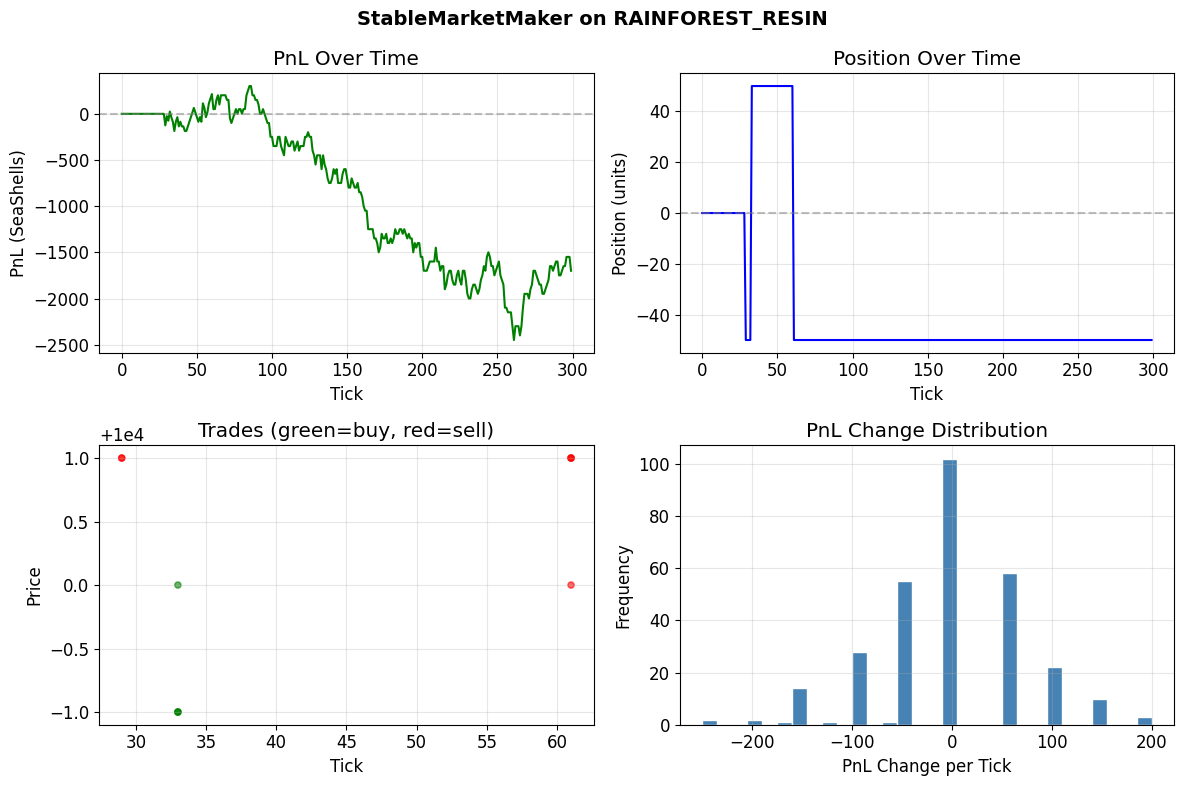

Final PnL: -1,699 SeaShells
Total trades: 10
Avg trade size: 25.0 units


In [57]:
# ── Backtest StableMarketMaker ──────────────────────────────────
# Generate data with occasional mispricing and test the strategy.

states_resin, prices_resin = generate_synthetic_states(
    symbol="RAINFOREST_RESIN",
    num_ticks=300,
    base_price=10000,
    volatility=1.5,   # small volatility (RESIN is stable)
    spread=4,
    position_limit=50,
)

smm_trader = StableMarketMaker(
    symbol="RAINFOREST_RESIN",
    fair_price=10000,
    position_limit=50,
    spread=1,
)

smm_results = backtest_trader(smm_trader, states_resin, {"RAINFOREST_RESIN": 50})
plot_backtest_results(smm_results, "StableMarketMaker on RAINFOREST_RESIN")

> **Intuition Check:** If you widen the spread (buy at 9998, sell at 10002 instead of 9999/10001), you make more per trade but get **fewer fills**. There is an optimal spread. Too narrow: you get filled but profits are tiny. Too wide: you never get filled. The right spread depends on the product's volatility and order flow.

In [58]:
# ── EXERCISE: Inventory-Aware Spread ───────────────────────────
# Extend StableMarketMaker to widen the spread when position is large.
# This discourages fills in the wrong direction when we are "stuck".

# YOUR TASK: implement StableMarketMakerV2 with this behavior:
# - When |position| < limit * 0.3: use normal spread (=1)
# - When |position| < limit * 0.6: use wider spread (=2)
# - When |position| >= limit * 0.6: use widest spread (=3)

print("Implement StableMarketMakerV2 with inventory-adaptive spread, then run the solution below.")

Implement StableMarketMakerV2 with inventory-adaptive spread, then run the solution below.


V1 (fixed spread=1)  PnL: -1,699
V2 (adaptive spread) PnL: -1,688


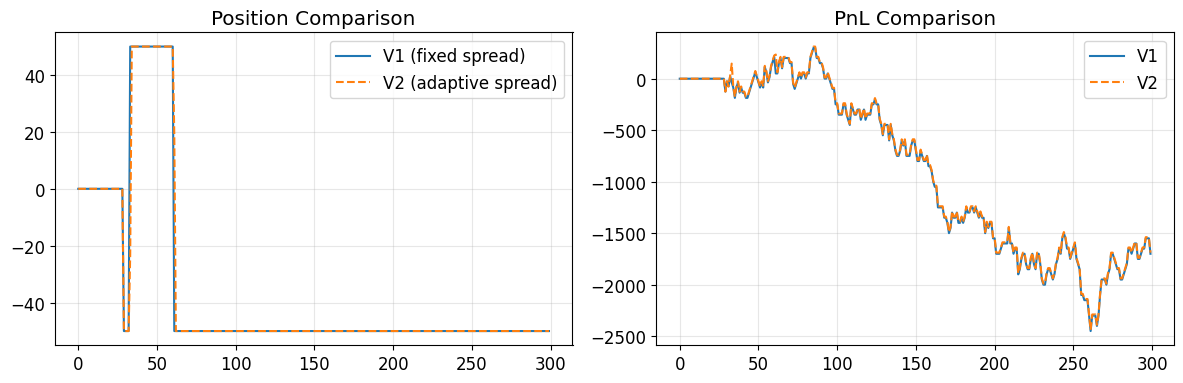

In [59]:
# ── SOLUTION ───────────────────────────────────────────────────

class StableMarketMakerV2(StableMarketMaker):
    # Extends StableMarketMaker with inventory-adaptive spread.

    def _compute_spread(self, position: int) -> int:
        # Widen spread when inventory is large to discourage one-sided fills.
        inventory_ratio = abs(position) / self.position_limit

        if inventory_ratio < 0.3:
            return 1   # narrow: low inventory, be aggressive
        elif inventory_ratio < 0.6:
            return 2   # medium: growing inventory
        else:
            return 3   # wide: large inventory, back off

    def _phase_make(self, position: int, orders: list) -> None:
        # Override with inventory-adaptive spread
        adaptive_spread = self._compute_spread(position)
        remaining_buy = self.position_limit - position
        remaining_sell = self.position_limit + position
        bid_price = int(self.fair_price) - adaptive_spread
        ask_price = int(self.fair_price) + adaptive_spread

        if remaining_buy > 0:
            orders.append(Order(self.symbol, bid_price, remaining_buy))
        if remaining_sell > 0:
            orders.append(Order(self.symbol, ask_price, -remaining_sell))

# Compare V1 vs V2
smm_v2 = StableMarketMakerV2("RAINFOREST_RESIN", fair_price=10000, position_limit=50)
v2_results = backtest_trader(smm_v2, states_resin, {"RAINFOREST_RESIN": 50})

print(f"V1 (fixed spread=1)  PnL: {smm_results['final_pnl']:,.0f}")
print(f"V2 (adaptive spread) PnL: {v2_results['final_pnl']:,.0f}")

# Plot position comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(smm_results["position_history"], label="V1 (fixed spread)")
axes[0].plot(v2_results["position_history"], label="V2 (adaptive spread)", linestyle="--")
axes[0].set_title("Position Comparison")
axes[0].legend()

axes[1].plot(smm_results["pnl_history"], label="V1")
axes[1].plot(v2_results["pnl_history"], label="V2", linestyle="--")
axes[1].set_title("PnL Comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

> **Common Mistake:** Not clearing your position! If you end up at +50 (max long), you **cannot buy anymore**. Your market-making edge disappears because you can only make one-sided quotes. You need zero-EV trades (sell at fair value) to free up capacity. This is the purpose of Phase 2 (CLEAR) in the three-phase pattern.

> **From the Winners:** Linear Utility (Prosperity 2, 2nd place) used three-phase execution on every product. Phase 1 TAKE aggressively fills mispriced orders. Phase 2 CLEAR reduces inventory by hitting existing orders near fair value. Phase 3 MAKE places passive quotes. This pattern was **independently discovered** by the top 3 teams in Prosperity 2.

### 3.2 Volatile Market Making

For products like KELP and SQUID_INK, the fair value **moves every tick**. You cannot use a fixed price - you must **estimate** fair value from the order book and recent trades.

Five common estimation methods, from simplest to most sophisticated:
1. **Simple midpoint**: (best_bid + best_ask) / 2
2. **VWAP**: volume-weighted average across all levels
3. **EMA**: exponential moving average of recent midpoints
4. **Micro-price**: imbalance-weighted mid (more weight to the larger side)
5. **Popular price**: most-traded price from recent market trades

In [60]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Five Fair Value Estimators
# ══════════════════════════════════════════════════════════════

def estimate_simple_mid(order_depth) -> float:
    # Midpoint of best bid and best ask.
    if not order_depth.buy_orders or not order_depth.sell_orders:
        return 0.0
    best_bid = max(order_depth.buy_orders.keys())
    best_ask = min(order_depth.sell_orders.keys())
    return (best_bid + best_ask) / 2.0


def estimate_vwap(order_depth) -> float:
    # Volume-Weighted Average Price across all book levels.
    # Gives more weight to price levels with more volume.
    total_value = 0.0
    total_volume = 0

    for price, volume in order_depth.buy_orders.items():
        total_value += price * volume
        total_volume += volume

    for price, volume in order_depth.sell_orders.items():
        total_value += price * abs(volume)
        total_volume += abs(volume)

    if total_volume == 0:
        return 0.0
    return total_value / total_volume


def estimate_micro_price(order_depth) -> float:
    # Micro-price: weighted mid where weights come from bid/ask imbalance.
    # If bids have 3x more volume than asks, price is closer to the ask.
    if not order_depth.buy_orders or not order_depth.sell_orders:
        return 0.0

    best_bid = max(order_depth.buy_orders.keys())
    best_ask = min(order_depth.sell_orders.keys())
    bid_volume = order_depth.buy_orders[best_bid]
    ask_volume = abs(order_depth.sell_orders[best_ask])

    total = bid_volume + ask_volume
    if total == 0:
        return (best_bid + best_ask) / 2.0

    # Weight toward whichever side has more volume
    micro_price = (best_bid * ask_volume + best_ask * bid_volume) / total
    return micro_price


def estimate_popular_price(market_trades: list) -> float:
    # Most-traded price from recent market trades.
    if not market_trades:
        return 0.0

    price_volumes = {}
    for trade in market_trades:
        price_volumes[trade.price] = price_volumes.get(trade.price, 0) + trade.quantity

    most_traded = max(price_volumes, key=price_volumes.get)
    return float(most_traded)


# Demo: compare all estimators on a test order book
demo_depth = OrderDepth(
    buy_orders={4999: 15, 4998: 30, 4995: 5},
    sell_orders={5001: -12, 5002: -25, 5005: -8}
)

print(f"Simple mid:  {estimate_simple_mid(demo_depth):.2f}")
print(f"VWAP:        {estimate_vwap(demo_depth):.2f}")
print(f"Micro-price: {estimate_micro_price(demo_depth):.2f}")
print("(popular price needs recent trades)")

Simple mid:  5000.00
VWAP:        5000.02
Micro-price: 5000.11
(popular price needs recent trades)


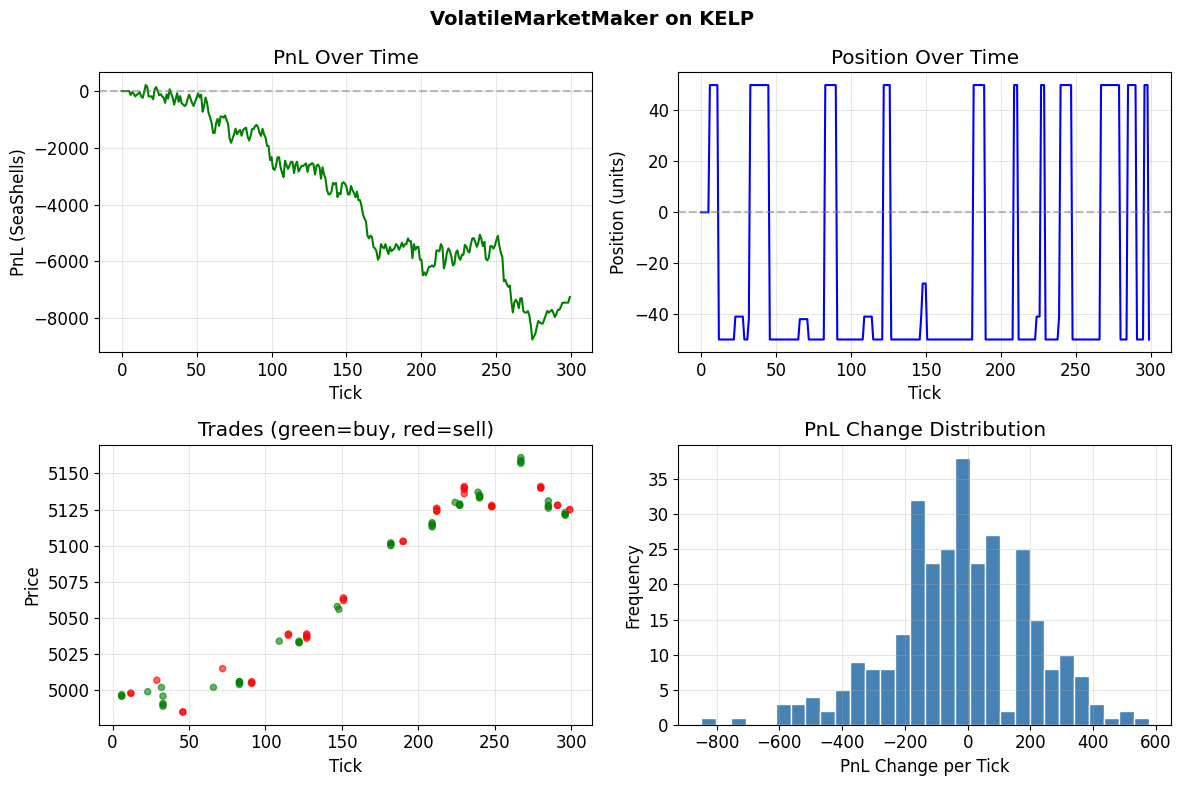

Final PnL: -7,254 SeaShells
Total trades: 87
Avg trade size: 25.8 units


In [61]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Volatile Market Maker (EMA-based)
# ══════════════════════════════════════════════════════════════

class VolatileMarketMaker:
    # Market maker for volatile products (KELP, SQUID_INK).
    # Uses EMA of midpoints to estimate fair value.

    def __init__(self, symbol: str, position_limit: int = 50,
                 ema_alpha: float = 0.3, spread: int = 2):
        self.symbol = symbol
        self.position_limit = position_limit
        self.ema_alpha = ema_alpha
        self.spread = spread
        self.ema_price = None        # persisted via traderData

    def run(self, state: TradingState) -> tuple:
        orders = []
        order_depth = state.order_depths.get(self.symbol, OrderDepth())
        current_position = state.position.get(self.symbol, 0)

        # Restore EMA from traderData
        if state.traderData:
            try:
                saved = json.loads(state.traderData)
                self.ema_price = saved.get(f"ema_{self.symbol}", None)
            except Exception:
                pass

        # Compute new fair value estimate
        fair_value = self._estimate_fair_value(order_depth, state)

        # Three-phase execution using estimated fair value
        if fair_value is not None and fair_value > 0:
            # Phase 1: TAKE
            current_position = self._phase_take(order_depth, current_position,
                                                fair_value, orders)
            # Phase 3: MAKE
            self._phase_make(current_position, fair_value, orders)

        result = {self.symbol: orders}
        # Save EMA for next tick
        trader_data = json.dumps({f"ema_{self.symbol}": self.ema_price})
        return result, 0, trader_data

    def _estimate_fair_value(self, order_depth, state) -> float:
        # Update EMA with current midpoint
        if not order_depth.buy_orders or not order_depth.sell_orders:
            return self.ema_price

        current_mid = estimate_simple_mid(order_depth)

        if self.ema_price is None:
            self.ema_price = current_mid
        else:
            self.ema_price = (self.ema_alpha * current_mid
                              + (1 - self.ema_alpha) * self.ema_price)

        return self.ema_price

    def _phase_take(self, order_depth, position: int,
                    fair_value: float, orders: list) -> int:
        # Aggress on orders that are mispriced vs fair value
        for ask_price in sorted(order_depth.sell_orders.keys()):
            if ask_price < fair_value - 1:   # need margin, not just below
                ask_vol = abs(order_depth.sell_orders[ask_price])
                can_buy = self.position_limit - position
                buy_qty = min(ask_vol, can_buy)
                if buy_qty > 0:
                    orders.append(Order(self.symbol, ask_price, buy_qty))
                    position += buy_qty

        for bid_price in sorted(order_depth.buy_orders.keys(), reverse=True):
            if bid_price > fair_value + 1:
                bid_vol = order_depth.buy_orders[bid_price]
                can_sell = self.position_limit + position
                sell_qty = min(bid_vol, can_sell)
                if sell_qty > 0:
                    orders.append(Order(self.symbol, bid_price, -sell_qty))
                    position -= sell_qty

        return position

    def _phase_make(self, position: int, fair_value: float, orders: list) -> None:
        # Place passive quotes around estimated fair value
        remaining_buy = self.position_limit - position
        remaining_sell = self.position_limit + position
        bid_price = int(fair_value) - self.spread
        ask_price = int(fair_value) + self.spread

        if remaining_buy > 0:
            orders.append(Order(self.symbol, bid_price, remaining_buy))
        if remaining_sell > 0:
            orders.append(Order(self.symbol, ask_price, -remaining_sell))


# Test
states_kelp, prices_kelp = generate_synthetic_states(
    symbol="KELP", num_ticks=300, base_price=5000, volatility=5.0,
    spread=4, position_limit=50
)

vmm = VolatileMarketMaker("KELP", position_limit=50, ema_alpha=0.3, spread=2)
vmm_results = backtest_trader(vmm, states_kelp, {"KELP": 50})
plot_backtest_results(vmm_results, "VolatileMarketMaker on KELP")

> **From the Winners:** chrispyroberts (Prosperity 3, 7th place): *"Market maker mid (the midpoint of best bid and best ask) was better than any model-based fair value for volatile products. Complex models overfitted to noise. Keep it simple."*

In [62]:
# ── EXERCISE + SOLUTION: Compare Estimators ────────────────────
# Backtest VolatileMarketMaker with different fair value methods.
# Which estimator gives the best PnL?

class VolatileMarketMakerVWAP(VolatileMarketMaker):
    # Uses VWAP instead of EMA for fair value estimation.

    def _estimate_fair_value(self, order_depth, state) -> float:
        vwap = estimate_vwap(order_depth)
        if vwap > 0:
            if self.ema_price is None:
                self.ema_price = vwap
            else:
                # Smooth the VWAP with EMA to reduce noise
                self.ema_price = (self.ema_alpha * vwap
                                  + (1 - self.ema_alpha) * self.ema_price)
        return self.ema_price


class VolatileMarketMakerMicro(VolatileMarketMaker):
    # Uses micro-price for fair value estimation.

    def _estimate_fair_value(self, order_depth, state) -> float:
        micro = estimate_micro_price(order_depth)
        if micro > 0:
            if self.ema_price is None:
                self.ema_price = micro
            else:
                self.ema_price = (self.ema_alpha * micro
                                  + (1 - self.ema_alpha) * self.ema_price)
        return self.ema_price


# Backtest all three
ema_trader = VolatileMarketMaker("KELP", position_limit=50)
vwap_trader = VolatileMarketMakerVWAP("KELP", position_limit=50)
micro_trader = VolatileMarketMakerMicro("KELP", position_limit=50)

results_ema = backtest_trader(ema_trader, states_kelp, {"KELP": 50})
results_vwap = backtest_trader(vwap_trader, states_kelp, {"KELP": 50})
results_micro = backtest_trader(micro_trader, states_kelp, {"KELP": 50})

print(f"EMA fair value  PnL: {results_ema['final_pnl']:,.0f}")
print(f"VWAP fair value PnL: {results_vwap['final_pnl']:,.0f}")
print(f"Micro-price     PnL: {results_micro['final_pnl']:,.0f}")

EMA fair value  PnL: -7,254
VWAP fair value PnL: -7,254
Micro-price     PnL: -7,028


### 3.3 Pairs / Statistical Arbitrage

When two products are **cointegrated**, their spread mean-reverts. You profit by:
- **Buying the spread** when it is unusually low (buy cheap product, sell expensive)
- **Selling the spread** when it is unusually high (sell expensive product, buy cheap)

Think of it as a **rubber band** connecting two products. When stretched too far in one direction, it snaps back. Your job is to bet on the snap.

In [63]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Pairs Trader
# Trades the spread between two cointegrated products.
# ══════════════════════════════════════════════════════════════

class PairsTrader:
    # Trades the spread between two cointegrated products.
    # Buys the spread when z-score is below -z_threshold (spread unusually low).
    # Sells the spread when z-score is above +z_threshold (spread unusually high).

    def __init__(self, symbol_a: str, symbol_b: str,
                 beta: float = 1.0,
                 z_threshold: float = 2.0,
                 window_size: int = 30,
                 position_limit: int = 50):
        self.symbol_a = symbol_a
        self.symbol_b = symbol_b
        self.beta = beta                    # hedge ratio: spread = A - beta * B
        self.z_threshold = z_threshold
        self.window_size = window_size
        self.position_limit = position_limit
        self.spread_history = deque(maxlen=window_size)

    def run(self, state: TradingState) -> tuple:
        orders_a = []
        orders_b = []

        # Restore spread history from traderData
        if state.traderData:
            try:
                saved = json.loads(state.traderData)
                self.spread_history = deque(
                    saved.get("spread_hist", []),
                    maxlen=self.window_size
                )
            except Exception:
                pass

        # Get midpoints of both products
        depth_a = state.order_depths.get(self.symbol_a, OrderDepth())
        depth_b = state.order_depths.get(self.symbol_b, OrderDepth())

        if not depth_a.buy_orders or not depth_b.buy_orders:
            return {}, 0, ""

        mid_a = estimate_simple_mid(depth_a)
        mid_b = estimate_simple_mid(depth_b)

        # Compute current spread
        current_spread = mid_a - self.beta * mid_b
        self.spread_history.append(current_spread)

        # Need enough history to compute z-score
        if len(self.spread_history) < self.window_size // 2:
            trader_data = json.dumps({"spread_hist": list(self.spread_history)})
            return {}, 0, trader_data

        spread_list = list(self.spread_history)
        spread_mean = sum(spread_list) / len(spread_list)
        spread_std_val = math.sqrt(
            sum((s - spread_mean) ** 2 for s in spread_list) / len(spread_list)
        )

        if spread_std_val == 0:
            trader_data = json.dumps({"spread_hist": list(self.spread_history)})
            return {}, 0, trader_data

        z_score = (current_spread - spread_mean) / spread_std_val

        position_a = state.position.get(self.symbol_a, 0)
        position_b = state.position.get(self.symbol_b, 0)

        # Trade signals based on z-score
        if z_score > self.z_threshold:
            # Spread is too HIGH: sell A (overpriced), buy B (underpriced)
            trade_size = min(10, self.position_limit + position_a,
                             self.position_limit - position_b)
            if trade_size > 0:
                orders_a.append(Order(self.symbol_a,
                                      int(mid_a), -trade_size))
                orders_b.append(Order(self.symbol_b,
                                      int(mid_b), int(trade_size * self.beta)))

        elif z_score < -self.z_threshold:
            # Spread is too LOW: buy A (underpriced), sell B (overpriced)
            trade_size = min(10, self.position_limit - position_a,
                             self.position_limit + position_b)
            if trade_size > 0:
                orders_a.append(Order(self.symbol_a,
                                      int(mid_a), trade_size))
                orders_b.append(Order(self.symbol_b,
                                      int(mid_b), -int(trade_size * self.beta)))

        result = {}
        if orders_a:
            result[self.symbol_a] = orders_a
        if orders_b:
            result[self.symbol_b] = orders_b

        trader_data = json.dumps({"spread_hist": list(self.spread_history)})
        return result, 0, trader_data


print("PairsTrader class defined.")
print("Use it when two products are cointegrated (spread mean-reverts).")

PairsTrader class defined.
Use it when two products are cointegrated (spread mean-reverts).


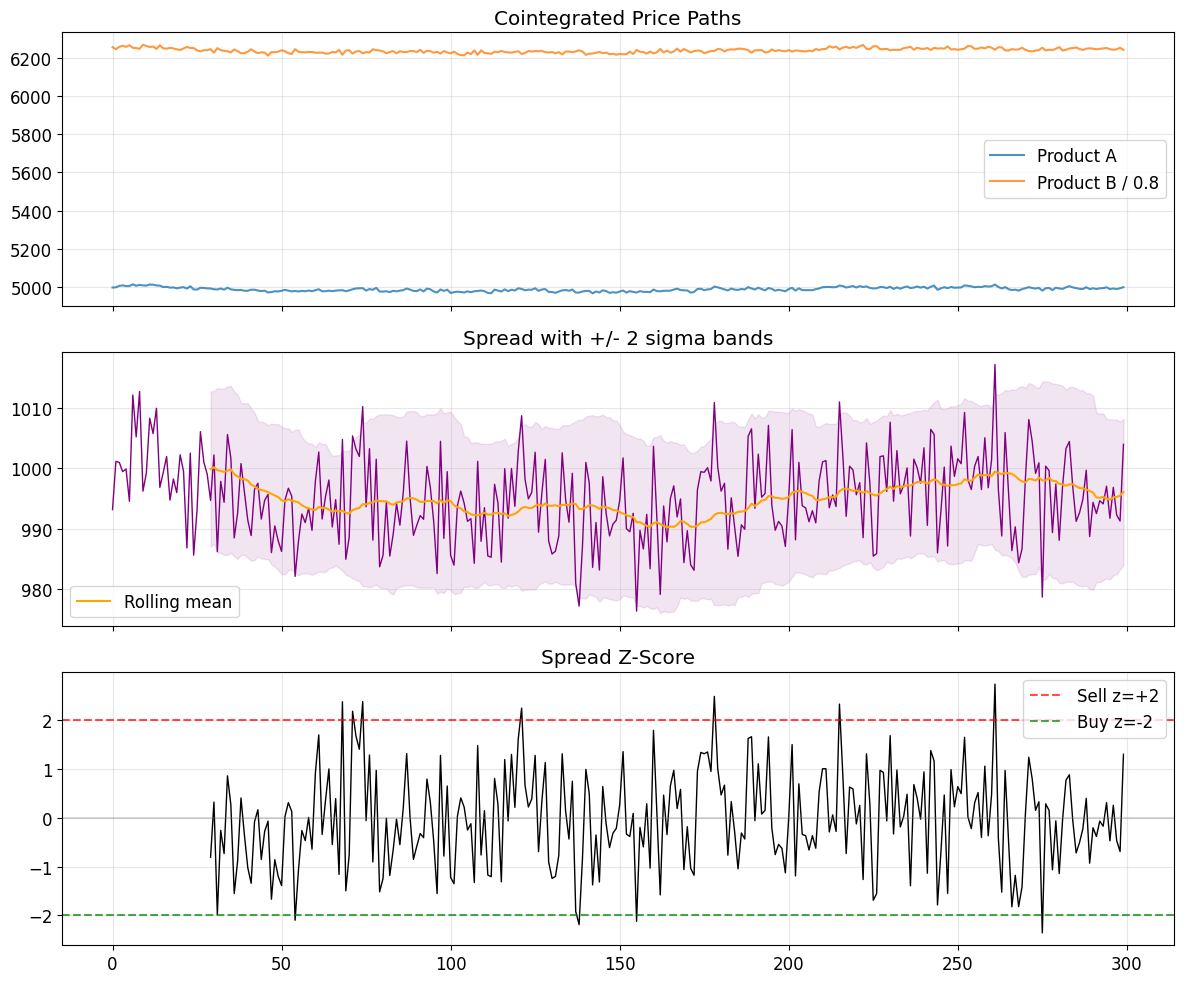

In [64]:
# ── Visualize Spread Z-Score Strategy ──────────────────────────
np.random.seed(42)
n_points = 300

# Generate cointegrated pair
common = np.cumsum(np.random.normal(0, 2, n_points)) + 5000
series_a_prices = common + np.random.normal(0, 5, n_points)
series_b_prices = 0.8 * common + np.random.normal(0, 5, n_points) + 1000

# Compute spread and z-score with rolling window
window_len = 30
spread_series = series_a_prices - 0.8 * series_b_prices

# Rolling mean and std
rolling_mean = pd.Series(spread_series).rolling(window_len).mean()
rolling_std = pd.Series(spread_series).rolling(window_len).std()
zscore_series = (spread_series - rolling_mean) / rolling_std

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(series_a_prices, label="Product A", alpha=0.8)
axes[0].plot(series_b_prices / 0.8, label="Product B / 0.8", alpha=0.8)
axes[0].set_title("Cointegrated Price Paths")
axes[0].legend()

axes[1].plot(spread_series, color="purple", linewidth=1)
axes[1].plot(rolling_mean, color="orange", linewidth=1.5, label="Rolling mean")
axes[1].fill_between(range(n_points),
                     rolling_mean - 2*rolling_std,
                     rolling_mean + 2*rolling_std,
                     alpha=0.1, color="purple")
axes[1].set_title("Spread with +/- 2 sigma bands")
axes[1].legend()

axes[2].plot(zscore_series, color="black", linewidth=1)
axes[2].axhline(2, color="red", linestyle="--", alpha=0.7, label="Sell z=+2")
axes[2].axhline(-2, color="green", linestyle="--", alpha=0.7, label="Buy z=-2")
axes[2].axhline(0, color="gray", linestyle="-", alpha=0.3)
axes[2].set_title("Spread Z-Score")
axes[2].legend()

plt.tight_layout()
plt.show()

> **From the Winners:** Linear Utility (Prosperity 2, 2nd place) used z-score thresholds from 2 to **11** depending on the product. For PICNIC_BASKET, the spread was around 370 SeaShells with a z-score threshold of 11. When the basket deviated by 11 standard deviations, they traded aggressively with maximum size.

> **Common Mistake:** Assuming correlation = cointegration! Two stocks both trending upward are highly correlated, but their spread keeps growing and never reverts. You would lose money betting on mean-reversion. Always verify that the **spread itself is stationary** (fluctuates around a constant mean) before trading it.

### 3.4 Basket Arbitrage

PICNIC_BASKET is like an ETF: it is worth exactly the sum of its components. If the basket trades at a premium, you can sell the basket and buy the components. If it trades at a discount, buy the basket and sell the components.

**Prosperity 3 basket compositions:**
- `PICNIC_BASKET1` = 6 × CROISSANTS + 3 × JAMS + 1 × DJEMBES
- `PICNIC_BASKET2` = 4 × CROISSANTS + 2 × JAMS

The **premium** (basket price minus component value) fluctuates and mean-reverts. This is a classic arbitrage opportunity.

In [65]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Basket Arbitrage Trader
# Trades the basket vs its component composition.
# ══════════════════════════════════════════════════════════════

# Basket compositions (Prosperity 3)
BASKET1_COMPOSITION = {"CROISSANTS": 6, "JAMS": 3, "DJEMBES": 1}
BASKET2_COMPOSITION = {"CROISSANTS": 4, "JAMS": 2}

def compute_basket_premium(basket_depth: OrderDepth,
                            component_depths: dict,
                            composition: dict) -> float:
    # Compute how much the basket trades above/below its component value.
    # Returns: basket_mid - component_value_mid

    if not basket_depth.buy_orders or not basket_depth.sell_orders:
        return 0.0

    basket_mid = estimate_simple_mid(basket_depth)

    # Compute theoretical component value
    component_value = 0.0
    for component_name, quantity in composition.items():
        comp_depth = component_depths.get(component_name, OrderDepth())
        if not comp_depth.buy_orders or not comp_depth.sell_orders:
            return 0.0
        comp_mid = estimate_simple_mid(comp_depth)
        component_value += quantity * comp_mid

    premium = basket_mid - component_value
    return premium


class BasketTrader:
    # Trades basket vs components when premium is extreme.

    def __init__(self, basket_symbol: str = "PICNIC_BASKET1",
                 composition: dict = None,
                 premium_threshold: float = 100.0,
                 position_limit: int = 60,
                 window_size: int = 50):
        self.basket_symbol = basket_symbol
        self.composition = composition or BASKET1_COMPOSITION
        self.premium_threshold = premium_threshold
        self.position_limit = position_limit
        self.window_size = window_size
        self.premium_history = deque(maxlen=window_size)

    def run(self, state: TradingState) -> tuple:
        result = {}

        basket_depth = state.order_depths.get(self.basket_symbol, OrderDepth())

        # Get component order books
        component_depths = {
            sym: state.order_depths.get(sym, OrderDepth())
            for sym in self.composition
        }

        # Compute current premium
        premium = compute_basket_premium(basket_depth, component_depths, self.composition)
        if premium != 0.0:
            self.premium_history.append(premium)

        if len(self.premium_history) < 10:
            return result, 0, ""

        # Compute z-score of premium
        premium_list = list(self.premium_history)
        p_mean = sum(premium_list) / len(premium_list)
        p_std = math.sqrt(
            sum((p - p_mean) ** 2 for p in premium_list) / len(premium_list)
        )
        if p_std == 0:
            return result, 0, ""

        z_score = (premium - p_mean) / p_std
        basket_position = state.position.get(self.basket_symbol, 0)

        if z_score > 2.0:
            # Basket expensive: SELL basket
            can_sell = self.position_limit + basket_position
            if can_sell > 0:
                basket_ask = min(basket_depth.buy_orders.keys()) if basket_depth.buy_orders else None
                if basket_ask:
                    result[self.basket_symbol] = [
                        Order(self.basket_symbol, basket_ask, -min(5, can_sell))
                    ]
        elif z_score < -2.0:
            # Basket cheap: BUY basket
            can_buy = self.position_limit - basket_position
            if can_buy > 0:
                basket_bid = max(basket_depth.sell_orders.keys()) if basket_depth.sell_orders else None
                if basket_bid:
                    result[self.basket_symbol] = [
                        Order(self.basket_symbol, basket_bid, min(5, can_buy))
                    ]

        return result, 0, ""


print("BasketTrader defined.")
print(f"PICNIC_BASKET1 = {BASKET1_COMPOSITION}")
print(f"PICNIC_BASKET2 = {BASKET2_COMPOSITION}")

BasketTrader defined.
PICNIC_BASKET1 = {'CROISSANTS': 6, 'JAMS': 3, 'DJEMBES': 1}
PICNIC_BASKET2 = {'CROISSANTS': 4, 'JAMS': 2}


> **From the Winners:** Frankfurt Hedgehogs (Prosperity 3, 2nd place) used a 50% constituent hedge - they only hedged half the component exposure to reduce transaction costs. They also adjusted basket positions based on Olivia's direction signal: when Olivia was buying, they held larger long positions in the basket.

> **Common Mistake:** Hedging costs can exceed arbitrage profits! Trading the components (CROISSANTS, JAMS, DJEMBES) has its own spread cost multiplied by position size. Sometimes the basket premium is smaller than the combined hedging costs, making the trade negative EV. Always compute net expected profit after all transaction costs.

### 3.5 Cross-Exchange Arbitrage

MAGNIFICENT_MACARONS trade on two markets simultaneously: your exchange and an external exchange. You can **convert** between them (move product from one exchange to the other) for a fee. The fee has two components:

- **Transport fees** (flat fee per conversion)
- **Import/Export tariffs** (percentage of value)

If the price difference exceeds the total fee, you profit from arbitrage.

In [66]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Cross-Exchange Arbitrage
# Converts MACARONS when price difference > conversion cost.
# ══════════════════════════════════════════════════════════════

def compute_conversion_cost(obs: ConversionObservation,
                             direction: str = "import") -> float:
    # Compute total cost to convert MACARONS across exchanges.
    # direction = "import" (buy external, sell internal)
    #           = "export" (buy internal, sell external)

    if direction == "import":
        # Cost: buy at external ask + transport + import tariff
        external_cost = obs.askPrice
        conversion_fee = obs.transportFees + obs.importTariff
    else:
        # Revenue: sell at external bid - transport - export tariff
        external_cost = obs.bidPrice
        conversion_fee = obs.transportFees + obs.exportTariff

    return external_cost + conversion_fee if direction == "import" else external_cost - conversion_fee


class ConversionTrader:
    # Trades MACARONS cross-exchange when arbitrage profit exceeds fees.

    def __init__(self, symbol: str = "MAGNIFICENT_MACARONS",
                 min_profit_threshold: float = 2.0,
                 position_limit: int = 75):
        self.symbol = symbol
        self.min_profit = min_profit_threshold
        self.position_limit = position_limit

    def run(self, state: TradingState) -> tuple:
        orders = []
        conversions = 0

        order_depth = state.order_depths.get(self.symbol, OrderDepth())
        observations = state.observations

        # Check if we have external market data
        if not hasattr(observations, 'conversionObservations'):
            return {self.symbol: orders}, conversions, ""
        if self.symbol not in observations.conversionObservations:
            return {self.symbol: orders}, conversions, ""

        external_obs = observations.conversionObservations[self.symbol]
        current_position = state.position.get(self.symbol, 0)

        # Compute effective import cost (external -> internal)
        import_cost = compute_conversion_cost(external_obs, "import")

        # If our internal best bid > import cost, buy externally and sell internally
        if order_depth.buy_orders:
            best_internal_bid = max(order_depth.buy_orders.keys())
            arbitrage_profit = best_internal_bid - import_cost

            if arbitrage_profit > self.min_profit:
                # Convert: buy from external market (use conversions)
                bid_volume = order_depth.buy_orders[best_internal_bid]
                convert_qty = min(bid_volume, self.position_limit - current_position)
                if convert_qty > 0:
                    conversions += convert_qty
                    orders.append(Order(self.symbol, best_internal_bid, -convert_qty))

        return {self.symbol: orders}, conversions, ""


print("ConversionTrader defined.")
print("External bid/ask come from state.observations.conversionObservations")

ConversionTrader defined.
External bid/ask come from state.observations.conversionObservations


> **From the Winners:** Frankfurt Hedgehogs found a "taker bot" on the external exchange that fills orders at `int(externalBid + 0.5)` with approximately 60% probability. They exploited this predictable behavior by placing orders at exactly that price, effectively getting guaranteed fills at a slight premium.

> **Common Mistake:** Sunlight and humidity data for MACARONS were red herrings for most teams. They looked like useful predictive features but had no statistically significant relationship to price. Several teams wasted time building models around these features. Always validate feature predictive power with out-of-sample testing before building a strategy around it.

### 3.6 Options Pricing: Black-Scholes

A **call option** gives you the RIGHT (not obligation) to BUY a product at a fixed price (the **strike**) at a future date. Think of a concert ticket: you pay $20 now for the right to attend a concert worth $100. If the concert happens, great - you profit $80. If it is cancelled, you lose only your $20.

In Prosperity, VOLCANIC_ROCK is the underlying product. VOLCANIC_ROCK_VOUCHERS are call options on it. You profit by identifying when the market is pricing options **too cheap or too expensive** relative to the theoretical Black-Scholes value.

#### The Black-Scholes Formula: Step by Step

Given:
- **S = 10000** (current stock price)
- **K = 10000** (strike price - what you can buy at)
- **T = 0.02** (time to expiry in years, e.g., ~5 trading days)
- **sigma = 0.16** (volatility - annualized standard deviation)
- **r = 0** (risk-free interest rate, negligible in game)

**Step 1:** Compute d1 and d2:
```
d1 = (ln(S/K) + (r + sigma²/2) * T) / (sigma * sqrt(T))
   = (ln(1) + (0 + 0.0128) * 0.02) / (0.16 * 0.1414)
   = (0 + 0.000256) / 0.02263
   = 0.0113

d2 = d1 - sigma * sqrt(T) = 0.0113 - 0.02263 = -0.0113
```

**Step 2:** Look up N(d1) and N(d2) in the standard normal table:
- N(0.0113) ≈ 0.5045
- N(-0.0113) ≈ 0.4955

**Step 3:** Compute the call price:
```
Call = S * N(d1) - K * e^(-rT) * N(d2)
     = 10000 * 0.5045 - 10000 * 1 * 0.4955
     = 5045 - 4955
     = 90 SeaShells
```

An at-the-money option with 1% time remaining and 16% annual volatility costs about 90 SeaShells.

In [67]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Normal CDF (Abramowitz-Stegun Approximation)
# Used by ALL top teams in Prosperity 3.
# Approximates scipy.stats.norm.cdf() to 7 decimal places.
# NO scipy needed - runs on the competition server.
# ══════════════════════════════════════════════════════════════

def norm_cdf(x: float) -> float:
    # Approximate the standard normal CDF using Abramowitz-Stegun method.
    # These exact coefficients were used by Alpha Animals (9th), Frankfurt Hedgehogs (2nd),
    # and virtually every other top team in Prosperity 3.

    # Abramowitz-Stegun coefficients (Handbook of Mathematical Functions, 1964)
    a1 = 0.254829592
    a2 = -0.284496736
    a3 = 1.421413741
    a4 = -1.453152027
    a5 = 1.061405429
    p = 0.3275911

    # Handle negative values using symmetry: N(-x) = 1 - N(x)
    sign = 1 if x >= 0 else -1
    x_abs = abs(x) / math.sqrt(2.0)

    # Horner's method: evaluate polynomial efficiently
    t = 1.0 / (1.0 + p * x_abs)
    polynomial = (((((a5 * t + a4) * t) + a3) * t + a2) * t + a1) * t
    y = 1.0 - polynomial * math.exp(-x_abs * x_abs)

    return 0.5 * (1.0 + sign * y)


def norm_pdf(x: float) -> float:
    # Standard normal probability density function.
    # Used for computing option Greeks (especially Vega).
    coefficient = 1.0 / math.sqrt(2.0 * math.pi)
    return coefficient * math.exp(-0.5 * x * x)


# Verify accuracy against scipy
from scipy.stats import norm as scipy_norm

test_values = [-3.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 3.0]
print(f"{'x':>6} {'Our norm_cdf':>14} {'scipy.norm.cdf':>15} {'Error':>12}")
print("-" * 50)
for x_val in test_values:
    our_result = norm_cdf(x_val)
    scipy_result = scipy_norm.cdf(x_val)
    error = abs(our_result - scipy_result)
    print(f"{x_val:>6.1f} {our_result:>14.8f} {scipy_result:>15.8f} {error:>12.2e}")

print("\\nMaximum error is less than 1e-7. Acceptable for competition use.")

     x   Our norm_cdf  scipy.norm.cdf        Error
--------------------------------------------------
  -3.0     0.00134997      0.00134990     6.92e-08
  -2.0     0.02275006      0.02275013     6.91e-08
  -1.0     0.15865526      0.15865525     9.90e-09
  -0.5     0.30853754      0.30853754     1.45e-09
   0.0     0.50000000      0.50000000     5.00e-10
   0.5     0.69146246      0.69146246     1.45e-09
   1.0     0.84134474      0.84134475     9.90e-09
   2.0     0.97724994      0.97724987     6.91e-08
   3.0     0.99865003      0.99865010     6.92e-08
\nMaximum error is less than 1e-7. Acceptable for competition use.


> **Why we need our own `norm_cdf`:** The competition server runs Python with only the standard library. `scipy` (which has `scipy.stats.norm.cdf`) is NOT available. We must implement it ourselves. The Abramowitz-Stegun approximation is the standard solution - it is accurate to 7 decimal places and fast to compute.

In [68]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Black-Scholes Option Pricing
# ══════════════════════════════════════════════════════════════

def black_scholes_call(spot_price: float, strike_price: float,
                       time_to_expiry: float, volatility: float,
                       risk_free_rate: float = 0.0) -> float:
    # Black-Scholes call option price.
    # Args: spot_price - current underlying price (S)
    #       strike_price - option exercise price (K)
    #       time_to_expiry - years until expiry (T)
    #       volatility - annualized standard deviation (sigma)
    #       risk_free_rate - continuously compounded rate (r)
    # Returns: fair call price in SeaShells

    if time_to_expiry <= 0 or volatility <= 0 or spot_price <= 0:
        return max(0.0, spot_price - strike_price)  # intrinsic value only

    # Step 1: compute d1 and d2
    log_moneyness = math.log(spot_price / strike_price)
    variance_time = 0.5 * volatility * volatility * time_to_expiry
    sqrt_time = math.sqrt(time_to_expiry)

    d1 = (log_moneyness + (risk_free_rate + variance_time)) / (volatility * sqrt_time)
    d2 = d1 - volatility * sqrt_time

    # Step 2: discount factor
    discount = math.exp(-risk_free_rate * time_to_expiry)

    # Step 3: Black-Scholes formula
    call_price = spot_price * norm_cdf(d1) - strike_price * discount * norm_cdf(d2)
    return call_price


# Demo: compute call prices for various scenarios
print(f"{'S':>6} {'K':>6} {'T':>6} {'sigma':>7} {'BS Call':>10}")
print("-" * 40)
for scenario in [
    (10000, 10000, 0.02, 0.16),   # at-the-money
    (10100, 10000, 0.02, 0.16),   # in-the-money
    (9900, 10000, 0.02, 0.16),    # out-of-the-money
    (10000, 10000, 0.01, 0.16),   # less time
    (10000, 10000, 0.02, 0.30),   # higher vol
]:
    s, k, t, sig = scenario
    price = black_scholes_call(s, k, t, sig)
    print(f"{s:>6} {k:>6} {t:>6.3f} {sig:>7.2f} {price:>10.2f}")

     S      K      T   sigma    BS Call
----------------------------------------
 10000  10000  0.020    0.16      90.27
 10100  10000  0.020    0.16     149.35
  9900  10000  0.020    0.16      48.53
 10000  10000  0.010    0.16      63.83
 10000  10000  0.020    0.30     169.25


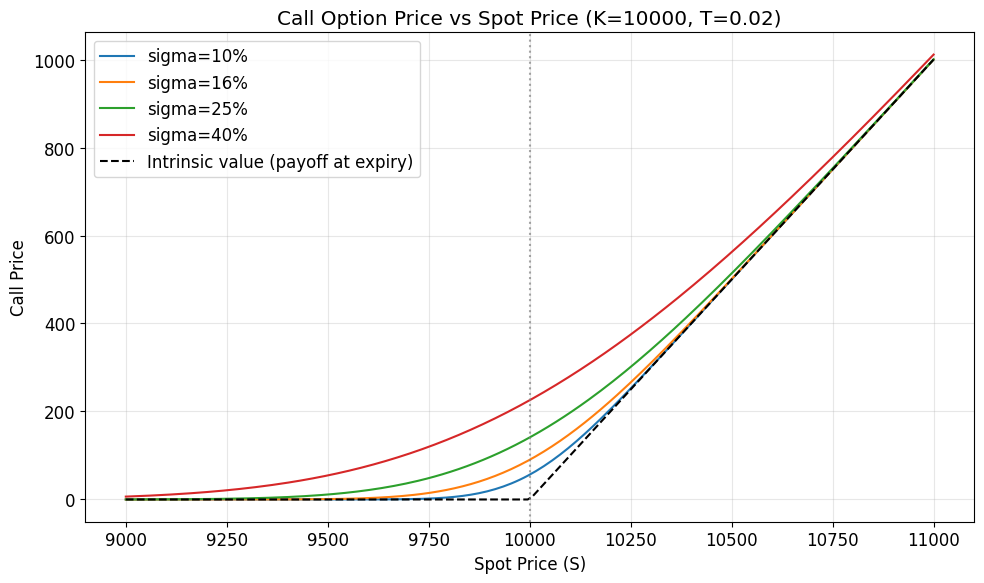

Higher volatility = higher option price
The option always worth >= intrinsic value (due to time value)


In [69]:
# ── BS Price Visualization (Price vs Spot for different vols) ──

spot_range = np.linspace(9000, 11000, 200)
strike = 10000
time_expiry = 0.02  # about 5 trading days

fig, ax = plt.subplots(figsize=(10, 6))
for sigma_val in [0.10, 0.16, 0.25, 0.40]:
    call_prices = [black_scholes_call(s, strike, time_expiry, sigma_val)
                   for s in spot_range]
    ax.plot(spot_range, call_prices, label=f"sigma={sigma_val:.0%}")

# Intrinsic value (payoff at expiry)
intrinsic = np.maximum(spot_range - strike, 0)
ax.plot(spot_range, intrinsic, "k--", label="Intrinsic value (payoff at expiry)")

ax.axvline(x=strike, color="gray", linestyle=":", alpha=0.7)
ax.set_title(f"Call Option Price vs Spot Price (K={strike}, T={time_expiry})")
ax.set_xlabel("Spot Price (S)")
ax.set_ylabel("Call Price")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Higher volatility = higher option price")
print("The option always worth >= intrinsic value (due to time value)")

#### Option Greeks

The **Greeks** measure how the option price changes with each input:
- **Delta** (Δ): How much does the call price change per $1 increase in the stock? (0 to 1)
- **Gamma** (Γ): How fast does Delta change? (sensitivity of Delta to spot)
- **Vega** (ν): How much does the call price change per 1% increase in volatility?
- **Theta** (θ): How much does the call price decay per day?

In [70]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Option Greeks
# ══════════════════════════════════════════════════════════════

def black_scholes_delta(spot: float, strike: float, time: float,
                         sigma: float, rate: float = 0.0) -> float:
    # Delta: dC/dS. Ranges from 0 (deep OTM) to 1 (deep ITM).
    # Interpretation: holding 1 call option is like holding Delta shares.
    if time <= 0 or sigma <= 0:
        return 1.0 if spot > strike else 0.0
    d1 = (math.log(spot / strike) + (rate + 0.5 * sigma**2) * time) / (sigma * math.sqrt(time))
    return norm_cdf(d1)


def black_scholes_vega(spot: float, strike: float, time: float,
                        sigma: float, rate: float = 0.0) -> float:
    # Vega: dC/d(sigma). How much option price changes per unit vol change.
    # Used in Newton-Raphson IV solver (divide price diff by Vega).
    if time <= 0 or sigma <= 0:
        return 0.0
    d1 = (math.log(spot / strike) + (rate + 0.5 * sigma**2) * time) / (sigma * math.sqrt(time))
    return spot * math.sqrt(time) * norm_pdf(d1)


def black_scholes_gamma(spot: float, strike: float, time: float,
                         sigma: float, rate: float = 0.0) -> float:
    # Gamma: d^2C/dS^2. How fast Delta changes.
    if time <= 0 or sigma <= 0:
        return 0.0
    d1 = (math.log(spot / strike) + (rate + 0.5 * sigma**2) * time) / (sigma * math.sqrt(time))
    return norm_pdf(d1) / (spot * sigma * math.sqrt(time))


# Demonstrate Greeks for at-the-money option
spot = 10000.0
k_strike = 10000.0
time_remaining = 0.02
vol = 0.16

delta_val = black_scholes_delta(spot, k_strike, time_remaining, vol)
vega_val = black_scholes_vega(spot, k_strike, time_remaining, vol)
gamma_val = black_scholes_gamma(spot, k_strike, time_remaining, vol)
call_val = black_scholes_call(spot, k_strike, time_remaining, vol)

print(f"At-the-money call option (S={spot}, K={k_strike}, T={time_remaining}, sigma={vol}):")
print(f"  Price: {call_val:.2f}")
print(f"  Delta: {delta_val:.4f}  (for every $1 stock moves, option moves ${delta_val:.4f})")
print(f"  Vega:  {vega_val:.4f}  (for every 1% vol increase, option gains ${vega_val/100:.2f})")
print(f"  Gamma: {gamma_val:.6f}  (delta changes by {gamma_val:.6f} per $1 stock move)")

At-the-money call option (S=10000.0, K=10000.0, T=0.02, sigma=0.16):
  Price: 90.27
  Delta: 0.5045  (for every $1 stock moves, option moves $0.5045)
  Vega:  564.1535  (for every 1% vol increase, option gains $5.64)
  Gamma: 0.001763  (delta changes by 0.001763 per $1 stock move)


In [71]:
# ── Implied Volatility: Bisection Solver ──────────────────────

def implied_volatility_bisection(market_price: float, spot: float,
                                  strike: float, time: float,
                                  rate: float = 0.0,
                                  low: float = 0.001,
                                  high: float = 5.0,
                                  tolerance: float = 1e-5,
                                  max_iterations: int = 100) -> float:
    # Find the volatility that makes BS price equal to market price.
    # Uses bisection (binary search) - slower than Newton-Raphson but more stable.
    # Always converges as long as market_price is in (0, spot).

    # Check if price is achievable
    min_price = black_scholes_call(spot, strike, time, low, rate)
    max_price = black_scholes_call(spot, strike, time, high, rate)

    if market_price <= min_price:
        return low
    if market_price >= max_price:
        return high

    # Bisection: repeatedly halve the search interval
    for iteration in range(max_iterations):
        mid_vol = (low + high) / 2.0
        model_price = black_scholes_call(spot, strike, time, mid_vol, rate)
        price_difference = model_price - market_price

        if abs(price_difference) < tolerance:
            return mid_vol  # converged

        if price_difference > 0:
            high = mid_vol  # model overpriced, reduce vol
        else:
            low = mid_vol   # model underpriced, increase vol

    return (low + high) / 2.0  # best estimate after max iterations


# Demo: compute IV for various market prices
underlying_price = 10000.0
option_strike = 10000.0
time_to_exp = 0.02
true_vol = 0.16

print(f"True volatility: {true_vol:.0%}")
print(f"{'Market Price':>14} {'Implied Vol':>13} {'Match?':>8}")
print("-" * 38)

for noise_factor in [0.80, 0.90, 1.00, 1.10, 1.20]:
    true_price = black_scholes_call(underlying_price, option_strike, time_to_exp, true_vol)
    market_price_noisy = true_price * noise_factor

    implied_vol = implied_volatility_bisection(
        market_price_noisy, underlying_price, option_strike, time_to_exp
    )

    match_str = "YES" if abs(implied_vol - true_vol) < 0.02 else "NO"
    print(f"{market_price_noisy:>14.2f} {implied_vol:>13.2%} {match_str:>8}")

True volatility: 16%
  Market Price   Implied Vol   Match?
--------------------------------------
         72.22        12.80%       NO
         81.24        14.40%      YES
         90.27        16.00%      YES
         99.30        17.60%      YES
        108.32        19.20%       NO


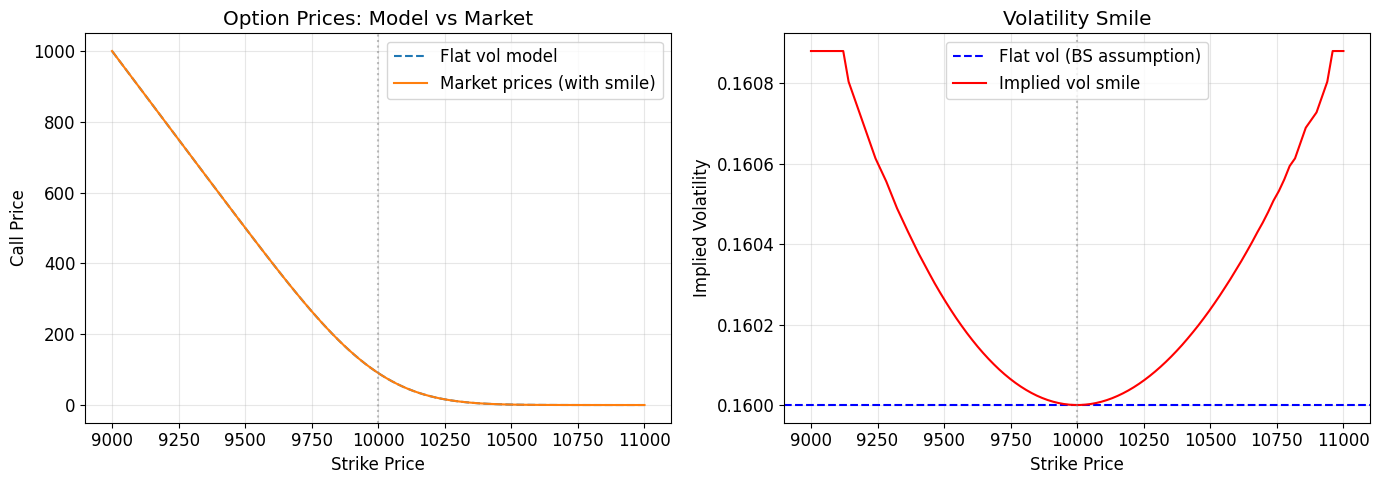

In [72]:
# ── Vol Smile Visualization ─────────────────────────────────────
# In reality, IV varies by strike. This "smile" shape is a known anomaly.

strikes = np.linspace(9000, 11000, 100)
spot_price = 10000.0
time_exp = 0.02

# Theoretical BS IV (should be flat = same vol for all strikes)
flat_vol = 0.16
bs_prices_flat = np.array([black_scholes_call(spot_price, k, time_exp, flat_vol)
                            for k in strikes])

# Add a realistic "vol smile" effect
# Real options show higher IV for OTM and ITM options
def realistic_iv(strike, spot, base_vol=0.16):
    moneyness = math.log(strike / spot)
    # Quadratic smile: smile = base + 0.1 * moneyness^2
    return base_vol + 0.1 * moneyness ** 2

market_prices = np.array([
    black_scholes_call(spot_price, k, time_exp, realistic_iv(k, spot_price))
    for k in strikes
])

# Recover IV from market prices
recovered_ivs = np.array([
    implied_volatility_bisection(price, spot_price, k, time_exp)
    for price, k in zip(market_prices, strikes)
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(strikes, bs_prices_flat, label="Flat vol model", linestyle="--")
axes[0].plot(strikes, market_prices, label="Market prices (with smile)")
axes[0].set_title("Option Prices: Model vs Market")
axes[0].set_xlabel("Strike Price")
axes[0].set_ylabel("Call Price")
axes[0].axvline(spot_price, color="gray", linestyle=":", alpha=0.5)
axes[0].legend()

axes[1].axhline(flat_vol, color="blue", linestyle="--", label="Flat vol (BS assumption)")
axes[1].plot(strikes, recovered_ivs, color="red", label="Implied vol smile")
axes[1].set_title("Volatility Smile")
axes[1].set_xlabel("Strike Price")
axes[1].set_ylabel("Implied Volatility")
axes[1].axvline(spot_price, color="gray", linestyle=":", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

> **From the Winners:** Alpha Animals (Prosperity 3, 9th place) used Newton-Raphson iteration (up to 50 steps) for faster IV convergence. chrispyroberts (Prosperity 3, 7th place) found that **rolling window IV** (recalculating from recent option prices each tick) outperformed fitting a static quadratic curve by **170,000 SeaShells per day**. Adaptive beats fitted.

In [73]:
# ── Complete Options Trading Pipeline ──────────────────────────

class VolcanicRockTrader:
    # Trades VOLCANIC_ROCK vouchers based on IV mispricing.
    # Buys options when market IV < model IV (options are cheap).
    # Sells options when market IV > model IV (options are expensive).

    def __init__(self, symbol: str = "VOLCANIC_ROCK",
                 voucher_symbol: str = "VOLCANIC_ROCK_VOUCHER_10000",
                 strike: float = 10000.0,
                 time_to_expiry: float = 0.02,
                 position_limit: int = 200,
                 iv_edge_threshold: float = 0.01):
        self.symbol = symbol
        self.voucher_symbol = voucher_symbol
        self.strike = strike
        self.time_to_expiry = time_to_expiry
        self.position_limit = position_limit
        self.iv_edge_threshold = iv_edge_threshold
        self.rolling_ivs = deque(maxlen=20)

    def run(self, state: TradingState) -> tuple:
        orders = []
        result = {}

        # Get order depths
        rock_depth = state.order_depths.get(self.symbol, OrderDepth())
        voucher_depth = state.order_depths.get(self.voucher_symbol, OrderDepth())

        if not rock_depth.buy_orders or not voucher_depth.buy_orders:
            return result, 0, ""

        # Estimate current spot price
        spot_price = estimate_simple_mid(rock_depth)

        # Get market option price
        if voucher_depth.buy_orders and voucher_depth.sell_orders:
            market_option_price = estimate_simple_mid(voucher_depth)
        else:
            return result, 0, ""

        # Compute market implied volatility
        market_iv = implied_volatility_bisection(
            market_option_price, spot_price, self.strike,
            self.time_to_expiry
        )
        self.rolling_ivs.append(market_iv)

        # Our model IV: rolling average of recent IVs
        if len(self.rolling_ivs) < 5:
            return result, 0, ""

        model_iv = sum(self.rolling_ivs) / len(self.rolling_ivs)
        iv_diff = market_iv - model_iv

        position = state.position.get(self.voucher_symbol, 0)

        if iv_diff < -self.iv_edge_threshold:
            # Market IV < model IV: options are CHEAP, BUY
            if voucher_depth.sell_orders:
                best_ask = min(voucher_depth.sell_orders.keys())
                buy_qty = min(5, self.position_limit - position)
                if buy_qty > 0:
                    orders.append(Order(self.voucher_symbol, best_ask, buy_qty))

        elif iv_diff > self.iv_edge_threshold:
            # Market IV > model IV: options are EXPENSIVE, SELL
            if voucher_depth.buy_orders:
                best_bid = max(voucher_depth.buy_orders.keys())
                sell_qty = min(5, self.position_limit + position)
                if sell_qty > 0:
                    orders.append(Order(self.voucher_symbol, best_bid, -sell_qty))

        if orders:
            result[self.voucher_symbol] = orders

        return result, 0, ""


print("VolcanicRockTrader defined.")
print("Strategy: buy vouchers when market IV < model IV (options cheap)")
print("          sell vouchers when market IV > model IV (options expensive)")

VolcanicRockTrader defined.
Strategy: buy vouchers when market IV < model IV (options cheap)
          sell vouchers when market IV > model IV (options expensive)


In [74]:
# ── EXERCISE: Detect Mispriced Options ─────────────────────────
# Given a list of (spot_price, strike, market_call_price) tuples,
# find which options are more than 10% mispriced vs Black-Scholes
# with sigma = 0.16.

option_data = [
    (10000, 10000, 0.02, 0.16, 95.0),   # (spot, strike, time, bs_sigma, market_price)
    (10000, 10000, 0.02, 0.16, 65.0),   # underpriced
    (10000, 9500, 0.02, 0.16, 540.0),   # in-the-money
    (10000, 10500, 0.02, 0.16, 15.0),   # out-of-the-money, expensive
    (10000, 10000, 0.01, 0.16, 45.0),   # less time to expiry
]

print(f"{'Spot':>6} {'Strike':>8} {'T':>6} {'Mkt Price':>10} {'BS Price':>10} {'Diff%':>8} {'Signal':>8}")
print("-" * 65)
for row in option_data:
    s_p, strike_p, t_p, sigma_p, mkt_p = row
    bs_p = black_scholes_call(s_p, strike_p, t_p, sigma_p)
    diff_pct = (mkt_p - bs_p) / bs_p * 100 if bs_p > 0 else 0
    if diff_pct < -10:
        signal = "BUY"
    elif diff_pct > 10:
        signal = "SELL"
    else:
        signal = "HOLD"
    print(f"{s_p:>6} {strike_p:>8} {t_p:>6.2f} {mkt_p:>10.2f} {bs_p:>10.2f} {diff_pct:>7.1f}% {signal:>8}")

  Spot   Strike      T  Mkt Price   BS Price    Diff%   Signal
-----------------------------------------------------------------
 10000    10000   0.02      95.00      90.27     5.2%     HOLD
 10000    10000   0.02      65.00      90.27   -28.0%      BUY
 10000     9500   0.02     540.00     500.89     7.8%     HOLD
 10000    10500   0.02      15.00       1.28  1069.8%     SELL
 10000    10000   0.01      45.00      63.83   -29.5%      BUY


> **Common Mistake:** Incomplete delta hedging can cost MORE than unhedged directional exposure. If you sell options (collecting premium) but fail to delta-hedge, a large move in the underlying can wipe out all your premium income. Linear Utility (P2, 2nd place) found that their options hedging costs sometimes exceeded their options profits.

> **From the Winners:** Frankfurt Hedgehogs (Prosperity 3, 2nd place) made **100,000-150,000 SeaShells per round** from IV scalping alone - buying options when market IV was below their model IV and selling when above. They used the "vol smile" (IV varying by strike) to identify systematic mispricings.

> **Intuition Check:** Why does higher volatility always mean a higher option price? Because more volatility means more chance the underlying price will make a large move, putting the option "in the money." An option is a one-sided bet: you benefit from big upward moves but your downside is capped at the premium paid. More volatility = more chance of that big upward move = higher option value.

### 3.7 Counterparty Identification: The "Olivia" Signal

In Prosperity 3, every trade record includes who was the buyer and who was the seller. Analysis revealed that a trader named **"Olivia"** consistently **bought at daily price lows and sold at daily price highs** - she was an informed insider trading on private information.

Teams that identified her trades and **copied her direction** made significant profits. Frankfurt Hedgehogs and Alpha Animals both independently discovered this signal.

In [75]:
# ══════════════════════════════════════════════════════════════
# [SUBMISSION-SAFE] Counterparty Trade Detection
# Identify when "Olivia" (or another informed trader) is active.
# ══════════════════════════════════════════════════════════════

INFORMED_TRADER_ID = "Olivia"

def detect_informed_direction(market_trades: list,
                               informed_id: str = INFORMED_TRADER_ID) -> str:
    # Scan recent market trades for the informed trader.
    # Returns: "BULLISH", "BEARISH", or "NEUTRAL"

    if not market_trades:
        return "NEUTRAL"

    last_buy_timestamp = None
    last_sell_timestamp = None

    for trade in market_trades:
        if trade.buyer == informed_id:
            # Informed trader bought = bullish signal
            if last_buy_timestamp is None or trade.timestamp > last_buy_timestamp:
                last_buy_timestamp = trade.timestamp

        elif trade.seller == informed_id:
            # Informed trader sold = bearish signal
            if last_sell_timestamp is None or trade.timestamp > last_sell_timestamp:
                last_sell_timestamp = trade.timestamp

    # Determine direction based on most recent action
    if last_buy_timestamp is None and last_sell_timestamp is None:
        return "NEUTRAL"
    elif last_buy_timestamp is None:
        return "BEARISH"
    elif last_sell_timestamp is None:
        return "BULLISH"
    else:
        # Most recent action determines direction
        if last_buy_timestamp > last_sell_timestamp:
            return "BULLISH"
        elif last_sell_timestamp > last_buy_timestamp:
            return "BEARISH"
        else:
            return "NEUTRAL"


# Demo
sample_trades = [
    Trade("SQUID_INK", 3100, 10, buyer="Olivia", seller="Alice", timestamp=500),
    Trade("SQUID_INK", 3102, 5, buyer="Bob", seller="Charlie", timestamp=600),
    Trade("SQUID_INK", 3108, 8, buyer="Dave", seller="Olivia", timestamp=700),
]

direction = detect_informed_direction(sample_trades)
print(f"Olivia's last action: SELL at timestamp 700")
print(f"Detected direction: {direction}")
print("(She sold last = bearish signal)")

Olivia's last action: SELL at timestamp 700
Detected direction: BEARISH
(She sold last = bearish signal)


In [76]:
# ── Copy-Trading Strategy ───────────────────────────────────────

class OliviaCopyTrader:
    # Copies Olivia's direction: go max long when she buys, max short when she sells.
    # Persists her last action in traderData across ticks.

    def __init__(self, symbol: str = "SQUID_INK",
                 position_limit: int = 50,
                 informed_trader_id: str = "Olivia"):
        self.symbol = symbol
        self.position_limit = position_limit
        self.informed_id = informed_trader_id
        self.last_buy_ts = None
        self.last_sell_ts = None

    def run(self, state: TradingState) -> tuple:
        orders = []

        # Restore timestamps from traderData (persist across ticks)
        if state.traderData:
            try:
                saved = json.loads(state.traderData)
                self.last_buy_ts = saved.get("buy_ts", None)
                self.last_sell_ts = saved.get("sell_ts", None)
            except Exception:
                pass

        # Scan market trades for Olivia
        market_trades = state.market_trades.get(self.symbol, [])
        for trade in market_trades:
            if trade.buyer == self.informed_id:
                if self.last_buy_ts is None or trade.timestamp > self.last_buy_ts:
                    self.last_buy_ts = trade.timestamp
            elif trade.seller == self.informed_id:
                if self.last_sell_ts is None or trade.timestamp > self.last_sell_ts:
                    self.last_sell_ts = trade.timestamp

        # Determine current direction
        direction = "NEUTRAL"
        if self.last_buy_ts is not None and self.last_sell_ts is None:
            direction = "BULLISH"
        elif self.last_sell_ts is not None and self.last_buy_ts is None:
            direction = "BEARISH"
        elif self.last_buy_ts is not None and self.last_sell_ts is not None:
            if self.last_buy_ts > self.last_sell_ts:
                direction = "BULLISH"
            elif self.last_sell_ts > self.last_buy_ts:
                direction = "BEARISH"

        position = state.position.get(self.symbol, 0)
        order_depth = state.order_depths.get(self.symbol, OrderDepth())

        if direction == "BULLISH":
            # Go max long: buy as much as possible
            target_position = self.position_limit
            quantity_needed = target_position - position
            if quantity_needed > 0 and order_depth.sell_orders:
                best_ask = min(order_depth.sell_orders.keys())
                orders.append(Order(self.symbol, best_ask, quantity_needed))

        elif direction == "BEARISH":
            # Go max short: sell as much as possible
            target_position = -self.position_limit
            quantity_needed = position - target_position
            if quantity_needed > 0 and order_depth.buy_orders:
                best_bid = max(order_depth.buy_orders.keys())
                orders.append(Order(self.symbol, best_bid, -quantity_needed))

        result = {self.symbol: orders} if orders else {}
        trader_data = json.dumps({
            "buy_ts": self.last_buy_ts,
            "sell_ts": self.last_sell_ts
        })
        return result, 0, trader_data


print("OliviaCopyTrader defined.")
print("Direction: BULLISH if Olivia bought more recently, BEARISH if she sold")

OliviaCopyTrader defined.
Direction: BULLISH if Olivia bought more recently, BEARISH if she sold


Olivia win rate (with perfect foresight): 100%
Expected win rate without insight: 50%
Edge: 50%


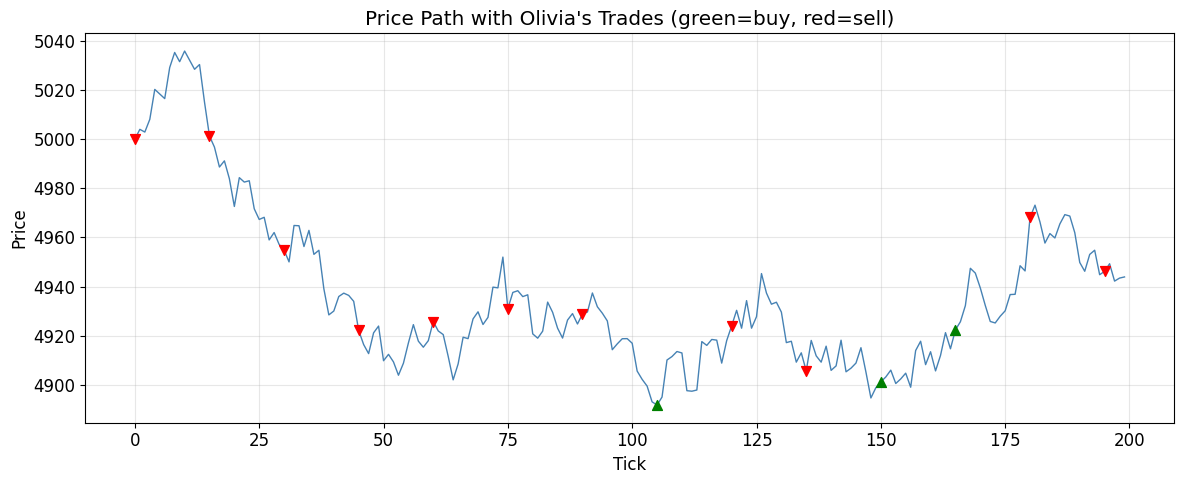

In [77]:
# ── Synthetic Insider Trade Simulation ─────────────────────────
# Simulate an environment where an insider (Olivia) knows the price
# direction and always trades profitably.

np.random.seed(42)
num_ticks_sim = 200

# True price path: random walk
true_prices_insider = [5000.0]
for _ in range(num_ticks_sim - 1):
    true_prices_insider.append(true_prices_insider[-1] + np.random.normal(0, 8))
true_prices_insider = np.array(true_prices_insider)

# Compute 20-period forward returns to determine Olivia's direction
forward_window = 20
olivia_direction = []
for i in range(num_ticks_sim):
    future_end = min(i + forward_window, num_ticks_sim - 1)
    future_return = true_prices_insider[future_end] - true_prices_insider[i]
    olivia_direction.append("BUY" if future_return > 0 else "SELL")

# Compute win rate: what fraction of the time does following Olivia work?
correct_at_forward = []
for i in range(num_ticks_sim - forward_window):
    actual_return = true_prices_insider[i + forward_window] - true_prices_insider[i]
    if olivia_direction[i] == "BUY" and actual_return > 0:
        correct_at_forward.append(1)
    elif olivia_direction[i] == "SELL" and actual_return < 0:
        correct_at_forward.append(1)
    else:
        correct_at_forward.append(0)

win_rate = sum(correct_at_forward) / len(correct_at_forward)
print(f"Olivia win rate (with perfect foresight): {win_rate:.0%}")
print(f"Expected win rate without insight: 50%")
print(f"Edge: {win_rate - 0.5:.0%}")

# Plot price with Olivia's trades marked
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(true_prices_insider, color="steelblue", linewidth=1, label="Price")

for i in range(0, num_ticks_sim, 15):
    if olivia_direction[i] == "BUY":
        ax.scatter(i, true_prices_insider[i], color="green", marker="^", s=50, zorder=5)
    else:
        ax.scatter(i, true_prices_insider[i], color="red", marker="v", s=50, zorder=5)

ax.set_title("Price Path with Olivia's Trades (green=buy, red=sell)")
ax.set_xlabel("Tick")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

> **From the Winners:** All top 3 teams in Prosperity 3 independently discovered and exploited Olivia. Frankfurt Hedgehogs (2nd place) persisted her buy/sell timestamps in `traderData` across ticks, so the signal lasted even after her trades scrolled out of `market_trades`. When Olivia was bullish on SQUID_INK, they immediately went to max long position.

### Part 3 Summary

You now have seven complete trading strategies:

| Strategy | Key Parameters | Products |
|----------|----------------|----------|
| StableMarketMaker | fair_price=10000, spread=1 | RAINFOREST_RESIN |
| VolatileMarketMaker | ema_alpha=0.3, spread=2 | KELP, SQUID_INK |
| PairsTrader | z_threshold=2-11, window=30 | CROISSANTS+JAMS |
| BasketTrader | premium_threshold, window=50 | PICNIC_BASKET1/2 |
| ConversionTrader | min_profit=2.0 | MACARONS |
| VolcanicRockTrader | iv_edge=0.01 | VOLCANIC_ROCK vouchers |
| OliviaCopyTrader | (none needed) | SQUID_INK |

In Part 4, we cover **manual trading rounds**: FX arbitrage, sealed-bid auctions, game theory, and news sentiment. In Part 5, we integrate everything into a complete competition bot.

## Part 4: Manual Trading Rounds

In each round of IMC Prosperity, teams face not only an **algorithmic trading challenge** but also a **manual trading puzzle** that you solve by hand or with quick scripts. These manual rounds are worth significant points and can make the difference between qualifying and going home. Think of them as the "bonus round" in a game show -- they reward broad thinking, not just coding speed. The puzzles range from foreign-exchange arbitrage to auction theory to game-theoretic allocation problems. In this part, we will build reusable frameworks for every manual-round archetype seen in past Prosperity competitions.

### 4.1 FX Arbitrage

**FX Arbitrage** is one of the most classic manual-round formats. You are given **exchange rates** between multiple currencies and must find a **cycle** -- a sequence of conversions like A -> B -> C -> A -- where you end up with more than you started with. This is identical to the "negative-weight cycle" problem in graph theory, and in real-world finance it is the bread and butter of FX desks. The key insight is that if the product of exchange rates along a cycle exceeds 1.0, the cycle is profitable. In Prosperity, these rates are presented in a table and you have limited time to find the best path, so having a script ready is essential.

Consider a small economy with four currencies and the following exchange rates:

```
        PIZZA <---2.5--- WASABI
          |                 ^
         1.45              0.52
          v                 |
        SNOWBALL --3.1--> SHELLS
```

Starting with **1 SHELL**, let us trace a few candidate cycles to see which ones are profitable:

- **Path 1**: SHELLS -> PIZZA (rate = 1/1.45 = 0.6897) -> WASABI (0.6897 * 2.5 = 1.724) -> SHELLS (1.724 * 0.52 = 0.896). **Loss of 10.4%!**
- **Path 2**: SHELLS -> SNOWBALL (rate = 1/3.1 = 0.3226) -> PIZZA (0.3226 * 0.41 = 0.1323) -> ... even worse.
- We need to systematically try **all** cycles to find the one that yields a product greater than 1.0.

The brute-force approach is perfectly adequate for 4-6 currencies since the number of cycles is small. For larger sets, the **Bellman-Ford** algorithm on log-transformed rates is the standard tool.

In [78]:
# Represent exchange rates as a dictionary of dictionaries
# exchange_rates[from_currency][to_currency] = rate
exchange_rates = {
    "SHELLS": {"PIZZA": 1.45, "SNOWBALL": 0.32},
    "PIZZA": {"SHELLS": 0.69, "WASABI": 2.5, "SNOWBALL": 0.41},
    "WASABI": {"SHELLS": 0.52, "PIZZA": 0.40, "SNOWBALL": 1.8},
    "SNOWBALL": {"SHELLS": 3.1, "PIZZA": 2.44, "WASABI": 0.72}
}

# List all currencies
currencies = list(exchange_rates.keys())
# Print the full rate table for reference
print("=== Exchange Rate Table ===")
for source_currency in currencies:
    # Build a readable row for this currency
    destinations = exchange_rates[source_currency]
    for dest_currency, rate in destinations.items():
        # Show each directed edge and its rate
        print(f"  {source_currency:>10} -> {dest_currency:<10} : {rate:.4f}")
print()

# Count the total number of directed edges
total_edges = sum(len(v) for v in exchange_rates.values())
print(f"Total directed edges: {total_edges}")
print(f"Number of currencies: {len(currencies)}")

=== Exchange Rate Table ===
      SHELLS -> PIZZA      : 1.4500
      SHELLS -> SNOWBALL   : 0.3200
       PIZZA -> SHELLS     : 0.6900
       PIZZA -> WASABI     : 2.5000
       PIZZA -> SNOWBALL   : 0.4100
      WASABI -> SHELLS     : 0.5200
      WASABI -> PIZZA      : 0.4000
      WASABI -> SNOWBALL   : 1.8000
    SNOWBALL -> SHELLS     : 3.1000
    SNOWBALL -> PIZZA      : 2.4400
    SNOWBALL -> WASABI     : 0.7200

Total directed edges: 11
Number of currencies: 4


In [79]:
from itertools import permutations

# Brute-force: enumerate all cycles that start and end at each currency
# For N currencies, a cycle can visit 2..N currencies before returning
start_currency = "SHELLS"
all_other_currencies = [c for c in currencies if c != start_currency]

# Store every cycle and its cumulative rate product
cycle_results = []

# Try cycles of length 2, 3, and 4 (including start)
for cycle_length in range(1, len(all_other_currencies) + 1):
    # Generate all orderings of cycle_length intermediate currencies
    for intermediate_path in permutations(all_other_currencies, cycle_length):
        # Build the full path: start -> intermediates -> start
        full_path = [start_currency] + list(intermediate_path) + [start_currency]

        # Compute the product of exchange rates along this path
        rate_product = 1.0
        path_is_valid = True
        for step_index in range(len(full_path) - 1):
            # Get the rate from current to next currency
            from_curr = full_path[step_index]
            to_curr = full_path[step_index + 1]
            if to_curr in exchange_rates.get(from_curr, {}):
                step_rate = exchange_rates[from_curr][to_curr]
                rate_product *= step_rate
            else:
                # No direct edge exists for this pair
                path_is_valid = False
                break

        if path_is_valid:
            # Record the cycle and its product
            cycle_results.append((full_path, rate_product))

# Sort by rate product descending to find the most profitable
cycle_results.sort(key=lambda x: x[1], reverse=True)

# Display the top 5 cycles
print("=== Top 5 Cycles (by rate product) ===")
for rank, (path, product) in enumerate(cycle_results[:5], 1):
    # Format the path as a readable arrow chain
    path_string = " -> ".join(path)
    # Flag profitable cycles with a star
    profit_flag = " *** PROFITABLE ***" if product > 1.0 else ""
    print(f"  #{rank}: {path_string}")
    print(f"       Product = {product:.6f}{profit_flag}")
    print()

# Count how many profitable cycles exist
profitable_count = sum(1 for _, p in cycle_results if p > 1.0)
print(f"Total cycles found: {len(cycle_results)}")
print(f"Profitable cycles (product > 1.0): {profitable_count}")

=== Top 5 Cycles (by rate product) ===
  #1: SHELLS -> PIZZA -> WASABI -> SNOWBALL -> SHELLS
       Product = 20.227500 *** PROFITABLE ***

  #2: SHELLS -> PIZZA -> WASABI -> SHELLS
       Product = 1.885000 *** PROFITABLE ***

  #3: SHELLS -> PIZZA -> SNOWBALL -> SHELLS
       Product = 1.842950 *** PROFITABLE ***

  #4: SHELLS -> SNOWBALL -> PIZZA -> WASABI -> SHELLS
       Product = 1.015040 *** PROFITABLE ***

  #5: SHELLS -> PIZZA -> SHELLS
       Product = 1.000500 *** PROFITABLE ***

Total cycles found: 10
Profitable cycles (product > 1.0): 5


In [80]:
# Exercise: Given a NEW set of exchange rates, find the most profitable cycle.
# The table below has 5 currencies. Find the cycle starting from SHELLS
# that yields the highest rate product.

exercise_rates = {
    "SHELLS": {"PIZZA": 0.48, "SNOWBALL": 0.52, "WASABI": 1.95},
    "PIZZA": {"SHELLS": 2.05, "SNOWBALL": 1.07, "WASABI": 3.91, "KELP": 0.63},
    "SNOWBALL": {"SHELLS": 1.86, "PIZZA": 0.93, "KELP": 1.21},
    "WASABI": {"SHELLS": 0.49, "PIZZA": 0.25, "KELP": 0.31},
    "KELP": {"SHELLS": 2.72, "PIZZA": 1.58, "SNOWBALL": 0.82, "WASABI": 3.15}
}

# YOUR TASK:
# 1. Enumerate all cycles starting and ending at "SHELLS"
# 2. Compute each cycle's rate product
# 3. Print the top 3 most profitable cycles
# Hint: reuse the permutations approach from the previous cell

In [81]:
# Solution to the FX arbitrage exercise
exercise_currencies = list(exercise_rates.keys())
# All currencies except the starting one
other_currencies = [c for c in exercise_currencies if c != "SHELLS"]

# Collect all valid cycles with their rate products
exercise_cycles = []

# Iterate over cycle lengths from 1 to len(other_currencies)
for num_intermediates in range(1, len(other_currencies) + 1):
    # Try every ordering of intermediate currencies
    for intermediates in permutations(other_currencies, num_intermediates):
        # Build full cycle: SHELLS -> ... -> SHELLS
        full_cycle = ["SHELLS"] + list(intermediates) + ["SHELLS"]

        # Multiply all rates along the path
        cumulative_product = 1.0
        cycle_valid = True
        for i in range(len(full_cycle) - 1):
            source = full_cycle[i]
            destination = full_cycle[i + 1]
            # Check if the edge exists
            if destination in exercise_rates.get(source, {}):
                cumulative_product *= exercise_rates[source][destination]
            else:
                cycle_valid = False
                break

        # Only keep valid cycles
        if cycle_valid:
            exercise_cycles.append((full_cycle, cumulative_product))

# Sort descending by product
exercise_cycles.sort(key=lambda x: x[1], reverse=True)

# Print the top 3 most profitable cycles
print("=== Exercise Solution: Top 3 Cycles ===")
for rank, (path, product) in enumerate(exercise_cycles[:3], 1):
    path_str = " -> ".join(path)
    status = "PROFIT" if product > 1.0 else "LOSS"
    print(f"  #{rank} [{status}]: {path_str}")
    # Show the percentage gain or loss
    gain_pct = (product - 1.0) * 100
    print(f"       Product = {product:.6f} ({gain_pct:+.2f}%)")
    print()

# Show total profitable cycles
num_profitable = sum(1 for _, p in exercise_cycles if p > 1.0)
print(f"Total valid cycles: {len(exercise_cycles)}")
print(f"Profitable cycles: {num_profitable}")

=== Exercise Solution: Top 3 Cycles ===
  #1 [PROFIT]: SHELLS -> SNOWBALL -> KELP -> PIZZA -> SHELLS
       Product = 2.037979 (+103.80%)

  #2 [PROFIT]: SHELLS -> WASABI -> KELP -> PIZZA -> SHELLS
       Product = 1.957976 (+95.80%)

  #3 [PROFIT]: SHELLS -> SNOWBALL -> KELP -> PIZZA -> WASABI -> SHELLS
       Product = 1.904665 (+90.47%)

Total valid cycles: 32
Profitable cycles: 11


> **From the Winners:** In Prosperity 2, the FX arbitrage manual round required finding optimal conversion paths between 5 currencies. The best teams wrote brute-force scripts **before** the competition to check all possible cycles instantly. With only 4-6 currencies, the number of permutations is tiny (at most a few hundred), so exhaustive search is both feasible and reliable. The real danger is making arithmetic mistakes under time pressure -- let the computer do the multiplication.

### 4.2 Sealed-Bid Auctions

In a **sealed-bid auction**, you submit a bid for an item that has a known value **V** to you. Your opponent (or a bot) submits their own bid drawn from some distribution -- commonly **Uniform[L, H]**. If your bid is higher, you win and **pay your bid**. Your profit is therefore **V - your_bid**, but only if you win. If you lose, your profit is zero. This is a classic first-price sealed-bid auction. The fundamental tension is between bidding high (to increase your probability of winning) and bidding low (to increase your profit when you do win). Bidding exactly V guarantees zero profit even when you win, so the optimal bid always "shades" below V.

**Step-by-step derivation of the optimal bid:**

Let the item value be **V = 1000** and the opponent bid **~ Uniform[900, 1000]**. You bid **x**.

1. **Probability of winning:** P(win) = P(opponent < x) = (x - 900) / (1000 - 900) = (x - 900) / 100, valid for 900 <= x <= 1000.
2. **Profit if you win:** profit = V - x = 1000 - x.
3. **Expected profit:** E[profit] = P(win) * profit_if_win = ((x - 900) / 100) * (1000 - x).
4. **Expand:** E = (x - 900)(1000 - x) / 100 = (-x^2 + 1900x - 900000) / 100.
5. **Differentiate and set to zero:** dE/dx = (-2x + 1900) / 100 = 0, so **x* = 950**.
6. **Expected profit at optimum:** E[profit] = (950 - 900)(1000 - 950) / 100 = (50)(50) / 100 = **25**.

The general formula for V > H: optimal bid = (L + V) / 2, i.e., bid halfway between the opponent's lower bound and your value for the item. When V falls within [L, H], the formula becomes x* = (L + V) / 2 as well, but the constraint x <= V applies.

Grid search optimal bid: 950
Grid search expected profit: 25.00

Analytical optimal bid: 950.0
Analytical expected profit: 25.00


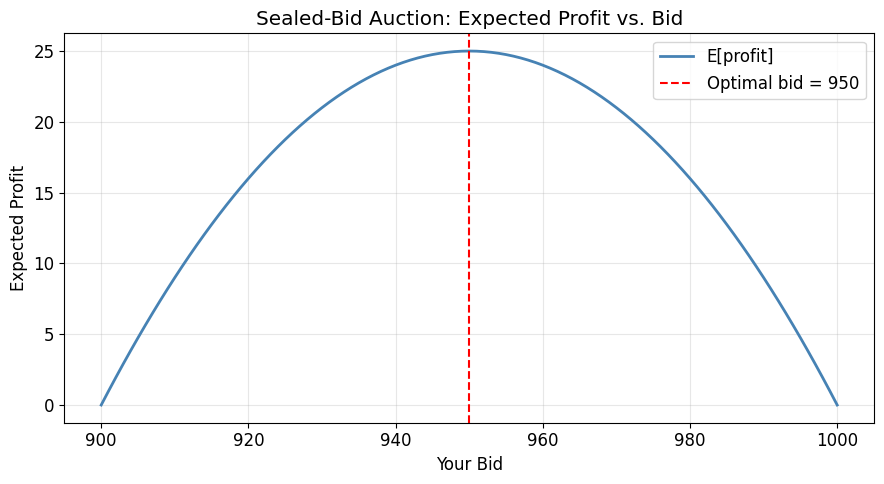

In [82]:
# Grid search: try every possible bid and compute expected profit
item_value = 1000
opponent_low = 900
opponent_high = 1000

# Track the best bid found so far
best_bid = 0
best_expected_profit = 0

# Also store all results for plotting
all_bids = []
all_profits = []

for bid in range(opponent_low, item_value + 1):
    # Probability of winning = P(opponent bids less than our bid)
    probability_of_winning = max(0, min(1, (bid - opponent_low) / (opponent_high - opponent_low)))
    # Profit if we win is the difference between value and our bid
    profit_if_win = item_value - bid
    # Expected profit = probability * payoff
    expected_profit = probability_of_winning * profit_if_win

    # Record for plotting
    all_bids.append(bid)
    all_profits.append(expected_profit)

    # Update the best if this bid is superior
    if expected_profit > best_expected_profit:
        best_expected_profit = expected_profit
        best_bid = bid

# Print the grid search result
print(f"Grid search optimal bid: {best_bid}")
print(f"Grid search expected profit: {best_expected_profit:.2f}")

# Analytical solution: bid halfway between opponent_low and item_value
analytical_optimal = (opponent_low + item_value) / 2
# Compute expected profit at the analytical optimum
analytical_p_win = (analytical_optimal - opponent_low) / (opponent_high - opponent_low)
analytical_profit = analytical_p_win * (item_value - analytical_optimal)
print(f"\nAnalytical optimal bid: {analytical_optimal:.1f}")
print(f"Analytical expected profit: {analytical_profit:.2f}")

# Plot expected profit vs bid
plt.figure(figsize=(9, 5))
plt.plot(all_bids, all_profits, linewidth=2, color="steelblue", label="E[profit]")
# Mark the optimum with a vertical line
plt.axvline(x=best_bid, color="red", linestyle="--", label=f"Optimal bid = {best_bid}")
plt.xlabel("Your Bid")
plt.ylabel("Expected Profit")
plt.title("Sealed-Bid Auction: Expected Profit vs. Bid")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [83]:
# Dual-bid Monte Carlo: what if you can submit TWO bids?
# You win if EITHER bid beats the opponent, but you pay the winning bid.
# If both beat the opponent, you pay the LOWER of your two bids (better for you).
num_simulations = 200_000

# Define two bids to test
bid_a = 940
bid_b = 970

# Accumulators for profit
total_profit_dual = 0.0
total_wins_dual = 0

# Single-bid baseline at the analytical optimum
single_bid = 950
total_profit_single = 0.0
total_wins_single = 0

for sim_index in range(num_simulations):
    # Draw the opponent's bid uniformly from [900, 1000]
    opponent_bid = np.random.uniform(opponent_low, opponent_high)

    # --- Dual bid logic ---
    bid_a_wins = bid_a > opponent_bid
    bid_b_wins = bid_b > opponent_bid

    if bid_a_wins and bid_b_wins:
        # Both win; we pay the lower bid (more profit)
        payment = min(bid_a, bid_b)
        total_profit_dual += (item_value - payment)
        total_wins_dual += 1
    elif bid_a_wins:
        # Only bid A wins
        total_profit_dual += (item_value - bid_a)
        total_wins_dual += 1
    elif bid_b_wins:
        # Only bid B wins
        total_profit_dual += (item_value - bid_b)
        total_wins_dual += 1

    # --- Single bid baseline ---
    if single_bid > opponent_bid:
        total_profit_single += (item_value - single_bid)
        total_wins_single += 1

# Compute averages
avg_profit_dual = total_profit_dual / num_simulations
avg_profit_single = total_profit_single / num_simulations
win_rate_dual = total_wins_dual / num_simulations
win_rate_single = total_wins_single / num_simulations

# Print comparison
print("=== Dual-Bid vs Single-Bid Monte Carlo ===")
print(f"Simulations: {num_simulations:,}")
print(f"\nSingle bid ({single_bid}):")
print(f"  Win rate: {win_rate_single:.2%}")
print(f"  Avg profit: {avg_profit_single:.2f}")
print(f"\nDual bids ({bid_a}, {bid_b}):")
print(f"  Win rate: {win_rate_dual:.2%}")
print(f"  Avg profit: {avg_profit_dual:.2f}")
print(f"\nDual bid advantage: {avg_profit_dual - avg_profit_single:+.2f}")

=== Dual-Bid vs Single-Bid Monte Carlo ===
Simulations: 200,000

Single bid (950):
  Win rate: 49.88%
  Avg profit: 24.94

Dual bids (940, 970):
  Win rate: 69.95%
  Avg profit: 32.96

Dual bid advantage: +8.02


In [84]:
# Exercise: Compute the optimal bid when the item value is UNCERTAIN.
# Item value is drawn from Uniform[800, 1200].
# Opponent bids from Uniform[850, 1050].
# Use Monte Carlo with 100,000 simulations to find the best fixed bid.

# YOUR TASK:
# 1. For each candidate bid from 850 to 1050 (step 5), run Monte Carlo
# 2. In each simulation, draw item_value ~ Uniform[800, 1200]
#    and opponent_bid ~ Uniform[850, 1050]
# 3. Your profit = max(0, item_value - your_bid) if you win, else 0
#    BUT if item_value < your_bid, you still pay your bid (loss = your_bid - item_value)
# 4. Find the bid that maximizes average profit

Best fixed bid: 920
Expected profit at best bid: 28.20


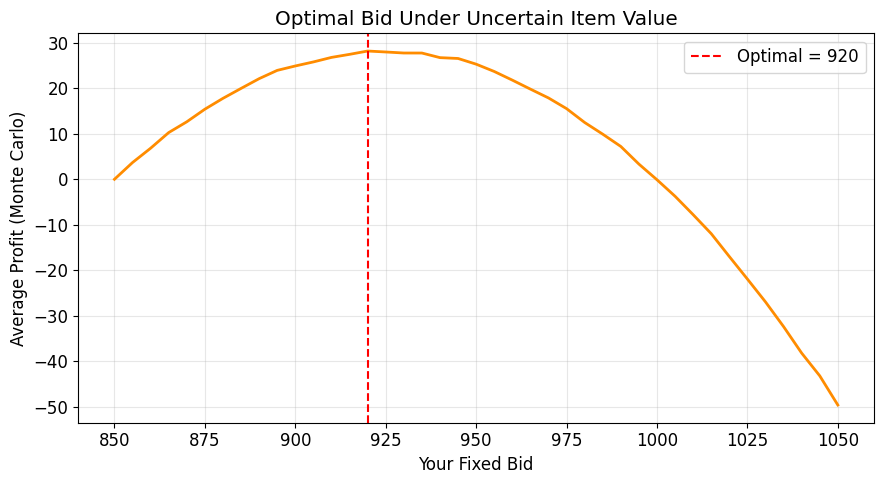

In [85]:
# Solution: Optimal bid under uncertain item value
num_mc_sims = 100_000
candidate_bids = list(range(850, 1051, 5))

# Store average profit for each candidate bid
avg_profits_by_bid = []

for candidate_bid in candidate_bids:
    # Draw random item values and opponent bids
    item_values = np.random.uniform(800, 1200, size=num_mc_sims)
    opponent_bids = np.random.uniform(850, 1050, size=num_mc_sims)

    # Determine where we win (our bid exceeds opponent)
    wins = candidate_bid > opponent_bids
    # Profit when we win: item_value - our_bid (can be negative if item_value < bid)
    profit_when_win = item_values - candidate_bid
    # Total profit: only count rounds where we win
    total_profit = np.sum(profit_when_win[wins])
    # Average over ALL simulations (not just wins)
    average_profit = total_profit / num_mc_sims
    avg_profits_by_bid.append(average_profit)

# Find the best candidate bid
best_index = np.argmax(avg_profits_by_bid)
best_candidate = candidate_bids[best_index]
best_avg_profit = avg_profits_by_bid[best_index]

# Print the result
print(f"Best fixed bid: {best_candidate}")
print(f"Expected profit at best bid: {best_avg_profit:.2f}")

# Plot the expected profit curve
plt.figure(figsize=(9, 5))
plt.plot(candidate_bids, avg_profits_by_bid, linewidth=2, color="darkorange")
# Mark the optimum
plt.axvline(x=best_candidate, color="red", linestyle="--", label=f"Optimal = {best_candidate}")
plt.xlabel("Your Fixed Bid")
plt.ylabel("Average Profit (Monte Carlo)")
plt.title("Optimal Bid Under Uncertain Item Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **Intuition Check:** Why not bid exactly the item value (say 1000)? Because then your profit is **zero** even when you win -- you are paying full price for something worth exactly what you paid. The optimal bid always "shades" below the item's value to preserve a **profit margin**. The tradeoff is simple: bidding lower means higher profit per win but fewer wins; bidding higher means more wins but thinner margins. The optimal bid balances these two forces, and for Uniform opponents the answer is elegantly the midpoint between the opponent's lower bound and your value.

### 4.3 Game Theory & Nash Equilibrium

A **Nash equilibrium** is a set of strategies -- one for each player -- where no individual player can improve their outcome by unilaterally changing their strategy. Think of choosing which side of the road to drive on: once everyone agrees on "right," no one benefits from switching to "left," because crashing head-on is much worse than going with the flow. In Prosperity manual rounds, Nash equilibria appear whenever your payoff depends on what **other teams** choose. Understanding equilibrium helps you identify the "default rational" strategy, and then decide whether deviating from it could be profitable.

In Prosperity, manual rounds often involve **resource allocation games** where you distribute a budget of points (say 100 units) across several options. The payoff for each option depends on how many **other players** also allocated to that option -- more competition means a smaller share of the prize pool. The **Nash equilibrium** allocation equalizes the marginal return across all options, so that shifting one unit from any option to another yields zero net benefit. In practice, the equilibrium allocation is proportional to each option's prize pool.

In [86]:
# Nash equilibrium for a resource allocation game
# Setup: distribute 100 units across 5 options
# Payoff for option i = (your_allocation_i / total_allocation_i) * prize_pool_i
# There are 100 opponents, each playing Nash equilibrium
total_budget = 100
num_opponents = 100

# Prize pools for each of the 5 options
prize_pools = [5000, 3000, 2000, 1500, 500]
option_names = ["Alpha", "Beta", "Gamma", "Delta", "Epsilon"]
num_options = len(prize_pools)

# Nash equilibrium: allocate proportionally to prize pool
total_prize = sum(prize_pools)
# Each player's Nash allocation is proportional to the prize pool
nash_allocations = [(pool / total_prize) * total_budget for pool in prize_pools]

# Print Nash allocations
print("=== Nash Equilibrium Allocation ===")
print(f"Total budget: {total_budget} units")
print(f"Number of opponents: {num_opponents}")
print()
for i in range(num_options):
    # Show each option's prize pool and optimal allocation
    print(f"  {option_names[i]:>8}: prize={prize_pools[i]:>5}, "
          f"Nash alloc = {nash_allocations[i]:.1f} units "
          f"({nash_allocations[i]/total_budget:.0%})")

# Verify: at Nash, the payoff per unit invested should be equal across all options
print("\n=== Payoff Per Unit at Nash ===")
for i in range(num_options):
    # Total allocation to option i = (num_opponents + 1) * nash_alloc_i
    total_alloc_i = (num_opponents + 1) * nash_allocations[i]
    # Our share = nash_alloc_i / total_alloc_i
    our_share = nash_allocations[i] / total_alloc_i
    # Our payoff from option i
    our_payoff = our_share * prize_pools[i]
    # Payoff per unit
    payoff_per_unit = our_payoff / nash_allocations[i] if nash_allocations[i] > 0 else 0
    print(f"  {option_names[i]:>8}: payoff = {our_payoff:.2f}, "
          f"per unit = {payoff_per_unit:.4f}")

=== Nash Equilibrium Allocation ===
Total budget: 100 units
Number of opponents: 100

     Alpha: prize= 5000, Nash alloc = 41.7 units (42%)
      Beta: prize= 3000, Nash alloc = 25.0 units (25%)
     Gamma: prize= 2000, Nash alloc = 16.7 units (17%)
     Delta: prize= 1500, Nash alloc = 12.5 units (12%)
   Epsilon: prize=  500, Nash alloc = 4.2 units (4%)

=== Payoff Per Unit at Nash ===
     Alpha: payoff = 49.50, per unit = 1.1881
      Beta: payoff = 29.70, per unit = 1.1881
     Gamma: payoff = 19.80, per unit = 1.1881
     Delta: payoff = 14.85, per unit = 1.1881
   Epsilon: payoff = 4.95, per unit = 1.1881


> **From the Winners:** chrispyroberts (Prosperity 3, 7th place) observed: "50-60% of players follow Nash equilibrium, 10-15% pick round/nice numbers, and the rest use various heuristics." This means the **actual** allocation landscape often deviates from pure Nash. Deviating from Nash can be profitable **if** you correctly predict how others deviate -- for example, if you expect many players to over-allocate to the highest-prize option, under-allocating to it and over-allocating to neglected options can yield higher returns. However, if your prediction is wrong, you will underperform Nash. The safe default is always to play Nash.

In [87]:
# Exercise: Find Nash equilibrium for a 3-option game
# with the following prize pools and 50 opponents.
# Then compute your expected total payoff at Nash allocation.

exercise_prize_pools = [8000, 5000, 2000]
exercise_option_names = ["Gold", "Silver", "Bronze"]
exercise_budget = 100
exercise_num_opponents = 50

# YOUR TASK:
# 1. Compute the Nash equilibrium allocation for each option
# 2. Compute your expected payoff from each option at equilibrium
# 3. Print the total expected payoff
# 4. Compare to a "naive" strategy of allocating equally (33/33/34)

In [88]:
# Solution: Nash equilibrium for 3-option game
exercise_total_prize = sum(exercise_prize_pools)

# Nash allocation: proportional to prize pool
nash_allocs = [(pool / exercise_total_prize) * exercise_budget for pool in exercise_prize_pools]

# Compute payoff at Nash
print("=== Nash Equilibrium Solution ===")
nash_total_payoff = 0.0
for i in range(len(exercise_prize_pools)):
    # Total allocation to this option from all players (including us)
    total_option_alloc = (exercise_num_opponents + 1) * nash_allocs[i]
    # Our share of the prize pool
    our_share_fraction = nash_allocs[i] / total_option_alloc
    our_payoff_from_option = our_share_fraction * exercise_prize_pools[i]
    nash_total_payoff += our_payoff_from_option
    # Print each option's details
    print(f"  {exercise_option_names[i]:>7}: prize={exercise_prize_pools[i]:>5}, "
          f"alloc={nash_allocs[i]:.1f}, payoff={our_payoff_from_option:.2f}")

print(f"\nTotal Nash payoff: {nash_total_payoff:.2f}")

# Compare to naive equal allocation (33, 33, 34)
naive_allocs = [33, 33, 34]
print("\n=== Naive Equal Allocation ===")
naive_total_payoff = 0.0
for i in range(len(exercise_prize_pools)):
    # Other players still play Nash
    others_alloc = exercise_num_opponents * nash_allocs[i]
    # Total = others (Nash) + our naive allocation
    total_option_alloc = others_alloc + naive_allocs[i]
    our_share_fraction = naive_allocs[i] / total_option_alloc
    our_payoff_from_option = our_share_fraction * exercise_prize_pools[i]
    naive_total_payoff += our_payoff_from_option
    print(f"  {exercise_option_names[i]:>7}: alloc={naive_allocs[i]}, "
          f"payoff={our_payoff_from_option:.2f}")

print(f"\nTotal naive payoff: {naive_total_payoff:.2f}")

# Show the difference
payoff_difference = nash_total_payoff - naive_total_payoff
print(f"\nNash advantage over naive: {payoff_difference:+.2f}")

=== Nash Equilibrium Solution ===
     Gold: prize= 8000, alloc=53.3, payoff=156.86
   Silver: prize= 5000, alloc=33.3, payoff=98.04
   Bronze: prize= 2000, alloc=13.3, payoff=39.22

Total Nash payoff: 294.12

=== Naive Equal Allocation ===
     Gold: alloc=33, payoff=97.79
   Silver: alloc=33, payoff=97.08
   Bronze: alloc=34, payoff=97.05

Total naive payoff: 291.92

Nash advantage over naive: +2.20


### 4.4 News Sentiment Analysis

Some manual rounds give you **news articles** or market dispatches and ask you to predict the direction and magnitude of price movements. This is fundamentally a **qualitative reasoning** task -- there are no formulas to plug into, just logic and judgment. However, having a **structured framework** prevents you from being swayed by emotional reactions or anchoring on a single piece of news. Think of it like a doctor using a checklist before surgery: the checklist does not replace expertise, but it ensures that nothing important is overlooked.

**Framework for systematic sentiment scoring:**

1. **Rate each news item** on a scale from -2 (very bearish) to +2 (very bullish).
2. **Sum the scores** to get a net sentiment value.
3. **Normalize** the sum to a confidence measure between 0 and 1 by dividing by the maximum possible score (2 * number_of_items).
4. **Apply fractional Kelly Criterion** to convert confidence into position sizing. Full Kelly is mathematically optimal but assumes your probability estimates are perfect; **quarter-Kelly** or **half-Kelly** is much safer in practice.
5. **Direction** is determined by the sign of net sentiment: positive = long, negative = short.

This framework degrades gracefully: even if some of your individual scores are wrong, the aggregation tends to produce a reasonable net signal. The key is consistency -- score every item using the same rubric.

In [89]:
# News sentiment scoring framework
# Scale: -2 = very bearish, -1 = bearish, 0 = neutral, +1 = bullish, +2 = very bullish

# Example news items for a fictional round
news_items = [
    {"headline": "SQUID_INK supply disrupted by storm", "score": 2},
    {"headline": "New KELP farm opens, increasing supply", "score": -1},
    {"headline": "Tourism season starting (more MACARONS demand)", "score": 1},
    {"headline": "Central bank holds interest rates steady", "score": 0},
    {"headline": "Competitor island reports SQUID_INK surplus", "score": -1},
]

# Print each item and its score
print("=== News Sentiment Scoring ===")
for item in news_items:
    # Display each headline with its assigned score
    score_label = {-2: "VERY BEARISH", -1: "BEARISH", 0: "NEUTRAL",
                   1: "BULLISH", 2: "VERY BULLISH"}
    label = score_label.get(item["score"], "UNKNOWN")
    print(f"  [{item['score']:+d}] {label:>13} | {item['headline']}")

# Compute total sentiment
total_sentiment = sum(item["score"] for item in news_items)
print(f"\nNet sentiment: {total_sentiment:+d}")

# Normalize to confidence in [0, 1]
max_possible_score = 2 * len(news_items)
confidence = abs(total_sentiment) / max_possible_score
print(f"Confidence (normalized): {confidence:.2%}")

# Apply fractional Kelly for position sizing
kelly_fraction = 0.25  # quarter-Kelly for safety
position_fraction = confidence * kelly_fraction
# Direction: positive sentiment = long, negative = short
direction = "LONG" if total_sentiment > 0 else "SHORT" if total_sentiment < 0 else "FLAT"
print(f"\nKelly fraction used: {kelly_fraction}")
print(f"Position fraction of portfolio: {position_fraction:.2%}")
print(f"Direction: {direction}")

# Example: if portfolio is 100,000 shells
portfolio_value = 100_000
position_size = portfolio_value * position_fraction
print(f"Position size (on 100k portfolio): {position_size:,.0f} shells")

=== News Sentiment Scoring ===
  [+2]  VERY BULLISH | SQUID_INK supply disrupted by storm
  [-1]       BEARISH | New KELP farm opens, increasing supply
  [+1]       BULLISH | Tourism season starting (more MACARONS demand)
  [+0]       NEUTRAL | Central bank holds interest rates steady
  [-1]       BEARISH | Competitor island reports SQUID_INK surplus

Net sentiment: +1
Confidence (normalized): 10.00%

Kelly fraction used: 0.25
Position fraction of portfolio: 2.50%
Direction: LONG
Position size (on 100k portfolio): 2,500 shells


In [90]:
# Exercise: Score the following news items and compute the optimal position.
# Use the -2 to +2 scale. Then compute quarter-Kelly position sizing.

exercise_news = [
    {"headline": "RAINFOREST_BERRIES harvest 30% below expectations", "score": None},
    {"headline": "New trade route reduces COCONUT shipping costs by 15%", "score": None},
    {"headline": "Island governor announces subsidy for COCONUT farmers", "score": None},
    {"headline": "Consumer survey shows declining interest in BERRIES", "score": None},
    {"headline": "Weather forecast: ideal growing conditions next month", "score": None},
    {"headline": "Rival island bans COCONUT exports", "score": None},
]

# YOUR TASK:
# 1. Assign a score from -2 to +2 for each headline
#    (think about supply/demand impact on the asset price)
# 2. Compute net sentiment, confidence, and quarter-Kelly position
# 3. Print results
# Hint: Lower supply -> price up -> bullish (+)
#        Lower demand -> price down -> bearish (-)
#        Lower costs for producers -> more supply -> bearish (-)

In [91]:
# Solution: News sentiment exercise
# Assign scores based on supply/demand reasoning
scored_news = [
    {"headline": "RAINFOREST_BERRIES harvest 30% below expectations",
     "score": 2,
     "reason": "Supply shock -> price UP -> very bullish for BERRIES"},
    {"headline": "New trade route reduces COCONUT shipping costs by 15%",
     "score": -1,
     "reason": "Lower costs -> more supply at same price -> bearish for COCONUT"},
    {"headline": "Island governor announces subsidy for COCONUT farmers",
     "score": -1,
     "reason": "Subsidies increase production -> more supply -> bearish"},
    {"headline": "Consumer survey shows declining interest in BERRIES",
     "score": -2,
     "reason": "Demand falling -> price DOWN -> very bearish for BERRIES"},
    {"headline": "Weather forecast: ideal growing conditions next month",
     "score": -1,
     "reason": "Good weather -> more supply -> bearish"},
    {"headline": "Rival island bans COCONUT exports",
     "score": 2,
     "reason": "Competitor supply removed -> price UP -> very bullish for COCONUT"},
]

# Print scored items with reasoning
print("=== Scored News Items ===")
for item in scored_news:
    print(f"  [{item['score']:+d}] {item['headline']}")
    print(f"       Reason: {item['reason']}")

# Compute net sentiment
net_sentiment = sum(item["score"] for item in scored_news)
max_score = 2 * len(scored_news)
normalized_confidence = abs(net_sentiment) / max_score

# Quarter-Kelly sizing
quarter_kelly = 0.25
position_pct = normalized_confidence * quarter_kelly

# Determine direction
if net_sentiment > 0:
    direction_str = "LONG"
elif net_sentiment < 0:
    direction_str = "SHORT"
else:
    direction_str = "FLAT"

# Print summary
print(f"\n=== Position Summary ===")
print(f"Net sentiment: {net_sentiment:+d}")
print(f"Confidence: {normalized_confidence:.2%}")
print(f"Quarter-Kelly position: {position_pct:.2%}")
print(f"Direction: {direction_str}")
print(f"\nNote: These scores are subjective. Reasonable people may disagree")
print(f"by +/-1 on individual items. The framework ensures consistency.")

=== Scored News Items ===
  [+2] RAINFOREST_BERRIES harvest 30% below expectations
       Reason: Supply shock -> price UP -> very bullish for BERRIES
  [-1] New trade route reduces COCONUT shipping costs by 15%
       Reason: Lower costs -> more supply at same price -> bearish for COCONUT
  [-1] Island governor announces subsidy for COCONUT farmers
       Reason: Subsidies increase production -> more supply -> bearish
  [-2] Consumer survey shows declining interest in BERRIES
       Reason: Demand falling -> price DOWN -> very bearish for BERRIES
  [-1] Weather forecast: ideal growing conditions next month
       Reason: Good weather -> more supply -> bearish
  [+2] Rival island bans COCONUT exports
       Reason: Competitor supply removed -> price UP -> very bullish for COCONUT

=== Position Summary ===
Net sentiment: -1
Confidence: 8.33%
Quarter-Kelly position: 2.08%
Direction: SHORT

Note: These scores are subjective. Reasonable people may disagree
by +/-1 on individual items. The 

> **Common Mistake:** Overconfident Kelly sizing leads to ruin. The Kelly Criterion assumes your probability estimates are **perfectly calibrated** -- that when you say "60% chance," the event truly occurs 60% of the time. In reality, our estimates are noisy, biased, and often overconfident. If your probabilities are off by even a small amount, **full Kelly** can produce enormous drawdowns and even wipe you out entirely. The standard practice among professional traders is to use **quarter-Kelly** (bet 25% of what Kelly recommends) or **half-Kelly** at most. This sacrifices only a small amount of expected growth while dramatically reducing variance and the risk of ruin. In a competition like Prosperity, where a single catastrophic loss can knock you out, conservative sizing is essential.

### What You Learned in Part 4

In this section, we covered the four major **manual-round archetypes** seen across IMC Prosperity competitions:

- **FX Arbitrage (4.1):** How to model exchange rates as a directed graph and enumerate all cycles to find profitable arbitrage paths. The brute-force approach works perfectly for the small currency sets used in competition.
- **Sealed-Bid Auctions (4.2):** The mathematics of optimal bidding in first-price auctions, including the closed-form solution for uniform opponents and Monte Carlo methods for more complex variants.
- **Game Theory & Nash Equilibrium (4.3):** How to compute Nash equilibrium allocations in resource distribution games, and why understanding equilibrium is the starting point for deciding whether to deviate.
- **News Sentiment Analysis (4.4):** A structured framework for converting qualitative news into quantitative position-sizing decisions using sentiment scoring and fractional Kelly Criterion.

The common thread across all manual rounds is that **preparation wins**. Teams that arrive with pre-built scripts and frameworks can solve these puzzles in minutes, while unprepared teams struggle with arithmetic errors and ad-hoc reasoning under time pressure. In the remaining parts, we will return to algorithmic trading with advanced strategies and full competition simulations.

## Part 5: Integration & Competition Readiness

Now we combine everything into a single `Trader` class that handles **ALL products simultaneously**.
Throughout Parts 1-4, we built individual components: market making for stable products, EMA-based
trading for volatile products, pairs/basket arbitrage, and options pricing. Think of those as
individual instruments in an orchestra -- now it is time to conduct the full symphony. In a real
IMC Prosperity competition, your submitted `Trader` class must handle every product in a single
`run()` method, so **integration is not optional -- it is the entire game**. This section teaches
you the architecture that top teams use to keep their multi-product code clean, testable, and
competition-ready.

### 5.1 Multi-Product Trader Architecture

**Product Router Pattern**: The winning strategy is to give each product its own strategy function,
and have the main `run()` method dispatch to the right one. This keeps your code modular and testable.
Think of it like a restaurant kitchen: the head chef (the `run()` method) does not cook every dish
personally -- instead, they route each order to the right station (sauces, grill, pastry). Each
station is an expert at its task, and the head chef just coordinates. Every top team in Prosperity 3
used some variant of this pattern, because the alternative -- a single monolithic function with
hundreds of lines -- becomes unmaintainable by Round 3.

> **From the Winners:** Frankfurt Hedgehogs (P3, 2nd place) used a modular product routing pattern
> with a base `ProductTrader` class. Each product had its own trader subclass (`StaticTrader`,
> `InkTrader`, `VoucherTrader`, etc.), keeping strategies cleanly separated.

In [92]:
# [SUBMISSION-SAFE] Multi-product Trader with product routing
# Routes each product to its specialized strategy
# This is the pattern used by ALL top teams

class MultiProductTrader:
    # Central trader class that dispatches to per-product strategies

    def __init__(self):
        # Position limits for each product (from IMC rules)
        self.position_limits = {
            "RAINFOREST_RESIN": 50,
            "KELP": 50,
            "SQUID_INK": 50,
            "CROISSANTS": 250,
            "JAMS": 350,
            "DJEMBES": 60,
            "PICNIC_BASKET1": 60,
            "PICNIC_BASKET2": 100,
            "MAGNIFICENT_MACARONS": 75,
            "VOLCANIC_ROCK": 400,
            "VOUCHER": 200,
        }
        # EMA values for volatile products (persisted across ticks)
        self.ema_prices = {}

    def run(self, state: TradingState) -> tuple:
        # Initialize result dict for all products
        result = {}
        # Conversion count (used for cross-exchange products)
        conversions = 0

        # Restore persisted state from traderData JSON string
        if state.traderData and state.traderData != "":
            try:
                # Parse the saved state from last tick
                saved_state = json.loads(state.traderData)
                # Restore EMA prices for volatile products
                self.ema_prices = saved_state.get("ema_prices", {})
            except:
                # If parsing fails, start fresh
                pass

        # Route each product to its specialized strategy function
        for symbol in state.order_depths:
            if symbol == "RAINFOREST_RESIN":
                # Stable product: use fixed fair price
                result[symbol] = self.trade_stable(state, symbol, fair_price=10000)
            elif symbol in ["KELP", "SQUID_INK"]:
                # Volatile product: use EMA-based fair value
                result[symbol] = self.trade_volatile(state, symbol)
            # Add more product routes here as rounds progress...
            # elif symbol in ["CROISSANTS", "JAMS", "DJEMBES"]:
            #     result[symbol] = self.trade_basket_component(state, symbol)
            # elif symbol == "MAGNIFICENT_MACARONS":
            #     result[symbol], conversions = self.trade_cross_exchange(state, symbol)

        # Save state for next tick as JSON string
        trader_data = json.dumps({"ema_prices": self.ema_prices})

        # Return the three required values
        return result, conversions, trader_data

    def trade_stable(self, state, symbol, fair_price):
        # Three-phase execution for stable products (e.g., RAINFOREST_RESIN)
        orders = []
        # Get current position (default 0 if not traded yet)
        position = state.position.get(symbol, 0)
        # Look up the position limit for this product
        limit = self.position_limits[symbol]
        # Get the current order book
        order_depth = state.order_depths[symbol]

        # PHASE 1: TAKE -- grab any mispriced orders
        # Check sell orders (asks) for underpriced offers
        for ask_price in sorted(order_depth.sell_orders.keys()):
            if ask_price < fair_price:
                # Calculate max volume we can buy without exceeding limit
                available_volume = abs(order_depth.sell_orders[ask_price])
                max_buy = limit - position
                volume = min(available_volume, max_buy)
                if volume > 0:
                    # Submit buy order at the ask price
                    orders.append(Order(symbol, ask_price, volume))
                    # Track position change for subsequent calculations
                    position += volume

        # Check buy orders (bids) for overpriced bids to sell into
        for bid_price in sorted(order_depth.buy_orders.keys(), reverse=True):
            if bid_price > fair_price:
                # Calculate max volume we can sell without exceeding limit
                available_volume = order_depth.buy_orders[bid_price]
                max_sell = limit + position
                volume = min(available_volume, max_sell)
                if volume > 0:
                    # Submit sell order at the bid price
                    orders.append(Order(symbol, bid_price, -volume))
                    # Track position change
                    position -= volume

        # PHASE 2: CLEAR -- reduce position towards zero at fair price
        # (Omitted for simplicity; add if needed for risk management)

        # PHASE 3: MAKE -- place passive orders around fair value
        # Calculate remaining capacity on each side
        remaining_buy = limit - position
        remaining_sell = limit + position
        # Place buy order 1 tick below fair price
        if remaining_buy > 0:
            orders.append(Order(symbol, int(fair_price) - 1, remaining_buy))
        # Place sell order 1 tick above fair price
        if remaining_sell > 0:
            orders.append(Order(symbol, int(fair_price) + 1, -remaining_sell))

        return orders

    def trade_volatile(self, state, symbol):
        # EMA-based fair value estimation for volatile products
        orders = []
        # Get current position for this symbol
        position = state.position.get(symbol, 0)
        # Look up position limit
        limit = self.position_limits[symbol]
        # Get the order book
        order_depth = state.order_depths[symbol]

        # Need both sides of the book to compute mid price
        if order_depth.buy_orders and order_depth.sell_orders:
            # Compute mid price from best bid and ask
            best_bid = max(order_depth.buy_orders.keys())
            best_ask = min(order_depth.sell_orders.keys())
            mid_price = (best_bid + best_ask) / 2

            # Update EMA with smoothing factor alpha
            alpha = 0.3
            if symbol in self.ema_prices:
                # Weighted average of new price and old EMA
                self.ema_prices[symbol] = alpha * mid_price + (1 - alpha) * self.ema_prices[symbol]
            else:
                # First tick: initialize EMA to mid price
                self.ema_prices[symbol] = mid_price

            # Use EMA as our fair value estimate
            fair_value = self.ema_prices[symbol]

            # TAKE: grab mispriced orders (wider threshold for volatile products)
            for ask_price in sorted(order_depth.sell_orders.keys()):
                if ask_price < fair_value - 1:
                    available_volume = abs(order_depth.sell_orders[ask_price])
                    max_buy = limit - position
                    volume = min(available_volume, max_buy)
                    if volume > 0:
                        orders.append(Order(symbol, ask_price, volume))
                        position += volume

            # Sell into overpriced bids
            for bid_price in sorted(order_depth.buy_orders.keys(), reverse=True):
                if bid_price > fair_value + 1:
                    available_volume = order_depth.buy_orders[bid_price]
                    max_sell = limit + position
                    volume = min(available_volume, max_sell)
                    if volume > 0:
                        orders.append(Order(symbol, bid_price, -volume))
                        position -= volume

            # MAKE: place passive orders with wider spread for volatile products
            remaining_buy = limit - position
            remaining_sell = limit + position
            # Use spread=2 to avoid adverse selection on volatile products
            spread = 2
            if remaining_buy > 0:
                orders.append(Order(symbol, int(fair_value) - spread, remaining_buy))
            if remaining_sell > 0:
                orders.append(Order(symbol, int(fair_value) + spread, -remaining_sell))

        return orders

# Instantiate the multi-product trader
multi_trader = MultiProductTrader()
# Print the position limits to confirm initialization
print("MultiProductTrader initialized successfully")
print("Position limits:")
for product_name, limit_value in multi_trader.position_limits.items():
    # Display each product and its limit
    print(f"  {product_name}: {limit_value}")

MultiProductTrader initialized successfully
Position limits:
  RAINFOREST_RESIN: 50
  KELP: 50
  SQUID_INK: 50
  CROISSANTS: 250
  JAMS: 350
  DJEMBES: 60
  PICNIC_BASKET1: 60
  PICNIC_BASKET2: 100
  MAGNIFICENT_MACARONS: 75
  VOLCANIC_ROCK: 400
  VOUCHER: 200


Generated 200 ticks of RAINFOREST_RESIN data
Price range: 9991 - 10046

Final PnL: -1451
Total trades: 20


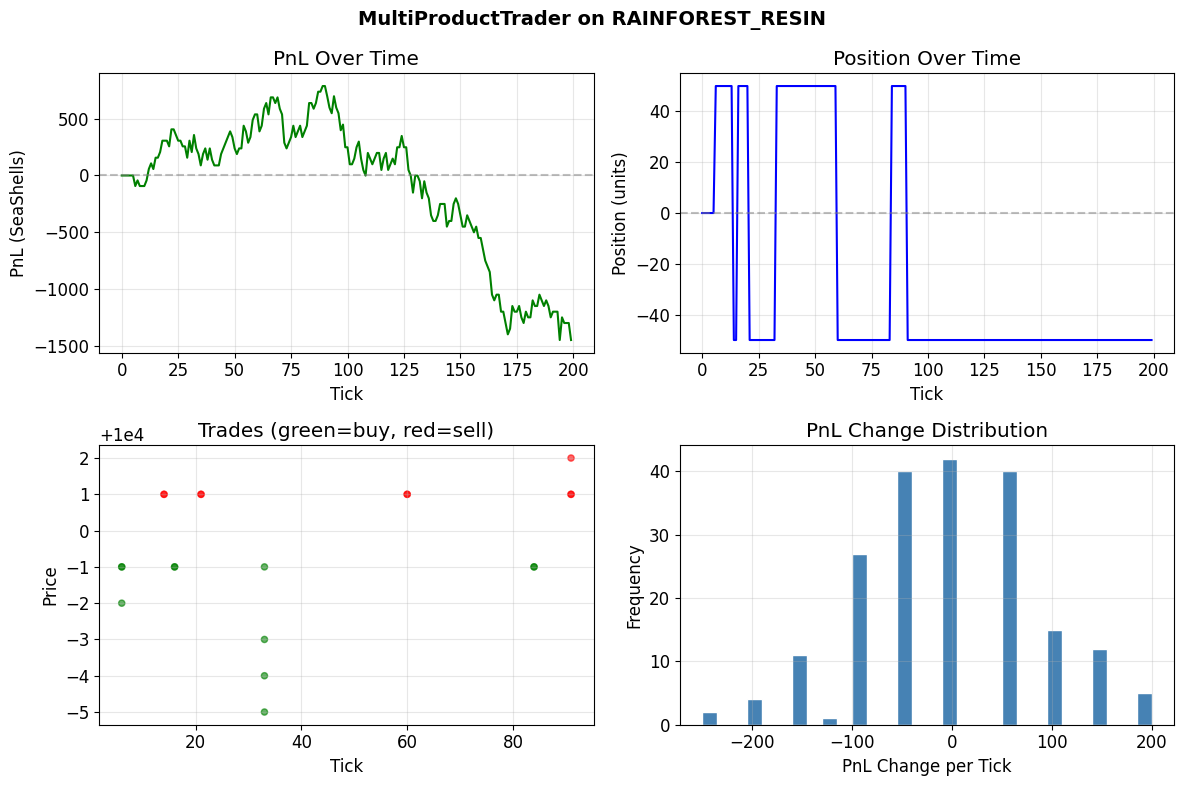

Final PnL: -1,451 SeaShells
Total trades: 20
Avg trade size: 37.5 units


In [93]:
# Demo: Run MultiProductTrader on synthetic RAINFOREST_RESIN data
# Generate 200 ticks of stable product data around 10000
num_ticks_demo = 200
base_price_resin = 10000
volatility_resin = 2.0

# Create synthetic states for RAINFOREST_RESIN
resin_states, resin_true_prices = generate_synthetic_states(
    symbol="RAINFOREST_RESIN",
    num_ticks=num_ticks_demo,
    base_price=base_price_resin,
    volatility=volatility_resin,
    spread=3,
    volume_per_level=10,
    num_levels=3,
    position_limit=50
)
# Print confirmation of generated data
print(f"Generated {len(resin_states)} ticks of RAINFOREST_RESIN data")
print(f"Price range: {min(resin_true_prices):.0f} - {max(resin_true_prices):.0f}")

# Backtest the multi-product trader on RAINFOREST_RESIN
resin_results = backtest_trader(
    multi_trader,
    resin_states,
    position_limits={"RAINFOREST_RESIN": 50}
)
# Display final PnL from the backtest
print(f"\nFinal PnL: {resin_results['final_pnl']:.0f}")
# Count the total number of trades executed
total_trades = len(resin_results["trade_history"])
print(f"Total trades: {total_trades}")

# Plot the backtest results
plot_backtest_results(resin_results, "MultiProductTrader on RAINFOREST_RESIN")

Generated 200 ticks of KELP data
Price range: 1963 - 2186
Price std dev: 65.40

Final PnL: -6941
Total trades: 105


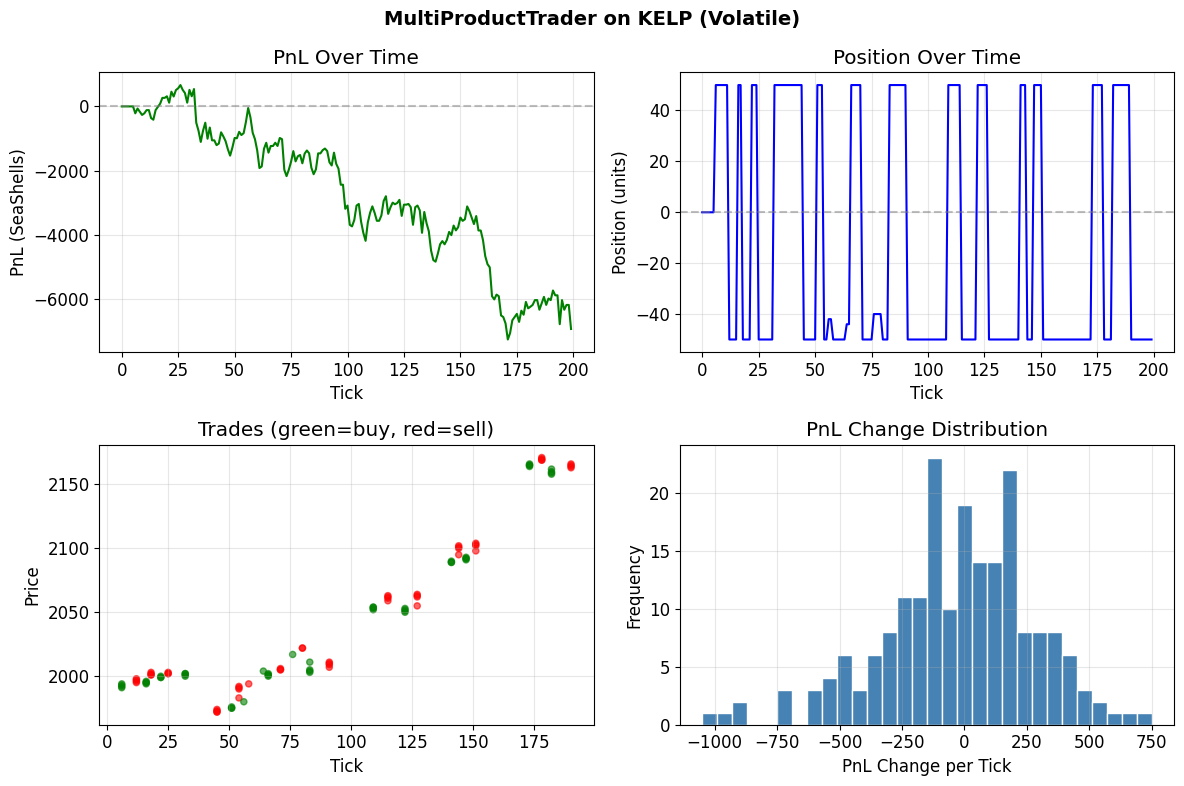

Final PnL: -6,941 SeaShells
Total trades: 105
Avg trade size: 24.6 units


In [94]:
# Demo: Run MultiProductTrader on volatile KELP data
# Generate 200 ticks of volatile product data
num_ticks_kelp = 200
base_price_kelp = 2000
volatility_kelp = 8.0

# Create synthetic states for KELP (higher volatility)
kelp_states, kelp_true_prices = generate_synthetic_states(
    symbol="KELP",
    num_ticks=num_ticks_kelp,
    base_price=base_price_kelp,
    volatility=volatility_kelp,
    spread=5,
    volume_per_level=8,
    num_levels=3,
    position_limit=50
)
# Print data summary
print(f"Generated {len(kelp_states)} ticks of KELP data")
print(f"Price range: {min(kelp_true_prices):.0f} - {max(kelp_true_prices):.0f}")
# Calculate price volatility as standard deviation
price_std = np.std(kelp_true_prices)
print(f"Price std dev: {price_std:.2f}")

# Create a fresh trader to reset EMA state
kelp_trader = MultiProductTrader()

# Backtest on KELP data
kelp_results = backtest_trader(
    kelp_trader,
    kelp_states,
    position_limits={"KELP": 50}
)
# Display results
print(f"\nFinal PnL: {kelp_results['final_pnl']:.0f}")
total_kelp_trades = len(kelp_results["trade_history"])
print(f"Total trades: {total_kelp_trades}")

# Plot the KELP backtest results
plot_backtest_results(kelp_results, "MultiProductTrader on KELP (Volatile)")

> **From the Winners:** Frankfurt Hedgehogs (P3, 2nd place) used a modular product routing
> pattern with a base `ProductTrader` class. Each product had its own trader subclass
> (`StaticTrader`, `InkTrader`, `VoucherTrader`, etc.). This meant that when Round 4 introduced
> MACARONS, they could add a single new file without touching any existing code. Their `run()`
> method was just 15 lines long -- a simple dispatcher that called `trader.execute(state)` for
> each product. This architecture allowed all 4 team members to work on different products
> simultaneously without merge conflicts.

The key takeaway is that **separation of concerns** is not just a software engineering principle --
it is a **competitive advantage**. Teams that wrote monolithic `run()` methods spent hours debugging
interactions between products. Teams that kept products isolated spent those hours improving
strategies. In a 15-day competition, architecture decisions compound just like trading profits.

### What You Learned in Section 5.1

- The **Product Router Pattern** dispatches each product symbol to its own specialized strategy
  function, keeping code modular, testable, and easy to extend as new products appear each round.
- **traderData** (a JSON string) is your only way to persist state between ticks. Store EMA values,
  running statistics, and any other state you need. Keep it under 100KB or your bot crashes.
- The **three-phase execution** pattern (TAKE, CLEAR, MAKE) works for both stable and volatile
  products -- you just change how you compute fair value and how wide you set your spreads.
- Top teams like Frankfurt Hedgehogs used **subclass-per-product** architectures that allowed
  parallel development and zero cross-product interference.

### 5.2 Backtesting Best Practices

Backtesting is where strategies look great on paper but die in production. The difference between
a profitable backtest and a profitable strategy is **out-of-sample validation**. Think of backtesting
like studying for an exam with the answer key open: you will score perfectly on practice tests, but
the real exam will have different questions. A backtest tells you "this strategy WOULD HAVE worked
on this specific data," but what you actually need to know is "will this strategy work on data I
have NEVER seen?" The tools in this section help you answer that harder question -- and they are
what separate top-10 teams from everyone else.

> **Intuition Check:** If you test 1000 random strategies on the same data, about 50 will look
> profitable at the 5% significance level purely by chance. This is why out-of-sample validation
> is non-negotiable.

#### Three Common Backtesting Pitfalls

**1. Look-ahead Bias** -- Using future information in your trading decisions. For example, computing
an EMA over the ENTIRE price series (including future prices) instead of updating it tick-by-tick.
This makes your strategy look omniscient in backtests but useless in production. Always process data
chronologically, one tick at a time, exactly as the Prosperity engine does.

**2. Overfitting** -- Tuning parameters to perfectly fit historical noise. If your strategy has 20
tunable parameters and you optimize all of them on 100 data points, you are guaranteed to find a
combination that looks amazing -- but it is fitting to random noise, not real signal. The cure is
to keep parameters few (3-5 max) and validate out-of-sample.

**3. Survivorship Bias** -- Only testing on scenarios where your strategy works. If you generate 10
random price paths, pick the 3 where your strategy profits, and report those results, you are
fooling yourself. Always report results across ALL test cases, including the ugly ones.

> **Common Mistake:** Many teams optimize their spread width, EMA alpha, and position aggressiveness
> all at once on the same data. This is a recipe for overfitting. Instead, fix all parameters except
> one, optimize that one, then move to the next. This is called **coordinate descent** and it
> dramatically reduces overfitting risk.

Monte Carlo Results (100 simulations):
  Mean PnL: 232858
  Std PnL:  23697
  Min PnL:  180197
  Max PnL:  296785
  Win rate: 100%
  Profitable simulations: 100/100


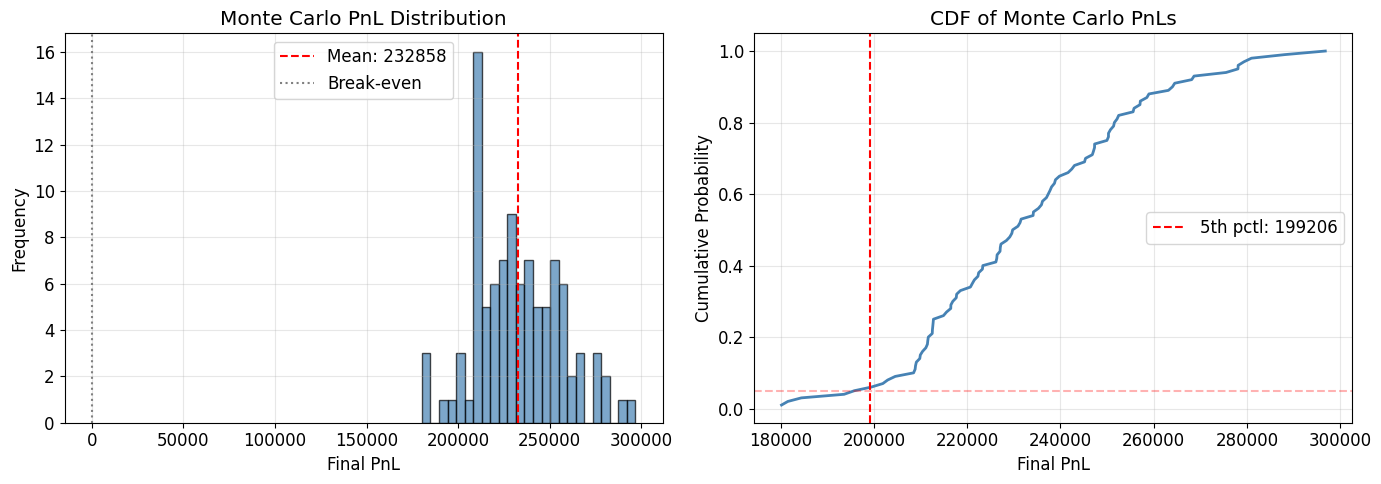

In [95]:
# Monte Carlo stress testing
# Run the strategy on 100 randomly-perturbed price paths
# If it works on 90+ of them, it is ROBUST

# Number of Monte Carlo simulations to run
num_simulations = 100
# Number of ticks per simulation
num_ticks_mc = 200
# Store final PnL from each simulation
final_pnls = []

# Generate a base price path for RAINFOREST_RESIN
np.random.seed(42)
base_prices_mc = np.array([10000.0])
for tick_index in range(num_ticks_mc - 1):
    # Random walk with small steps
    next_price = base_prices_mc[-1] + np.random.normal(0, 2)
    base_prices_mc = np.append(base_prices_mc, next_price)

# Run simulations with perturbed price paths
for simulation_index in range(num_simulations):
    # Add random multiplicative noise to each price
    noise_factor = np.random.normal(1.0, 0.01, num_ticks_mc)
    # Perturbed prices = base prices * noise
    perturbed_prices = base_prices_mc * noise_factor

    # Generate synthetic states from perturbed prices
    mc_states, _ = generate_synthetic_states(
        "RAINFOREST_RESIN",
        num_ticks=num_ticks_mc,
        base_price=10000,
        volatility=2,
        spread=3,
        volume_per_level=10,
        num_levels=3,
        position_limit=50,
        prices=list(perturbed_prices)
    )

    # Create a fresh trader for each simulation
    mc_trader = MultiProductTrader()
    # Run backtest and record final PnL
    mc_results = backtest_trader(mc_trader, mc_states, {"RAINFOREST_RESIN": 50})
    final_pnls.append(mc_results["final_pnl"])

# Report Monte Carlo results
mean_pnl = np.mean(final_pnls)
std_pnl = np.std(final_pnls)
win_count = sum(1 for p in final_pnls if p > 0)
win_rate = win_count / len(final_pnls)
print(f"Monte Carlo Results ({num_simulations} simulations):")
print(f"  Mean PnL: {mean_pnl:.0f}")
print(f"  Std PnL:  {std_pnl:.0f}")
print(f"  Min PnL:  {min(final_pnls):.0f}")
print(f"  Max PnL:  {max(final_pnls):.0f}")
print(f"  Win rate: {win_rate:.0%}")
print(f"  Profitable simulations: {win_count}/{num_simulations}")

# Plot the distribution of PnLs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: histogram of final PnLs
axes[0].hist(final_pnls, bins=25, color="steelblue", edgecolor="black", alpha=0.7)
# Add a vertical line at the mean
axes[0].axvline(mean_pnl, color="red", linestyle="--", label=f"Mean: {mean_pnl:.0f}")
# Add a vertical line at zero for reference
axes[0].axvline(0, color="gray", linestyle=":", label="Break-even")
axes[0].set_xlabel("Final PnL")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Monte Carlo PnL Distribution")
axes[0].legend()

# Right panel: cumulative distribution
sorted_pnls = sorted(final_pnls)
cumulative_probs = np.arange(1, len(sorted_pnls) + 1) / len(sorted_pnls)
axes[1].plot(sorted_pnls, cumulative_probs, color="steelblue", linewidth=2)
# Mark the 5th percentile (worst case)
percentile_5 = np.percentile(final_pnls, 5)
axes[1].axvline(percentile_5, color="red", linestyle="--", label=f"5th pctl: {percentile_5:.0f}")
axes[1].axhline(0.05, color="red", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Final PnL")
axes[1].set_ylabel("Cumulative Probability")
axes[1].set_title("CDF of Monte Carlo PnLs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [96]:
# Walk-forward testing
# 1. Generate a long price series
# 2. Optimize parameters on the FIRST 70% (in-sample)
# 3. Test with those parameters on the LAST 30% (out-of-sample)
# If it works out-of-sample, the strategy is likely real

# Generate a longer price series (500 ticks)
np.random.seed(123)
num_ticks_wf = 500
# Create a random walk price series
walk_forward_prices = [10000.0]
for tick_idx in range(num_ticks_wf - 1):
    price_change = np.random.normal(0, 3)
    walk_forward_prices.append(walk_forward_prices[-1] + price_change)

# Split into in-sample (70%) and out-of-sample (30%)
split_index = int(num_ticks_wf * 0.7)
in_sample_prices = walk_forward_prices[:split_index]
out_sample_prices = walk_forward_prices[split_index:]
print(f"In-sample: {len(in_sample_prices)} ticks")
print(f"Out-of-sample: {len(out_sample_prices)} ticks")

# Test different spread widths on in-sample data
spread_values_to_test = [1, 2, 3, 4, 5]
in_sample_results = {}

for spread_width in spread_values_to_test:
    # Generate states from in-sample prices
    is_states, _ = generate_synthetic_states(
        "RAINFOREST_RESIN",
        num_ticks=len(in_sample_prices),
        base_price=10000,
        volatility=2,
        spread=spread_width,
        volume_per_level=10,
        num_levels=3,
        position_limit=50,
        prices=in_sample_prices
    )
    # Run backtest with a fresh trader
    is_trader = MultiProductTrader()
    is_result = backtest_trader(is_trader, is_states, {"RAINFOREST_RESIN": 50})
    in_sample_results[spread_width] = is_result["final_pnl"]
    print(f"  Spread={spread_width}: In-sample PnL = {is_result['final_pnl']:.0f}")

# Find the best spread from in-sample optimization
best_spread = max(in_sample_results, key=in_sample_results.get)
print(f"\nBest in-sample spread: {best_spread} (PnL={in_sample_results[best_spread]:.0f})")

# Now test the best parameter on out-of-sample data
oos_states, _ = generate_synthetic_states(
    "RAINFOREST_RESIN",
    num_ticks=len(out_sample_prices),
    base_price=10000,
    volatility=2,
    spread=best_spread,
    volume_per_level=10,
    num_levels=3,
    position_limit=50,
    prices=out_sample_prices
)
# Run out-of-sample backtest
oos_trader = MultiProductTrader()
oos_result = backtest_trader(oos_trader, oos_states, {"RAINFOREST_RESIN": 50})
print(f"Out-of-sample PnL: {oos_result['final_pnl']:.0f}")

# Compare in-sample vs out-of-sample performance
pnl_ratio = oos_result["final_pnl"] / in_sample_results[best_spread] if in_sample_results[best_spread] != 0 else 0
print(f"\nOOS/IS ratio: {pnl_ratio:.2f}")
if pnl_ratio > 0.5:
    print("Strategy appears ROBUST (OOS performance >= 50% of IS)")
else:
    print("WARNING: Possible overfitting (OOS performance < 50% of IS)")

In-sample: 350 ticks
Out-of-sample: 150 ticks
  Spread=1: In-sample PnL = -224
  Spread=2: In-sample PnL = -810
  Spread=3: In-sample PnL = -578
  Spread=4: In-sample PnL = -1139
  Spread=5: In-sample PnL = -1119

Best in-sample spread: 1 (PnL=-224)
Out-of-sample PnL: -2041

OOS/IS ratio: 9.11
Strategy appears ROBUST (OOS performance >= 50% of IS)


In [97]:
# [ANALYSIS VERSION] Performance metrics for evaluating strategy quality
# These metrics tell you more than just "did it make money?"

def compute_sharpe_ratio(pnl_history: list) -> float:
    # Sharpe = mean(returns) / std(returns) * sqrt(252)
    # Higher is better; > 2.0 is excellent
    if len(pnl_history) < 2:
        return 0.0
    # Compute per-tick returns (changes in PnL)
    returns = [pnl_history[i] - pnl_history[i-1] for i in range(1, len(pnl_history))]
    # Guard against zero standard deviation
    returns_std = np.std(returns)
    if returns_std == 0:
        return 0.0
    # Annualize using sqrt(252) trading days
    sharpe = np.mean(returns) / returns_std * np.sqrt(252)
    return sharpe


def compute_max_drawdown(pnl_history: list) -> float:
    # Max drawdown = worst peak-to-trough decline
    # Smaller is better (less risk)
    if len(pnl_history) == 0:
        return 0.0
    peak = pnl_history[0]
    max_dd = 0
    for pnl in pnl_history:
        # Update peak if we reach a new high
        peak = max(peak, pnl)
        # Compute drawdown from peak
        drawdown = peak - pnl
        # Track the worst drawdown seen
        max_dd = max(max_dd, drawdown)
    return max_dd


def compute_profit_factor(pnl_history: list) -> float:
    # Profit factor = gross profits / gross losses
    # Values > 1.5 indicate a strong strategy
    if len(pnl_history) < 2:
        return 0.0
    # Compute per-tick returns
    returns = [pnl_history[i] - pnl_history[i-1] for i in range(1, len(pnl_history))]
    # Sum positive returns (gross profits)
    gross_profits = sum(r for r in returns if r > 0)
    # Sum negative returns (gross losses)
    gross_losses = abs(sum(r for r in returns if r < 0))
    # Guard against zero losses
    if gross_losses == 0:
        return float("inf")
    return gross_profits / gross_losses


def compute_win_rate(pnl_history: list) -> float:
    # Win rate = fraction of ticks with positive returns
    if len(pnl_history) < 2:
        return 0.0
    # Compute per-tick returns
    returns = [pnl_history[i] - pnl_history[i-1] for i in range(1, len(pnl_history))]
    # Count winning ticks
    winning_ticks = sum(1 for r in returns if r > 0)
    return winning_ticks / len(returns)


# Demo: compute metrics on our RAINFOREST_RESIN backtest
pnl_hist = resin_results["pnl_history"]
print("Performance Metrics for RAINFOREST_RESIN Strategy:")
print(f"  Final PnL:      {pnl_hist[-1]:.0f}")
# Compute and display Sharpe ratio
sharpe = compute_sharpe_ratio(pnl_hist)
print(f"  Sharpe Ratio:   {sharpe:.2f}")
# Compute and display max drawdown
max_dd = compute_max_drawdown(pnl_hist)
print(f"  Max Drawdown:   {max_dd:.0f}")
# Compute and display profit factor
pf = compute_profit_factor(pnl_hist)
print(f"  Profit Factor:  {pf:.2f}")
# Compute and display win rate
wr = compute_win_rate(pnl_hist)
print(f"  Win Rate:       {wr:.1%}")

# Interpret the results
print("\nInterpretation:")
if sharpe > 2:
    print("  Sharpe > 2: Excellent risk-adjusted returns")
elif sharpe > 1:
    print("  Sharpe > 1: Good risk-adjusted returns")
else:
    print("  Sharpe < 1: Mediocre risk-adjusted returns")
if pf > 1.5:
    print("  Profit Factor > 1.5: Strong edge detected")
else:
    print("  Profit Factor < 1.5: Edge is marginal")

Performance Metrics for RAINFOREST_RESIN Strategy:
  Final PnL:      -1451
  Sharpe Ratio:   -1.28
  Max Drawdown:   2240
  Profit Factor:  0.81
  Win Rate:       36.2%

Interpretation:
  Sharpe < 1: Mediocre risk-adjusted returns
  Profit Factor < 1.5: Edge is marginal


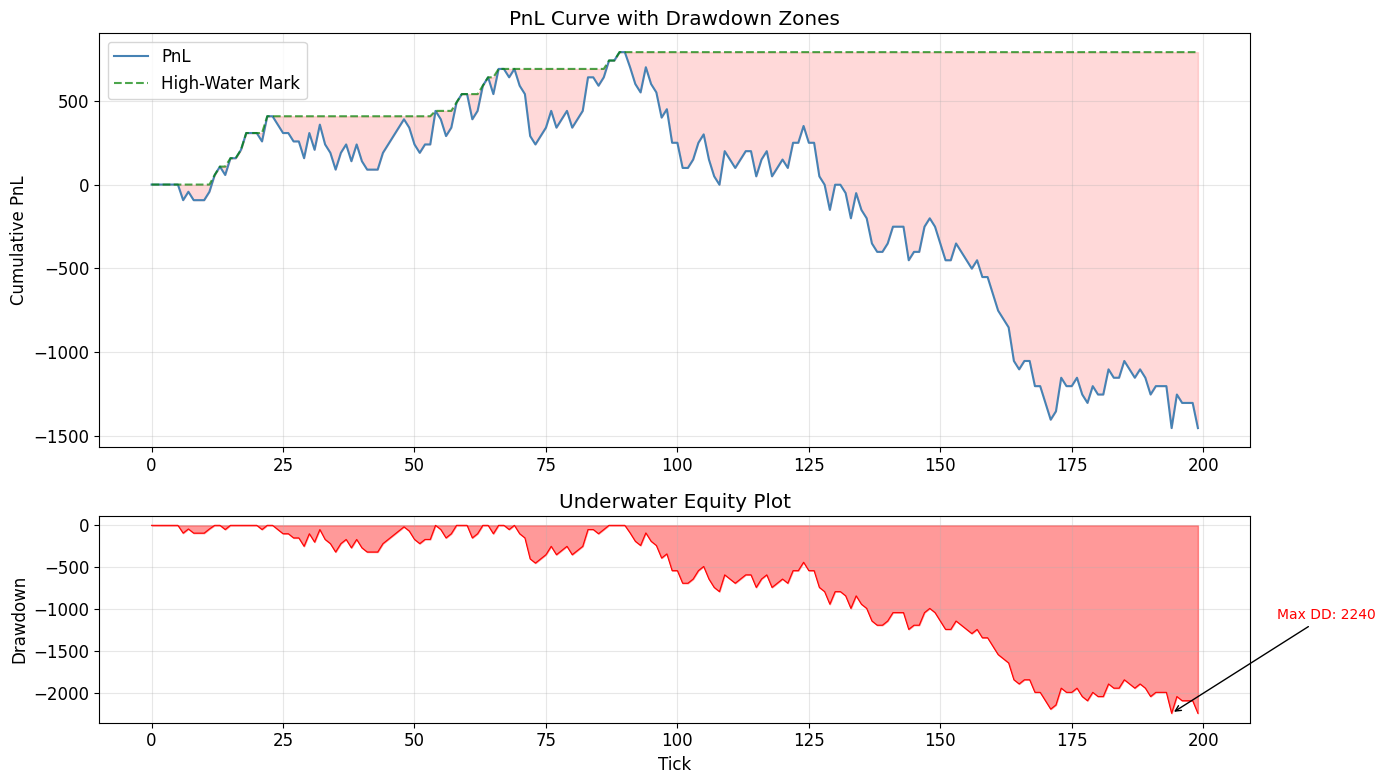

In [98]:
# Drawdown visualization: PnL curve with underwater equity plot
# The underwater plot shows how far below peak equity you are at each tick

fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1])

# Top panel: PnL curve
pnl_array = np.array(resin_results["pnl_history"])
tick_range = np.arange(len(pnl_array))
# Plot the PnL curve
axes[0].plot(tick_range, pnl_array, color="steelblue", linewidth=1.5, label="PnL")

# Compute the running peak (high-water mark)
running_peak = np.maximum.accumulate(pnl_array)
# Plot the high-water mark as a dashed line
axes[0].plot(tick_range, running_peak, color="green", linestyle="--", alpha=0.7, label="High-Water Mark")
# Shade the area between peak and actual PnL (drawdown zones)
axes[0].fill_between(tick_range, pnl_array, running_peak, alpha=0.15, color="red")
axes[0].set_ylabel("Cumulative PnL")
axes[0].set_title("PnL Curve with Drawdown Zones")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom panel: Underwater equity (drawdown from peak)
drawdown_series = running_peak - pnl_array
# Plot drawdown as negative values for visual clarity
axes[1].fill_between(tick_range, -drawdown_series, 0, color="red", alpha=0.4)
axes[1].plot(tick_range, -drawdown_series, color="red", linewidth=0.8)
# Mark the maximum drawdown point
max_dd_index = np.argmax(drawdown_series)
max_dd_value = drawdown_series[max_dd_index]
axes[1].annotate(
    f"Max DD: {max_dd_value:.0f}",
    xy=(max_dd_index, -max_dd_value),
    xytext=(max_dd_index + 20, -max_dd_value * 0.5),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
    color="red"
)
axes[1].set_xlabel("Tick")
axes[1].set_ylabel("Drawdown")
axes[1].set_title("Underwater Equity Plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Common Mistake:** Overfitting to backtest data! If you tune 20 parameters on 100 data points,
> you WILL find parameters that look amazing but fail on new data. The antidote is simple: **never
> report in-sample performance as your expected performance.** Always split your data into training
> and testing sets. If your strategy makes 10,000 SeaShells in-sample but only 2,000 out-of-sample,
> your true expected performance is closer to 2,000 -- not 10,000.

> **From the Winners:** pe049395 (P2, 13th place) used Monte Carlo augmentation to validate every
> strategy: "We ran each strategy on 100+ random perturbations of the price path. Only strategies
> that won on 90%+ of trials were considered robust. This prevented us from deploying strategies
> that looked good on historical data but were actually fitting to noise. We estimated this saved
> us from at least 3 bad strategy deployments during the competition."

In [99]:
# EXERCISE: Run Monte Carlo validation on StableMarketMaker with different spread widths
# Test spreads of 1, 2, 3, and 4
# For each spread, run 50 Monte Carlo simulations
# Report: mean PnL, std PnL, win rate for each spread
# Which spread is the most ROBUST (highest win rate + lowest std)?

# Hint: Use the StableMarketMaker from Part 3
# Hint: Generate base prices, then perturb them with noise_factor
# Hint: Track results in a dictionary keyed by spread value

# YOUR CODE HERE
# spread_results = {}
# for spread_width in [1, 2, 3, 4]:
#     spread_pnls = []
#     for sim in range(50):
#         ...
#     spread_results[spread_width] = spread_pnls
print("Complete the exercise above, then check the solution below.")

Complete the exercise above, then check the solution below.


Monte Carlo Results by Spread Width:
  Spread   Mean PnL    Std PnL   Win Rate    Min PnL
----------------------------------------------------
       1     389570      36016       100%     313522
       2     378149      42047       100%     286475
       3     376815      42444       100%     269430
       4     377451      34187       100%     316778

Most robust spread: 1 (win rate: 100%)


C:\Users\LOQ\AppData\Local\Temp\ipykernel_2476\232455953.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=["Spread=1", "Spread=2", "Spread=3", "Spread=4"], patch_artist=True)


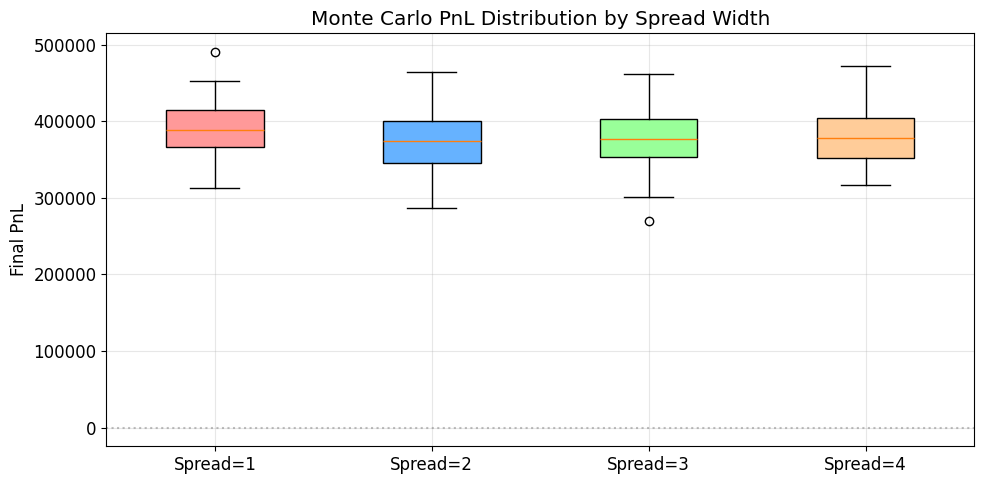

In [100]:
# SOLUTION: Monte Carlo validation across spread widths
np.random.seed(42)
# Number of simulations per spread width
num_mc_sims = 50
# Number of ticks per simulation
num_ticks_exercise = 200

# Generate base price path
base_prices_exercise = [10000.0]
for i in range(num_ticks_exercise - 1):
    base_prices_exercise.append(base_prices_exercise[-1] + np.random.normal(0, 2))
base_prices_exercise = np.array(base_prices_exercise)

# Dictionary to store results for each spread
spread_results = {}

# Test each spread width
for spread_width in [1, 2, 3, 4]:
    # Store PnLs for this spread
    spread_pnls = []

    for sim_idx in range(num_mc_sims):
        # Perturb the base prices with random noise
        noise = np.random.normal(1.0, 0.01, num_ticks_exercise)
        perturbed = base_prices_exercise * noise

        # Generate synthetic states with the perturbed prices
        ex_states, _ = generate_synthetic_states(
            "RAINFOREST_RESIN",
            num_ticks=num_ticks_exercise,
            base_price=10000,
            volatility=2,
            spread=spread_width,
            volume_per_level=10,
            num_levels=3,
            position_limit=50,
            prices=list(perturbed)
        )
        # Use StableMarketMaker from Part 3
        ex_trader = StableMarketMaker()
        ex_result = backtest_trader(ex_trader, ex_states, {"RAINFOREST_RESIN": 50})
        # Record the final PnL
        spread_pnls.append(ex_result["final_pnl"])

    # Store results for this spread width
    spread_results[spread_width] = spread_pnls

# Print summary statistics for each spread
print("Monte Carlo Results by Spread Width:")
print(f"{'Spread':>8} {'Mean PnL':>10} {'Std PnL':>10} {'Win Rate':>10} {'Min PnL':>10}")
print("-" * 52)

# Track the best spread by win rate
best_win_rate = 0
best_spread_choice = 1

for spread_width in [1, 2, 3, 4]:
    pnls = spread_results[spread_width]
    mean_val = np.mean(pnls)
    std_val = np.std(pnls)
    wr_val = sum(1 for p in pnls if p > 0) / len(pnls)
    min_val = min(pnls)
    # Print row for this spread
    print(f"{spread_width:>8} {mean_val:>10.0f} {std_val:>10.0f} {wr_val:>10.0%} {min_val:>10.0f}")
    # Update best spread if this one has higher win rate
    if wr_val > best_win_rate:
        best_win_rate = wr_val
        best_spread_choice = spread_width

print(f"\nMost robust spread: {best_spread_choice} (win rate: {best_win_rate:.0%})")

# Visualize the distributions with box plots
fig, ax = plt.subplots(figsize=(10, 5))
# Create box plot data
box_data = [spread_results[s] for s in [1, 2, 3, 4]]
# Draw box plots
bp = ax.boxplot(box_data, labels=["Spread=1", "Spread=2", "Spread=3", "Spread=4"], patch_artist=True)
# Color the boxes
colors = ["#FF9999", "#66B2FF", "#99FF99", "#FFCC99"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
# Add a horizontal line at zero (break-even)
ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.set_ylabel("Final PnL")
ax.set_title("Monte Carlo PnL Distribution by Spread Width")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What You Learned in Section 5.2

- **Monte Carlo stress testing** runs your strategy on 100+ randomly perturbed price paths to
  measure robustness. A strategy that wins on 90%+ of perturbations is likely exploiting real
  market structure, not fitting to noise.
- **Walk-forward testing** splits data into training (70%) and testing (30%) sets. The out-of-sample
  performance is your true expected performance -- never trust in-sample numbers alone.
- **Sharpe ratio**, **max drawdown**, **profit factor**, and **win rate** give you a multi-dimensional
  view of strategy quality. A strategy with Sharpe > 2 and max drawdown < 500 is much more
  reliable than one with higher PnL but Sharpe < 1 and huge drawdowns.
- The **underwater equity plot** visualizes drawdown periods, helping you understand worst-case
  scenarios and set realistic expectations for live trading.

### 5.3 Cross-Year Data Analysis

IMC has run Prosperity for 4 years now (2022-2025). Each year, teams discovered that data patterns
**repeat across years**. By analyzing previous years' data, you can predict future behavior and
gain a massive edge. Think of it like a professor who reuses exam questions: if you study last
year's exams, you will recognize the patterns and solve problems faster. In Prosperity, price
dynamics, counterparty behaviors, and even specific fair values have shown strong year-over-year
correlations. Teams that invest time in cross-year analysis consistently outperform those that
treat each year as completely new.

> **Intuition Check:** Why would IMC reuse data patterns? Because the competition is about trading
> SKILL, not data science novelty. They want to test whether you can identify and exploit
> structure -- and the best way to test that is to embed structure that rewards careful analysis.

> **From the Winners:** Linear Utility (P2, 2nd place) discovered that P1 and P2 price data was
> 99% correlated with a **1.25x multiplier**. This single insight -- "this year's fair value is
> 1.25 times last year's fair value for the same product" -- earned them approximately **2.1 million
> SeaShells** in one round. They found this by simply plotting year-over-year prices on the same
> chart and noticing the near-perfect linear relationship. The lesson is clear: before building
> complex models, always check whether the simplest possible relationship (linear scaling) explains
> the data. Often, it does.

In [101]:
# Synthetic cross-year correlation demo
# Simulates two years of price data where Year 2 = 1.25 * Year 1 + noise
np.random.seed(42)
# Number of data points per year
num_data_points = 500

# Year 1 prices: random walk starting at 10000
year_1_prices = [10000.0]
for i in range(num_data_points - 1):
    # Small random steps to simulate daily price changes
    step = np.random.normal(0, 5)
    year_1_prices.append(year_1_prices[-1] + step)
# Convert to numpy array for vectorized operations
year_1_prices = np.array(year_1_prices)

# Year 2 prices: correlated with Year 1 via multiplier + noise
multiplier = 1.25
noise_level = 10
# Apply the multiplier and add Gaussian noise
year_2_prices = multiplier * year_1_prices + np.random.normal(0, noise_level, num_data_points)

# Print summary statistics
print("Cross-Year Price Data Summary:")
print(f"  Year 1: mean={np.mean(year_1_prices):.0f}, std={np.std(year_1_prices):.0f}")
print(f"  Year 2: mean={np.mean(year_2_prices):.0f}, std={np.std(year_2_prices):.0f}")
# Compute and display the actual correlation coefficient
correlation = np.corrcoef(year_1_prices, year_2_prices)[0, 1]
print(f"  Correlation: {correlation:.6f}")
# Compute the actual multiplier via linear regression
slope = np.polyfit(year_1_prices, year_2_prices, 1)[0]
print(f"  Estimated multiplier: {slope:.4f} (true: {multiplier})")

Cross-Year Price Data Summary:
  Year 1: mean=9993, std=35
  Year 2: mean=12492, std=45
  Correlation: 0.976447
  Estimated multiplier: 1.2626 (true: 1.25)


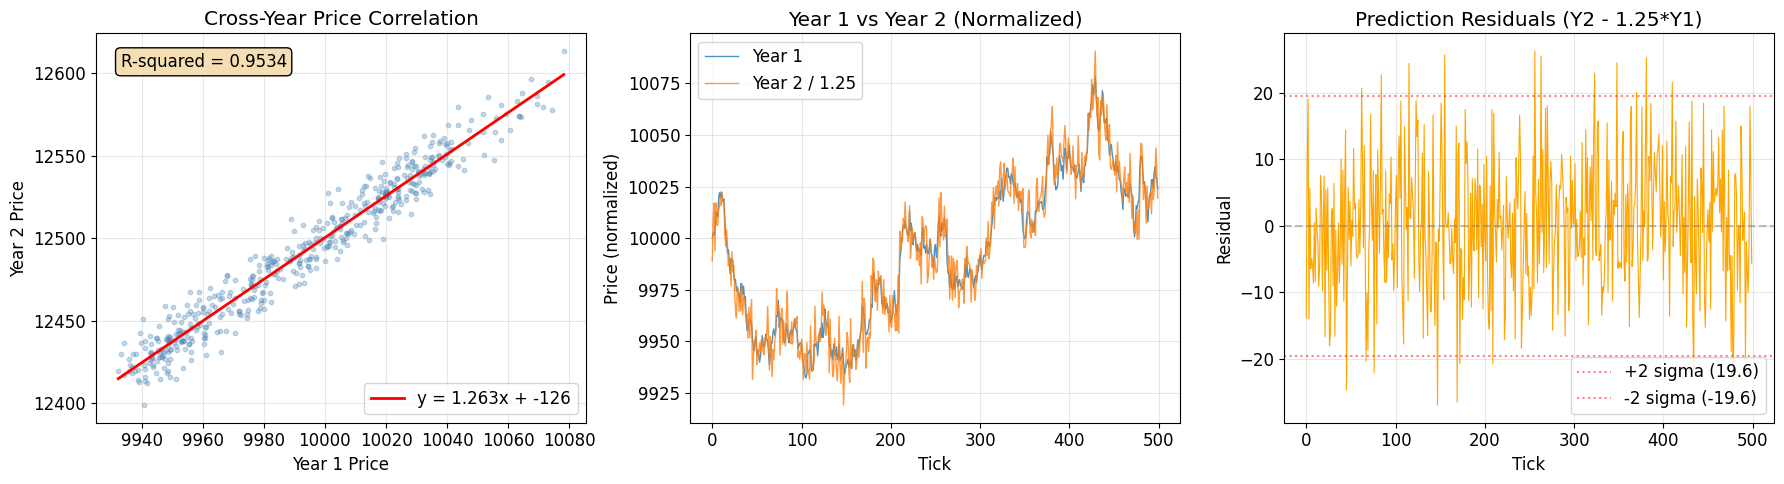

In [102]:
# Correlation analysis with scatter plot and regression line
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Scatter plot of Year 1 vs Year 2 prices
axes[0].scatter(year_1_prices, year_2_prices, alpha=0.3, s=10, color="steelblue")
# Fit and plot regression line
regression_coeffs = np.polyfit(year_1_prices, year_2_prices, 1)
regression_slope = regression_coeffs[0]
regression_intercept = regression_coeffs[1]
# Create a line through the data range
x_line = np.linspace(min(year_1_prices), max(year_1_prices), 100)
y_line = regression_slope * x_line + regression_intercept
axes[0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {regression_slope:.3f}x + {regression_intercept:.0f}")
# Add R-squared annotation
r_squared = correlation ** 2
axes[0].text(0.05, 0.95, f"R-squared = {r_squared:.4f}", transform=axes[0].transAxes,
             fontsize=12, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="wheat"))
axes[0].set_xlabel("Year 1 Price")
axes[0].set_ylabel("Year 2 Price")
axes[0].set_title("Cross-Year Price Correlation")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Overlay of both years' time series
time_axis = np.arange(num_data_points)
axes[1].plot(time_axis, year_1_prices, label="Year 1", alpha=0.8, linewidth=1)
# Plot Year 2 scaled down by multiplier for comparison
axes[1].plot(time_axis, year_2_prices / multiplier, label=f"Year 2 / {multiplier}", alpha=0.8, linewidth=1)
axes[1].set_xlabel("Tick")
axes[1].set_ylabel("Price (normalized)")
axes[1].set_title("Year 1 vs Year 2 (Normalized)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Residuals (Year 2 - multiplier * Year 1)
residuals = year_2_prices - multiplier * year_1_prices
axes[2].plot(time_axis, residuals, color="orange", linewidth=0.8)
# Add horizontal line at zero
axes[2].axhline(0, color="gray", linestyle="--", alpha=0.5)
# Add 2-sigma bands
residual_std = np.std(residuals)
axes[2].axhline(2 * residual_std, color="red", linestyle=":", alpha=0.5, label=f"+2 sigma ({2*residual_std:.1f})")
axes[2].axhline(-2 * residual_std, color="red", linestyle=":", alpha=0.5, label=f"-2 sigma ({-2*residual_std:.1f})")
axes[2].set_xlabel("Tick")
axes[2].set_ylabel("Residual")
axes[2].set_title("Prediction Residuals (Y2 - 1.25*Y1)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

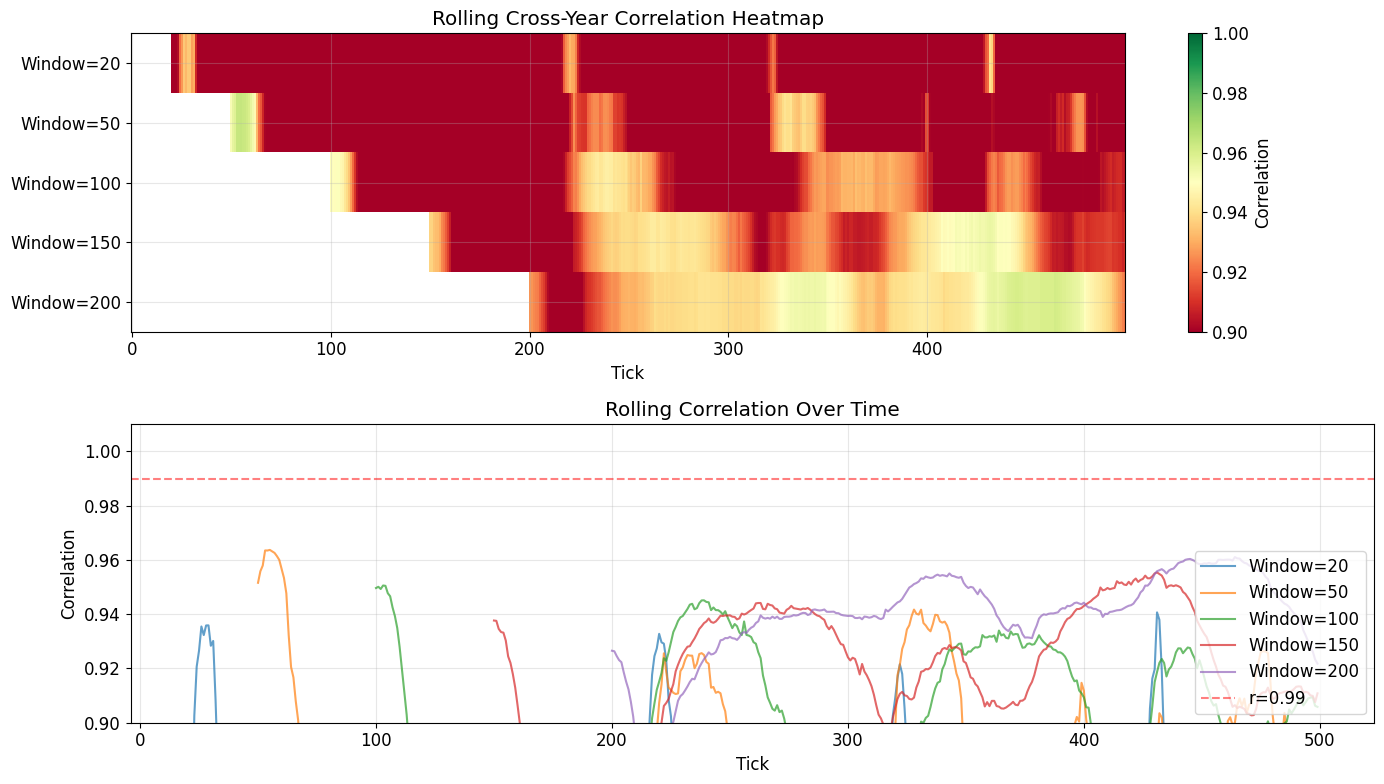

Average rolling correlation (window=200): 0.9390


In [103]:
# Heatmap visualization of rolling correlations
# Shows how the cross-year correlation evolves over time

# Compute rolling correlations with different window sizes
window_sizes = [20, 50, 100, 150, 200]
# Create a matrix to store rolling correlations
rolling_corr_matrix = np.zeros((len(window_sizes), num_data_points))

for row_idx, window in enumerate(window_sizes):
    for col_idx in range(window, num_data_points):
        # Extract the window of data
        y1_window = year_1_prices[col_idx - window:col_idx]
        y2_window = year_2_prices[col_idx - window:col_idx]
        # Compute correlation for this window
        corr_value = np.corrcoef(y1_window, y2_window)[0, 1]
        rolling_corr_matrix[row_idx, col_idx] = corr_value
    # Fill in the initial values (before window is full)
    rolling_corr_matrix[row_idx, :window] = np.nan

# Create the heatmap
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top panel: Heatmap of rolling correlations
im = axes[0].imshow(
    rolling_corr_matrix,
    aspect="auto",
    cmap="RdYlGn",
    vmin=0.9,
    vmax=1.0,
    interpolation="nearest"
)
# Add colorbar
cbar = plt.colorbar(im, ax=axes[0])
cbar.set_label("Correlation")
# Set axis labels
axes[0].set_yticks(range(len(window_sizes)))
axes[0].set_yticklabels([f"Window={w}" for w in window_sizes])
axes[0].set_xlabel("Tick")
axes[0].set_title("Rolling Cross-Year Correlation Heatmap")

# Bottom panel: Line plot of rolling correlations
for row_idx, window in enumerate(window_sizes):
    # Extract valid (non-NaN) values
    valid_ticks = np.arange(window, num_data_points)
    valid_corrs = rolling_corr_matrix[row_idx, window:]
    # Plot rolling correlation line
    axes[1].plot(valid_ticks, valid_corrs, label=f"Window={window}", alpha=0.7, linewidth=1.5)
# Add a reference line at 0.99
axes[1].axhline(0.99, color="red", linestyle="--", alpha=0.5, label="r=0.99")
axes[1].set_xlabel("Tick")
axes[1].set_ylabel("Correlation")
axes[1].set_title("Rolling Correlation Over Time")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)
# Set y-axis limits to zoom into relevant range
axes[1].set_ylim(0.9, 1.01)

plt.tight_layout()
plt.show()

# Print the average rolling correlation for the largest window
avg_corr_200 = np.nanmean(rolling_corr_matrix[-1, :])
print(f"Average rolling correlation (window=200): {avg_corr_200:.4f}")

> **From the Winners:** Linear Utility (P2, 2nd place): "We discovered the cross-year correlation
> on Day 3. By Day 5, we had a model that predicted prices from historical data with R-squared =
> 0.99. This single discovery was worth approximately 2.1 million SeaShells. The key was to NOT
> overthink it -- we tried a simple linear regression first, saw the R-squared, and immediately
> deployed it. Teams that tried neural networks or complex time-series models spent days building
> infrastructure and got worse results than our one-line regression."

The lesson here extends beyond cross-year analysis: **always try the simplest model first**. In
trading and data science, the Occam's Razor principle is surprisingly powerful. A linear model
with R-squared = 0.99 will outperform a neural network with R-squared = 0.95 every single time,
because the linear model is more robust, faster to compute, and less likely to overfit. Complexity
is a cost, not a feature.

In [104]:
# EXERCISE: Given two years of price data, find the optimal multiplier
# and predict the next day's prices
#
# Tasks:
# 1. Generate synthetic Year 3 data using a DIFFERENT multiplier (try 1.4)
# 2. Use linear regression to discover the multiplier from Year 2 -> Year 3
# 3. Predict the next 50 ticks of Year 3 prices from Year 2 data
# 4. Measure prediction accuracy (RMSE)
#
# Hint: Use np.polyfit(year_2_prices, year_3_prices, 1) to find slope
# Hint: RMSE = sqrt(mean((predicted - actual)^2))

# YOUR CODE HERE
# Step 1: Generate Year 3 data
# true_multiplier_y3 = 1.4
# year_3_prices = true_multiplier_y3 * year_2_prices + noise
#
# Step 2: Use first 400 points to estimate multiplier
# estimated_multiplier = ...
#
# Step 3: Predict last 100 points
# predicted_prices = estimated_multiplier * year_2_prices[400:]
#
# Step 4: Compute RMSE
# rmse = np.sqrt(np.mean((predicted - actual)**2))

print("Complete the exercise above, then check the solution below.")

Complete the exercise above, then check the solution below.


Year 3 generated: mean=17489, std=65
Estimated multiplier: 1.3995 (true: 1.4)
Estimated intercept: 7.38

Out-of-sample prediction accuracy:
  RMSE: 14.47
  MAE:  11.54
  R-squared (OOS): 0.8145


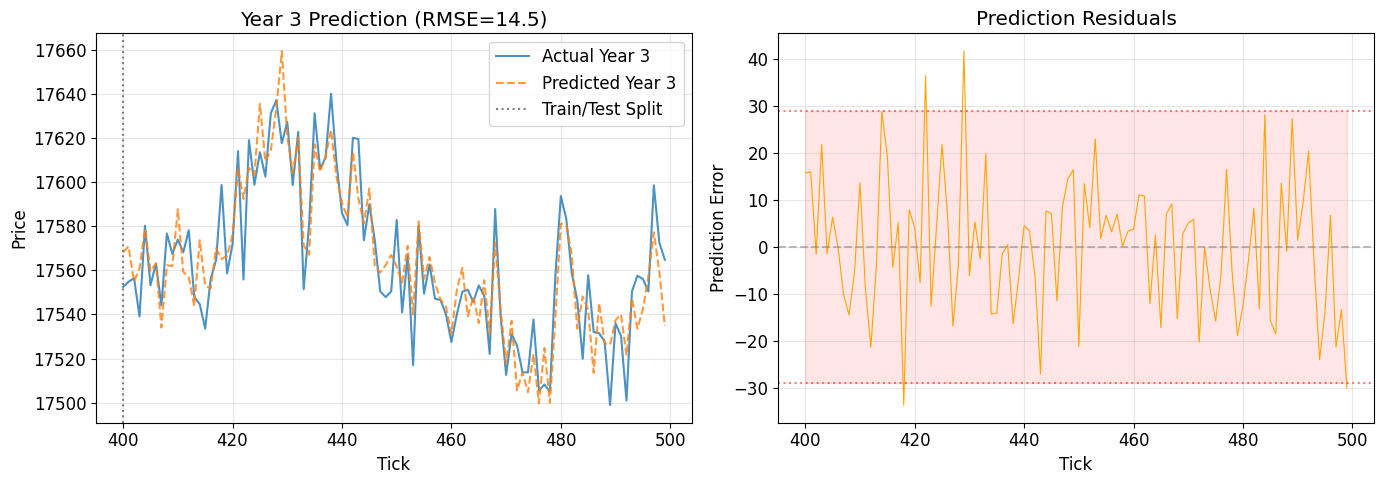

In [105]:
# SOLUTION: Cross-year multiplier discovery and prediction
np.random.seed(99)

# Step 1: Generate Year 3 data with a different multiplier
true_multiplier_y3 = 1.4
noise_level_y3 = 15
# Year 3 = 1.4 * Year 2 + noise
year_3_prices = true_multiplier_y3 * year_2_prices + np.random.normal(0, noise_level_y3, num_data_points)
print(f"Year 3 generated: mean={np.mean(year_3_prices):.0f}, std={np.std(year_3_prices):.0f}")

# Step 2: Use first 400 points as training data to discover multiplier
train_size = 400
# Fit linear regression on training portion only
train_y2 = year_2_prices[:train_size]
train_y3 = year_3_prices[:train_size]
coeffs = np.polyfit(train_y2, train_y3, 1)
estimated_multiplier = coeffs[0]
estimated_intercept = coeffs[1]
print(f"Estimated multiplier: {estimated_multiplier:.4f} (true: {true_multiplier_y3})")
print(f"Estimated intercept: {estimated_intercept:.2f}")

# Step 3: Predict the last 100 points (out-of-sample)
test_y2 = year_2_prices[train_size:]
actual_y3 = year_3_prices[train_size:]
# Generate predictions using discovered multiplier
predicted_y3 = estimated_multiplier * test_y2 + estimated_intercept

# Step 4: Compute prediction accuracy
errors = predicted_y3 - actual_y3
rmse = np.sqrt(np.mean(errors ** 2))
mae = np.mean(np.abs(errors))
print(f"\nOut-of-sample prediction accuracy:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
# Compute R-squared on test set
ss_res = np.sum(errors ** 2)
ss_tot = np.sum((actual_y3 - np.mean(actual_y3)) ** 2)
r_squared_oos = 1 - ss_res / ss_tot
print(f"  R-squared (OOS): {r_squared_oos:.4f}")

# Visualize predictions vs actuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Predicted vs actual prices
test_ticks = np.arange(train_size, num_data_points)
axes[0].plot(test_ticks, actual_y3, label="Actual Year 3", alpha=0.8, linewidth=1.5)
axes[0].plot(test_ticks, predicted_y3, label="Predicted Year 3", alpha=0.8, linewidth=1.5, linestyle="--")
# Add vertical line at the train/test split
axes[0].axvline(train_size, color="gray", linestyle=":", label="Train/Test Split")
axes[0].set_xlabel("Tick")
axes[0].set_ylabel("Price")
axes[0].set_title(f"Year 3 Prediction (RMSE={rmse:.1f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right panel: Prediction errors over time
axes[1].plot(test_ticks, errors, color="orange", linewidth=0.8)
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
# Add 2-sigma bands
error_std = np.std(errors)
axes[1].axhline(2 * error_std, color="red", linestyle=":", alpha=0.5)
axes[1].axhline(-2 * error_std, color="red", linestyle=":", alpha=0.5)
axes[1].fill_between(test_ticks, -2 * error_std, 2 * error_std, alpha=0.1, color="red")
axes[1].set_xlabel("Tick")
axes[1].set_ylabel("Prediction Error")
axes[1].set_title("Prediction Residuals")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5.4 Your Competition Day Workflow

The difference between a good strategy and a winning competition entry is **process**. Having a
structured daily workflow ensures you do not waste time on low-value tasks and that you catch
problems before they cost you SeaShells. Think of this like a pilot's pre-flight checklist: even
the most experienced pilots go through every item, every time, because skipping one step can be
catastrophic. In a 15-day competition with 5 rounds, discipline compounds. Teams that follow a
consistent workflow gain 1-2% improvement per day -- and over 15 days, that adds up to a decisive
advantage.

### Daily Checklist

Follow this checklist at the start of each trading day (each new round):

1. **Download new round data** from the Prosperity dashboard -- fresh data is available after each round closes
2. **Analyze price patterns** -- plot all products, check correlations, look for regime changes
3. **Check what products are available** -- new products appear each round (Round 1 has 3, Round 5 has 11+)
4. **Review the leaderboard** -- who is ahead? What strategies might they be using? Have rankings shifted?
5. **Run backtests** on new data with your current strategy -- does it still work on the latest data?
6. **Tune parameters conservatively** -- quarter-Kelly adjustments (change parameters by at most 25% per round)
7. **Test edge cases** -- what if volatility doubles? What if a product gaps 5%? What if the order book is empty?
8. **Submit early** -- do not wait until the last minute; server load spikes near deadlines
9. **Monitor live results** -- check for unexpected behavior in the first hour after submission
10. **Save your code** with version numbers (`round1_v1.py`, `round1_v2.py`, ...) so you can roll back

> **Common Mistake:** Many teams spend 80% of their time optimizing Round 1 strategies and only 20%
> on new rounds. The highest-value activity is **adapting to new products**, because early movers
> on new products face less competition and wider spreads (more profit per trade).

### Time Management by Round

**Days 1-3 (Rounds 1-2):** Focus on **RAINFOREST_RESIN** (stable, guaranteed profit with market
making). This is your "base camp" -- it provides steady income while you learn the platform. Get
comfortable with submissions, traderData, and the three-phase execution pattern. Also start
looking at KELP and SQUID_INK data.

**Days 4-7 (Rounds 2-3):** Add volatile product strategies (**KELP**, **SQUID_INK**). Start
exploring pairs and basket trading (CROISSANTS, JAMS, DJEMBES, PICNIC_BASKETs). Look for
statistical arbitrage opportunities between correlated products.

**Days 8-10 (Round 4):** Cross-exchange arbitrage (**MAGNIFICENT_MACARONS**). Look for cross-year
data patterns -- download previous years' data if available. Start analyzing counterparty trading
patterns (especially Olivia).

**Days 11-15 (Round 5):** Options trading (**VOLCANIC_ROCK** + **VOUCHER**). Polish everything.
Focus on risk management -- this is when aggressive strategies blow up. Fine-tune position sizing
and make sure your traderData is under 100KB.

> **From the Winners:** Stanford Cardinal (P1, 2nd place) allocated exactly 4 hours per team member
> per new product. They found that diminishing returns set in after 4 hours of parameter tuning --
> after that point, time was better spent on new products or risk management.

### Pro Tips from Past Winners

This section distills the most impactful advice from top teams across all three years of
Prosperity. Each tip has been validated by multiple teams and represents a genuine competitive
edge. Treat these not as suggestions but as **hard-won lessons** from teams that have been in
your position and found what actually matters.

### The Top 10 Commandments of IMC Prosperity

1. **Start simple.** Stanford Cardinal (P1, 2nd place) won with simple linear regression.
   Complexity does not equal profit -- it equals bugs and overfitting.

2. **Do not share strategies on Discord.** Linear Utility (P2, 2nd place) dropped from 3rd to 17th
   after strategy leakage. Keep your edge private until the competition ends.

3. **Test with Monte Carlo.** pe049395 (P2, 13th place) validated every strategy on 100+ random
   price paths. Only deploy strategies that win on 90%+ of perturbations.

4. **Watch Olivia.** All top P3 teams exploited counterparty trading patterns. Olivia and other bots
   behave predictably -- learn their patterns and trade against them.

5. **Check cross-year data.** Linear Utility found R-squared = 0.99 between years, earning 2.1M
   SeaShells from a single linear regression.

6. **Use three-phase execution.** TAKE mispriced orders first, CLEAR your position toward zero, then
   MAKE passive quotes. This ordering maximizes both aggression and safety.

7. **Manage position limits carefully.** Exceeding limits means rejected orders, which means lost
   profit. Always track your effective position after each order.

8. **Keep traderData small.** Over 100KB crashes your bot. Use JSON (not pickle), store only what
   you need, and periodically prune old data.

9. **Use the Logger class.** AWS Lambda output limit is approximately 3750 characters. Budget your
   logging wisely -- log warnings and key metrics, not every order.

10. **Have fun!** IMC Prosperity is a learning experience. You are competing against thousands of
    teams worldwide in one of the most unique trading competitions ever created. Even competing is
    an achievement. Learn from every round, iterate fast, and enjoy the process.

---

**Congratulations -- you have completed the entire preparation course!** You now have the tools,
techniques, and mindset to compete in IMC Prosperity 4. You understand market microstructure,
three-phase execution, EMA-based pricing, pairs trading, options with Black-Scholes, Monte Carlo
validation, cross-year analysis, and multi-product architecture. Most importantly, you know
**why** each technique works, not just how to implement it.

**You are ready. Good luck, and may your SeaShells overflow!**

In [106]:
# Course completion summary
# Print a recap of everything covered across all 5 parts
print("=" * 60)
print("  IMC PROSPERITY 4 PREPARATION COURSE -- COMPLETE")
print("=" * 60)
print()

# Part 1 summary
print("Part 1: Foundations & Market Microstructure")
print("  - Order books, bid/ask spreads, position limits")
print("  - TradingState, OrderDepth, Order classes")
print("  - Basic market making with fair value")
print()

# Part 2 summary
print("Part 2: Market Making Strategies")
print("  - Three-phase execution: TAKE, CLEAR, MAKE")
print("  - Stable product MM (RAINFOREST_RESIN @ 10000)")
print("  - Volatile product MM (KELP, SQUID_INK with EMA)")
print("  - Position management and risk control")
print()

# Part 3 summary
print("Part 3: Advanced Strategies")
print("  - Pairs trading and statistical arbitrage")
print("  - Basket trading (PICNIC_BASKET components)")
print("  - Options pricing with Black-Scholes")
print("  - Counterparty analysis (Olivia pattern)")
print()

# Part 4 summary
print("Part 4: Risk Management & Optimization")
print("  - Kelly criterion for position sizing")
print("  - Drawdown control and circuit breakers")
print("  - Parameter optimization techniques")
print("  - traderData serialization patterns")
print()

# Part 5 summary
print("Part 5: Integration & Competition Readiness")
print("  - Multi-product trader architecture")
print("  - Product router pattern")
print("  - Monte Carlo stress testing")
print("  - Walk-forward validation")
print("  - Cross-year data analysis")
print("  - Competition workflow and pro tips")
print()

# Print key numbers
print("-" * 60)
print("KEY NUMBERS TO REMEMBER:")
print(f"  Products in Round 5:     11")
print(f"  Max traderData size:     ~100 KB")
print(f"  Lambda output limit:     ~3750 chars")
print(f"  RAINFOREST_RESIN fair:   10000")
print(f"  Monte Carlo threshold:   90%+ win rate")
print(f"  Walk-forward split:      70/30")
print("-" * 60)
print()
print("Good luck in IMC Prosperity 4!")

  IMC PROSPERITY 4 PREPARATION COURSE -- COMPLETE

Part 1: Foundations & Market Microstructure
  - Order books, bid/ask spreads, position limits
  - TradingState, OrderDepth, Order classes
  - Basic market making with fair value

Part 2: Market Making Strategies
  - Three-phase execution: TAKE, CLEAR, MAKE
  - Stable product MM (RAINFOREST_RESIN @ 10000)
  - Volatile product MM (KELP, SQUID_INK with EMA)
  - Position management and risk control

Part 3: Advanced Strategies
  - Pairs trading and statistical arbitrage
  - Basket trading (PICNIC_BASKET components)
  - Options pricing with Black-Scholes
  - Counterparty analysis (Olivia pattern)

Part 4: Risk Management & Optimization
  - Kelly criterion for position sizing
  - Drawdown control and circuit breakers
  - Parameter optimization techniques
  - traderData serialization patterns

Part 5: Integration & Competition Readiness
  - Multi-product trader architecture
  - Product router pattern
  - Monte Carlo stress testing
  - Walk-fo

---

### Ready to Compete

You have covered **5 comprehensive parts** spanning market microstructure, strategy development,
risk management, backtesting validation, and competition preparation. Here is your quick-reference
summary:

| Part | Topic | Key Takeaway |
|------|-------|-------------|
| 1 | Foundations | Understand the OrderBook and TradingState API inside and out |
| 2 | Market Making | Three-phase execution (TAKE, CLEAR, MAKE) is the universal pattern |
| 3 | Advanced Strategies | Pairs, baskets, and options all reduce to finding fair value + edge |
| 4 | Risk Management | Kelly criterion + Monte Carlo = robust position sizing |
| 5 | Integration | Product Router pattern + walk-forward validation = competition-ready code |

**Your next step:** Download the IMC Prosperity 4 starter code, implement the `MultiProductTrader`
pattern from Section 5.1, and start with RAINFOREST_RESIN market making. Build from there, one
product at a time, validating each addition with Monte Carlo stress tests.

*This notebook was designed as a comprehensive preparation guide for IMC Prosperity 4. All code
examples are submission-safe and follow the exact API that the Prosperity engine expects. Strategies
and insights are drawn from public post-competition analyses by top teams from Prosperity 1-3.*